In [2]:
from hossam import load_data
from helpers import *
from pandas import DataFrame
from IPython.display import display, Markdown

📦 아이티윌 이광호 강사가 제작한 라이브러리를 사용중입니다.
📚 자세한 사용 방법은 https://py.hossam.kr 을 참고하세요.
📧 Email: leekh4232@gmail.com
🎬 Youtube: https://www.youtube.com/@hossam-codingclub
📝 Blog: https://blog.hossam.kr/
🔖 Version: 0.5.29

⚠️  'hossam' 패키지의 최신 버전이 출시되었습니다! (설치된 버전: 0.5.29, 최신 버전: 0.5.33)
   최신 버전으로 업데이트하려면 다음 명령어를 실행하세요:
   pip install --upgrade hossam



# 뉴욕 맨해튼 임대료 예측 모델 구축

### 미션 1. **"이 표본은 무엇을 담고 있나?"**

**데이터 불러오기**

In [3]:
origin = load_data("streeteasy")

📚 StreetEasy는 뉴욕시 최고의 부동산 마켓플레이스입니다. 여러분은 맨해튼의 임대 매물 5,000건을 표본으로 하는 데이터셋을 다루게 될 것입니다. (출처: https://www.kaggle.com/datasets/zohaib30/streeteasy-dataset)

    field             description
--  ----------------  -------------------------------------------------------------------------------------------------------------------
 0  rent              월 임대료(USD) — 연속형, 회귀 분석의 종속변수(타깃). 범위 1,300~20,000, 평균 약 5,139
 1  bedrooms          침실 수 — 이산 수치형(순서형). 0.5 단위 10개 값(0~5), 0은 스튜디오(원룸), 0.5는 침실 분리형 원룸
 2  bathrooms         욕실 수 — 이산 수치형(순서형). 0~5의 정수, 0은 독립 욕실 없음
 3  size_sqft         전용 면적(제곱피트, 1sqft≈0.028평) — 연속형. 범위 250~4,800, 임대료와 상관이 가장 높은 변수
 4  min_to_subway     가장 가까운 지하철역까지 도보 소요 시간(분) — 연속형. 범위 0~43, 값이 작을수록 역세권
 5  floor             매물이 위치한 층 — 이산 수치형. 0~83층, 0.5는 중층(메자닌), 0은 지상·반지하층
 6  building_age_yrs  건물 준공 후 경과 연수(년) — 연속형. 범위 0~180, 0은 신축
 7  no_fee            중개 수수료 없는 매물 여부 — 이진 범주형(1=수수료 없음, 0=수수료 있음)
 8  has_roofdeck      옥상 데크(루프덱) 보유 여부 — 이진 범주형(1=보유, 0=미보유)
 9  has_wa

In [4]:
origin.info()

<class 'pandas.DataFrame'>
RangeIndex: 3539 entries, 0 to 3538
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   rent              3539 non-null   int64  
 1   bedrooms          3539 non-null   float64
 2   bathrooms         3539 non-null   int64  
 3   size_sqft         3539 non-null   int64  
 4   min_to_subway     3539 non-null   int64  
 5   floor             3539 non-null   float64
 6   building_age_yrs  3539 non-null   int64  
 7   no_fee            3539 non-null   int64  
 8   has_roofdeck      3539 non-null   int64  
 9   has_washer_dryer  3539 non-null   int64  
 10  has_doorman       3539 non-null   int64  
 11  has_elevator      3539 non-null   int64  
 12  has_dishwasher    3539 non-null   int64  
 13  has_patio         3539 non-null   int64  
 14  has_gym           3539 non-null   int64  
 15  neighborhood      3539 non-null   str    
 16  borough           3539 non-null   str    
dtypes: flo

In [5]:
origin.columns

Index(['rent', 'bedrooms', 'bathrooms', 'size_sqft', 'min_to_subway', 'floor',
       'building_age_yrs', 'no_fee', 'has_roofdeck', 'has_washer_dryer',
       'has_doorman', 'has_elevator', 'has_dishwasher', 'has_patio', 'has_gym',
       'neighborhood', 'borough'],
      dtype='str')

In [6]:
origin['borough'].value_counts()

borough
Manhattan    3539
Name: count, dtype: int64

In [7]:
origin.drop(columns=['borough'], inplace=True)

In [8]:
df = my_qtcheck.set_type(origin, as_category = ['no_fee', 'has_roofdeck', 'has_washer_dryer',
       'has_doorman', 'has_elevator', 'has_dishwasher', 'has_patio', 'has_gym','neighborhood'])

<class 'pandas.DataFrame'>
RangeIndex: 3539 entries, 0 to 3538
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   rent              3539 non-null   int64   
 1   bedrooms          3539 non-null   float64 
 2   bathrooms         3539 non-null   int64   
 3   size_sqft         3539 non-null   int64   
 4   min_to_subway     3539 non-null   int64   
 5   floor             3539 non-null   float64 
 6   building_age_yrs  3539 non-null   int64   
 7   no_fee            3539 non-null   category
 8   has_roofdeck      3539 non-null   category
 9   has_washer_dryer  3539 non-null   category
 10  has_doorman       3539 non-null   category
 11  has_elevator      3539 non-null   category
 12  has_dishwasher    3539 non-null   category
 13  has_patio         3539 non-null   category
 14  has_gym           3539 non-null   category
 15  neighborhood      3539 non-null   category
dtypes: category(9), float64(2), int64(5

In [9]:
df2 = my_qtcheck.check_duplicates(df)

중복된 행의 수: 27
중복된 행이 제거되었습니다.


In [10]:
df3 = my_qtcheck.check_missing_values(df2)
df3

,Missing Count,Missing Ratio (%)
rent,0,0.000
bedrooms,0,0.000
bathrooms,0,0.000
size_sqft,0,0.000
min_to_subway,0,0.000
floor,0,0.000
building_age_yrs,0,0.000
no_fee,0,0.000
has_roofdeck,0,0.000
has_washer_dryer,0,0.000


In [11]:
df2.shape

(3512, 16)

In [12]:
# 값을 검사할 필드 목록
fields = ['rent', 'bedrooms', 'bathrooms', 'size_sqft', 'min_to_subway', 'floor',
       'building_age_yrs']

minmax = []  # 최소값과 최대값을 저장할 리스트

for field in fields:
    min_value = df2[field].min()
    max_value = df2[field].max()
    minmax.append({"min": min_value, "max": max_value})

# 최소값과 최대값을 데이터 프레임으로 변환하여 출력
minmax_df = DataFrame(minmax, index=fields)
minmax_df

,min,max
rent,1300.000,20000.000
bedrooms,0.000,5.000
bathrooms,0.000,5.000
size_sqft,250.000,4800.000
min_to_subway,0.000,43.000
floor,0.000,83.000
building_age_yrs,0.000,180.000


In [13]:
cat_desc = my_qtcheck.categorical_summary(df2)
cat_desc

📊 컬럼 'no_fee'의 value_counts():


,count
no_fee,
0,2091
1,1421


📊 컬럼 'has_roofdeck'의 value_counts():


,count
has_roofdeck,
0,2967
1,545


📊 컬럼 'has_washer_dryer'의 value_counts():


...

📊 컬럼 'has_gym'의 value_counts():


,count
has_gym,
0,2897
1,615


📊 컬럼 'neighborhood'의 value_counts():


,count
neighborhood,
Battery Park City,104
Central Harlem,81
Central Park South,23
Chelsea,181
Chinatown,7
East Harlem,40
East Village,108
Financial District,265
Flatiron,132


,no_fee,has_roofdeck,has_washer_dryer,has_doorman,has_elevator,has_dishwasher,has_patio,has_gym,neighborhood
count,3512,3512,3512,3512,3512,3512,3512,3512,3512
unique,2,2,2,2,2,2,2,2,32
top,0,0,0,0,0,0,0,0,Upper West Side
freq,2091,2967,2947,2529,2479,2860,3317,2897,577


#

In [14]:
print((df2['bedrooms'] == 0).sum())
print((df2['bedrooms'] == 0.5).sum())
print((df2['bathrooms'] == 0).sum())
print((df2['building_age_yrs'] == 0).sum())
print((df2['rent'] == 20000).sum())


634
23
9
28
8


### 미션 1

1. streeteasy 데이터셋의 borough 컬럼은 모든 행이 Manhattan 단일값으로 설명변수로 사용하지 못하여 컬럼삭제하였음.

2. 중복/결측 확인 결과 중복 27행 삭제, 결측 행 없음.

3. 침실 수·욕실 수·층·건물 연수가 0인 매물은 각각 634,9,28 건으로 확인되었고, 침실 수의 0값은 원룸 0.5는 침실 분리형 원룸(23건), 욕실 수의 0값은 독립 욕실 없음, 건물 연수의 0값은 신축임.

In [15]:
num_desc = my_qtcheck.numerical_summary(df2)
num_desc.T

,rent,bedrooms,bathrooms,size_sqft,min_to_subway,floor,building_age_yrs
count,3512.000,3512.000,3512.000,3512.000,3512.000,3512.000,3512.000
mean,5142.887,1.354,1.367,940.287,4.965,11.887,51.958
std,3157.513,0.968,0.600,478.290,5.489,10.928,39.420
min,1300.000,0.000,0.000,250.000,0.000,0.000,0.000
25%,3169.250,1.000,1.000,615.000,2.000,4.000,15.000
50%,4000.000,1.000,1.000,800.000,4.000,8.000,39.000
75%,6000.000,2.000,2.000,1141.500,6.000,17.000,90.000
max,20000.000,5.000,5.000,4800.000,43.000,83.000,180.000
rel_diff,0.286,0.354,0.367,0.175,0.241,0.486,0.332
rdiff_flag,diff,diff,diff,diff,diff,diff,diff


In [16]:
target = "rent"  
target_is_continuous = True   

exclude_cols = []

nominal_cols = my_qtcheck.get_categorical_column_names(df2)   
continuous_cols = my_qtcheck.get_number_column_names(df2)     

if target_is_continuous:             
    continuous_cols.remove(target)   
else:                                
    nominal_cols.remove(target)      

continuous_cols = [c for c in continuous_cols if c not in exclude_cols]
nominal_cols = [c for c in nominal_cols if c not in exclude_cols]

print("종속변수 :", target)
print("종속변수 유형 :", ("연속형" if target_is_continuous else "범주형"))
print("범주형    :", nominal_cols)
print("연속형    :", continuous_cols)
print("제외      :", exclude_cols)

종속변수 : rent
종속변수 유형 : 연속형
범주형    : ['no_fee', 'has_roofdeck', 'has_washer_dryer', 'has_doorman', 'has_elevator', 'has_dishwasher', 'has_patio', 'has_gym', 'neighborhood']
연속형    : ['bedrooms', 'bathrooms', 'size_sqft', 'min_to_subway', 'floor', 'building_age_yrs']
제외      : []


In [17]:
column_means = {
    "rent": "월 임대료 (USD)",
    "bedrooms": "침실 수",
    "bathrooms": "욕실 수",
    "size_sqft": "전용 면적",
    "min_to_subway": "가장 가까운 지하철역까지 도보 시간(분)",
    "floor": "매물이 위치한 층",
    "building_age_yrs": "건물 준공 후 경과 연수(년)",
    "no_fee": "중개 수수료 없는 매물 여부",
    "has_roofdeck": "옥상 데크(루프덱) 보유 여부",
    "has_washer_dryer": "세대 내 세탁기·건조기 보유 여부",
    "has_doorman": "도어맨(상주 경비·안내원) 배치 여부",
    "has_elevator": "엘리베이터 보유 여부",
    "has_dishwasher": "식기세척기 보유 여부",
    "has_patio": "파티오(전용 테라스·발코니) 보유 여부",
    "has_gym": "건물 내 헬스장 보유 여부",
    "neighborhood": "매물이 속한 세부 동네명",
    "borough": "뉴욕시 자치구"
}

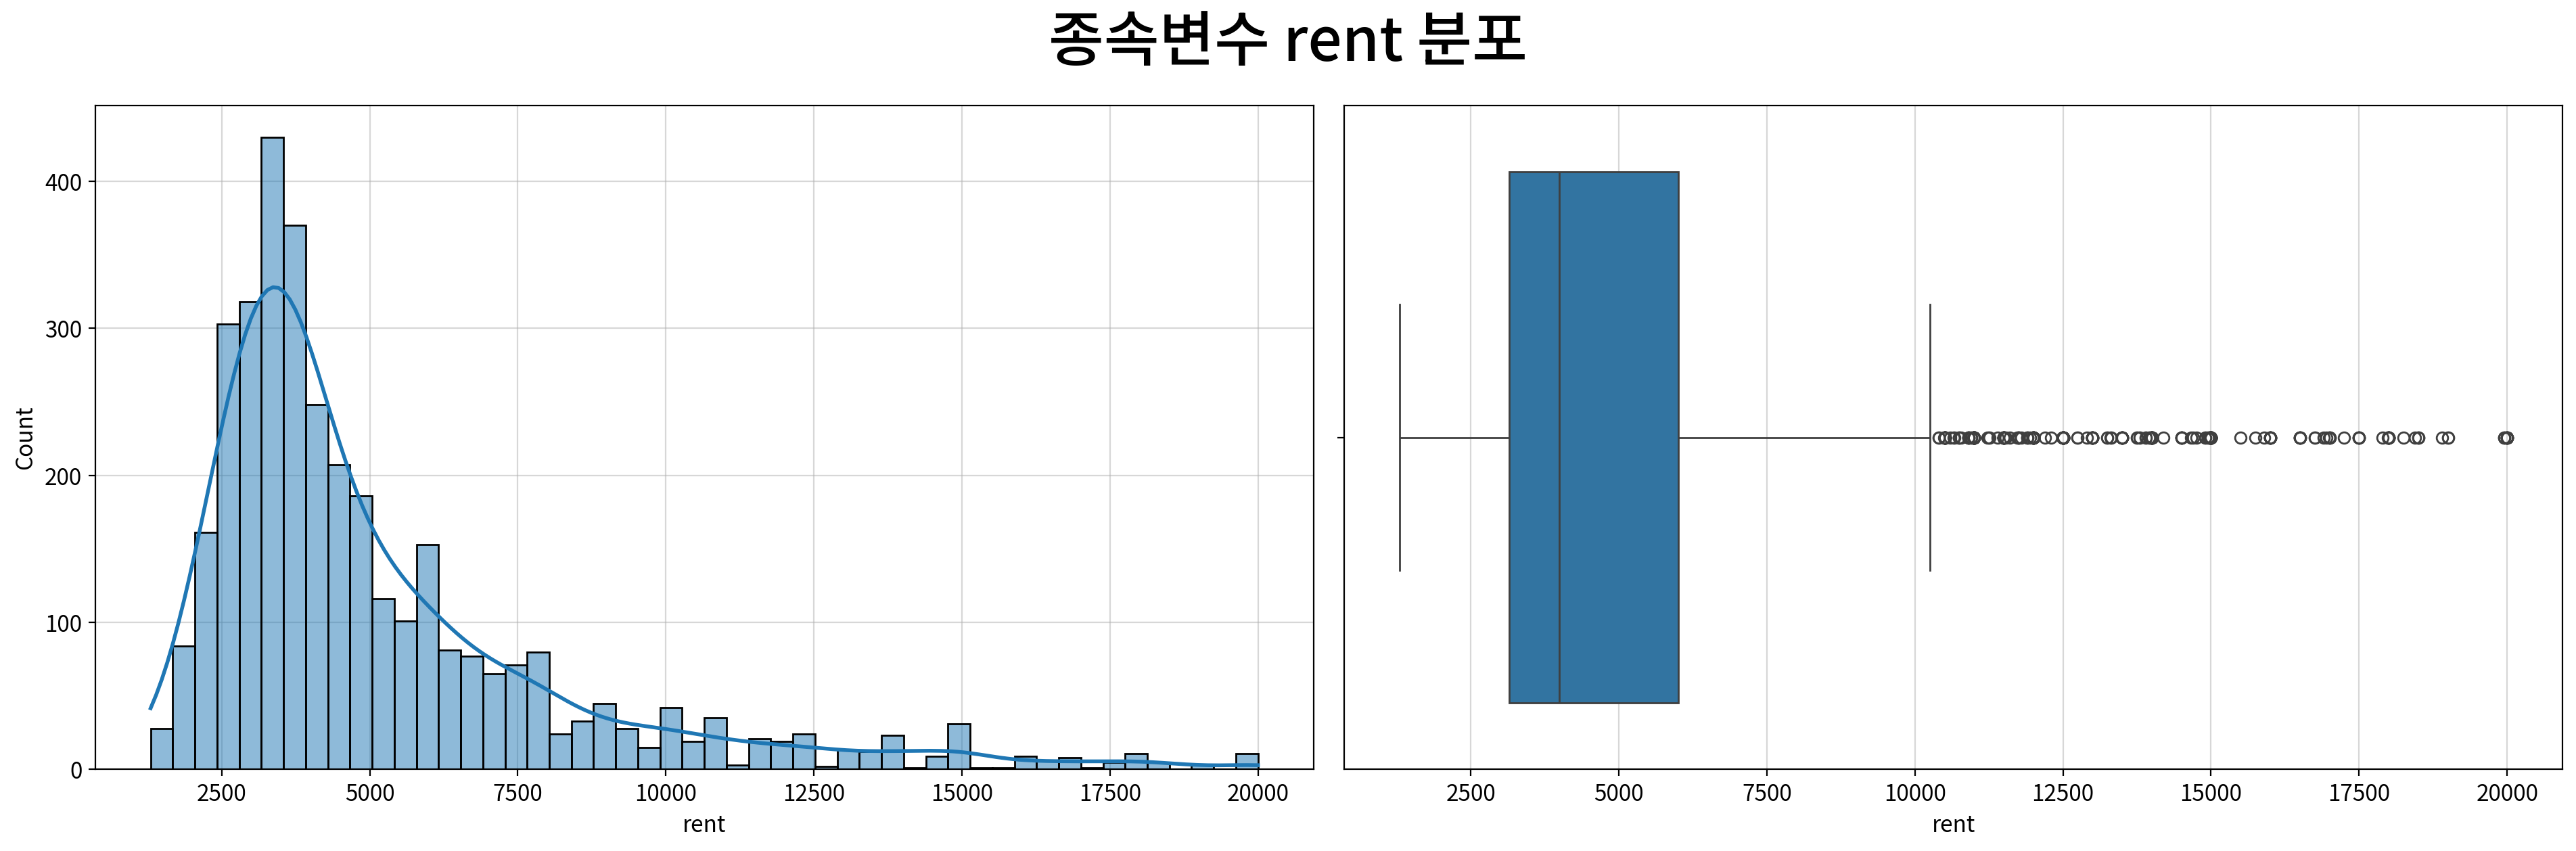

,rent
count,3512.000
mean,5142.887
std,3157.513
min,1300.000
25%,3169.250
50%,4000.000
75%,6000.000
max,20000.000
rel_diff,0.286
rdiff_flag,diff


In [18]:
fig, ax = my_plot.init(rows=1, cols=2,
                       title=f"종속변수 {target} 분포", width=960, height=640)
my_plot.histplot(data=df, x=target, kde=True, ax=ax[0])
my_plot.boxplot(data=df, x=target, ax=ax[1])
my_plot.show()

num_desc[num_desc.index == target].T

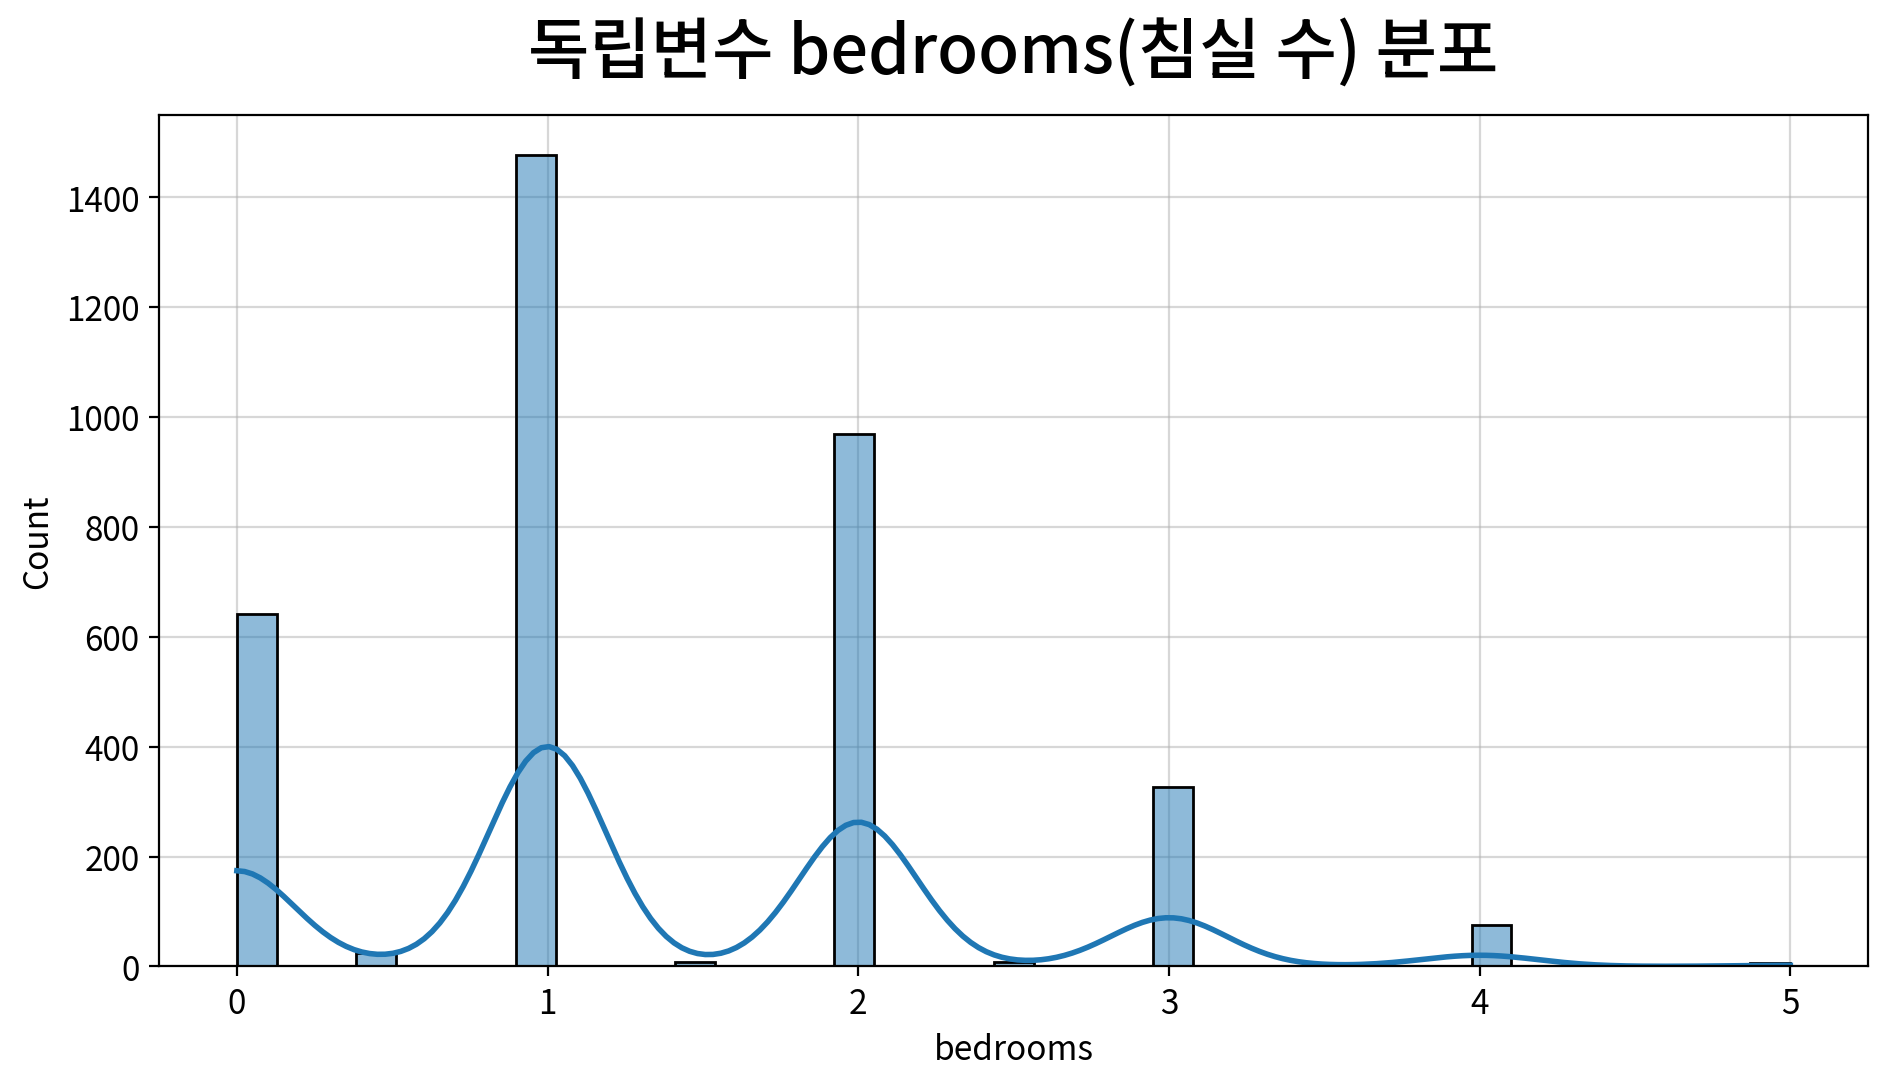

,bedrooms
count,3512.000
mean,1.354
std,0.968
min,0.000
25%,1.000
50%,1.000
75%,2.000
max,5.000
rel_diff,0.354
rdiff_flag,diff


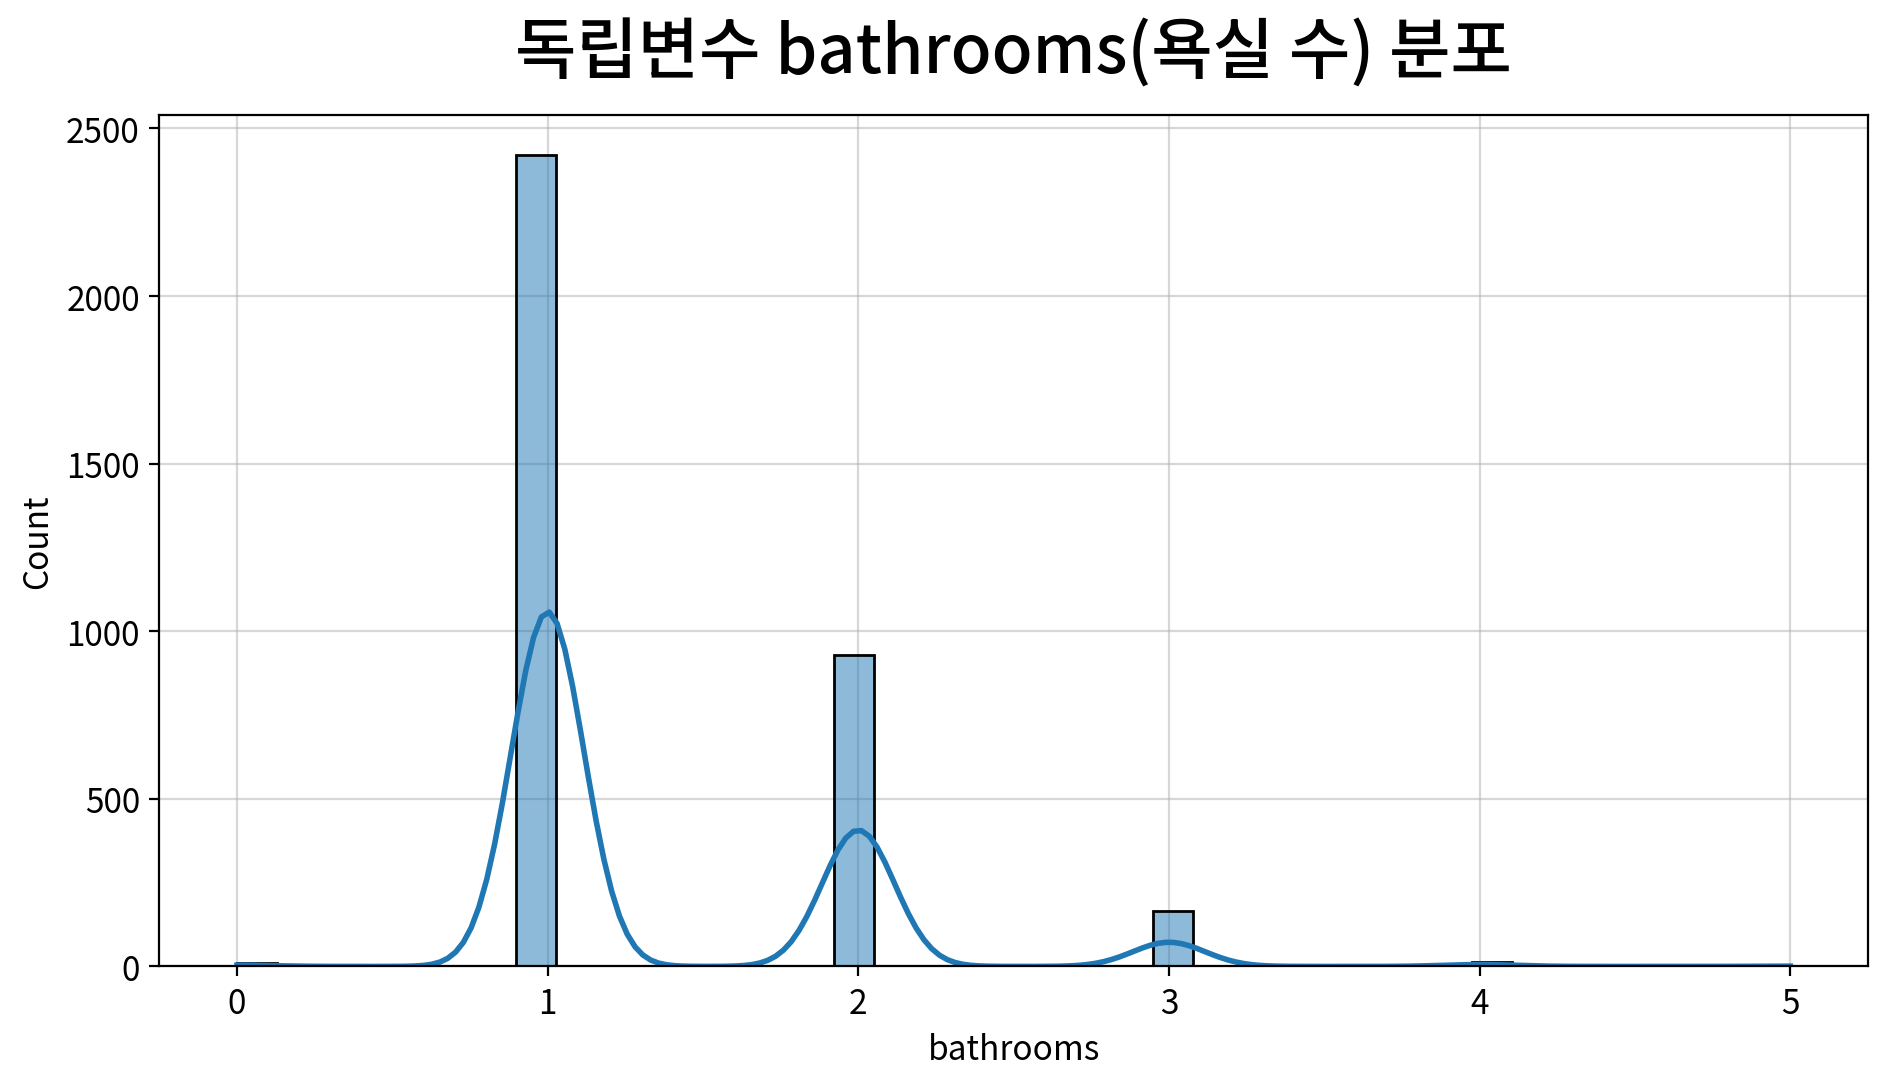

,bathrooms
count,3512.000
mean,1.367
std,0.600
min,0.000
25%,1.000
50%,1.000
75%,2.000
max,5.000
rel_diff,0.367
rdiff_flag,diff


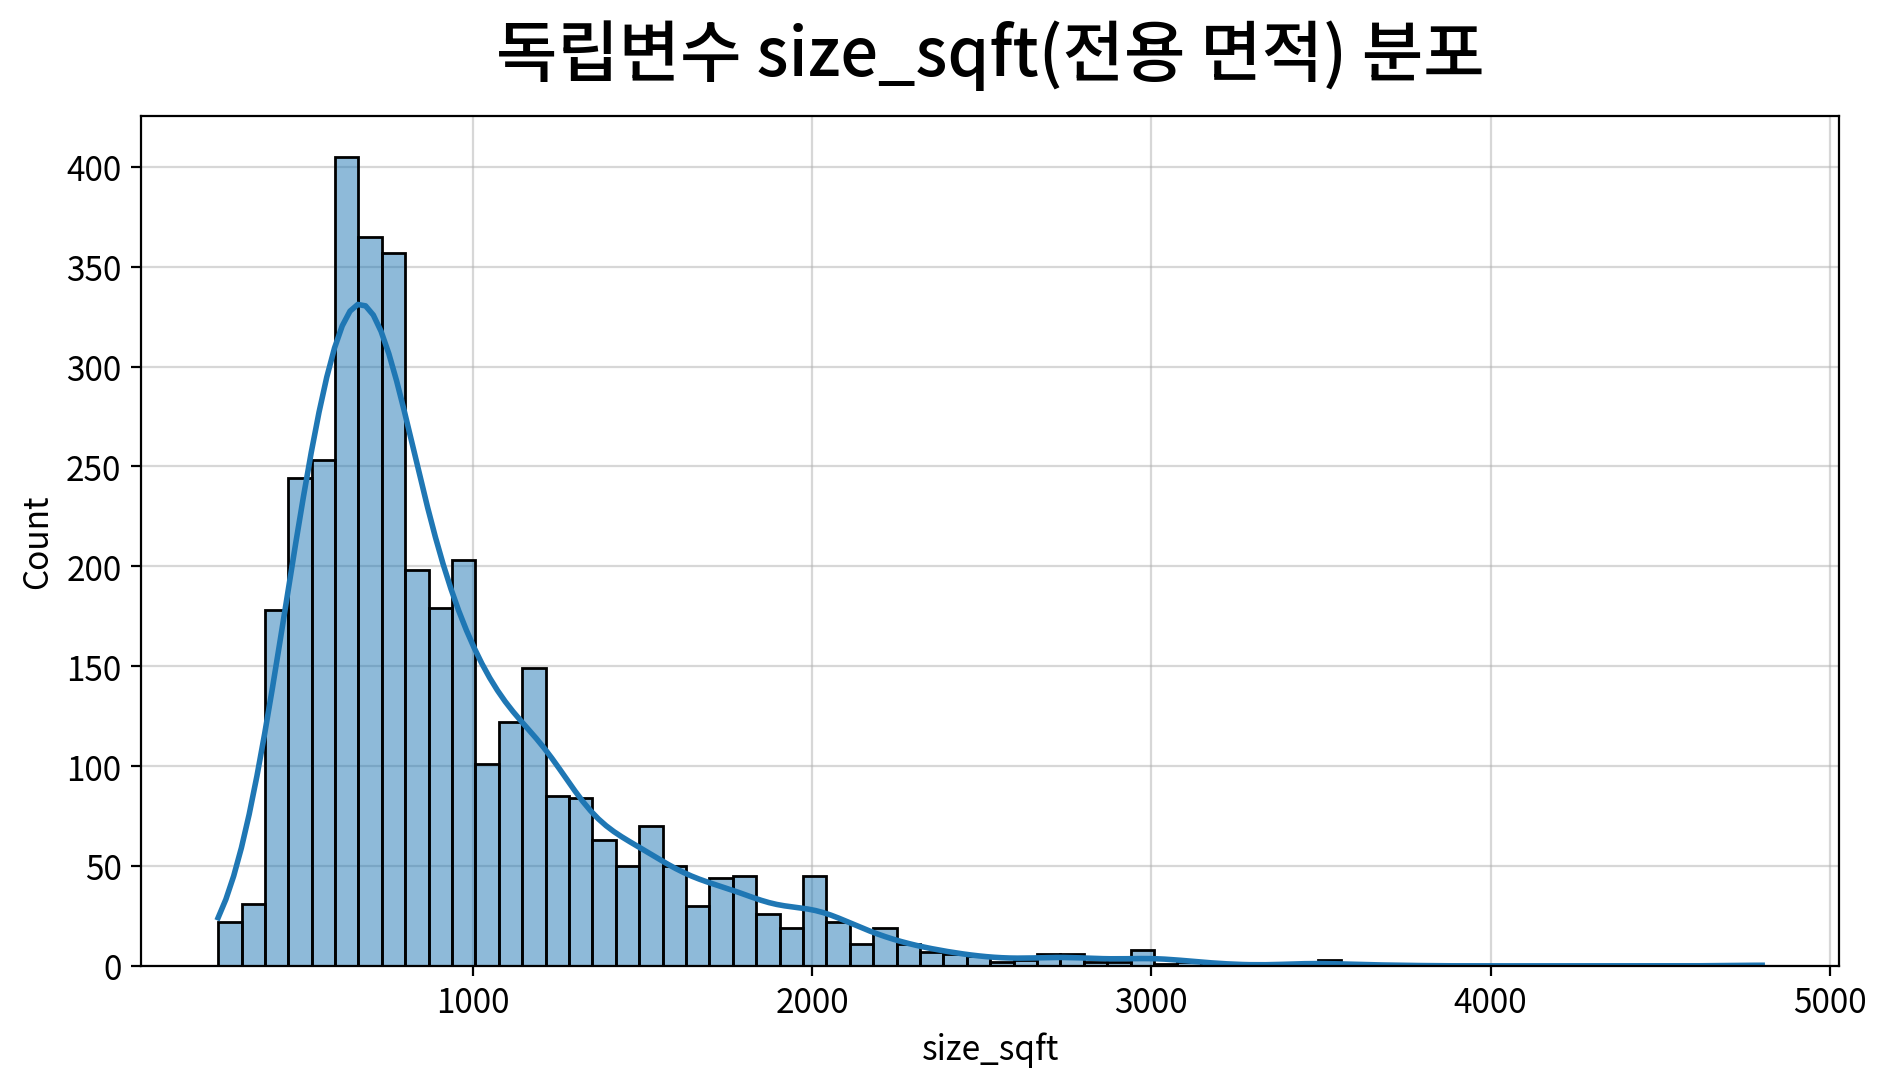

,size_sqft
count,3512.000
mean,940.287
std,478.290
min,250.000
25%,615.000
50%,800.000
75%,1141.500
max,4800.000
rel_diff,0.175
rdiff_flag,diff


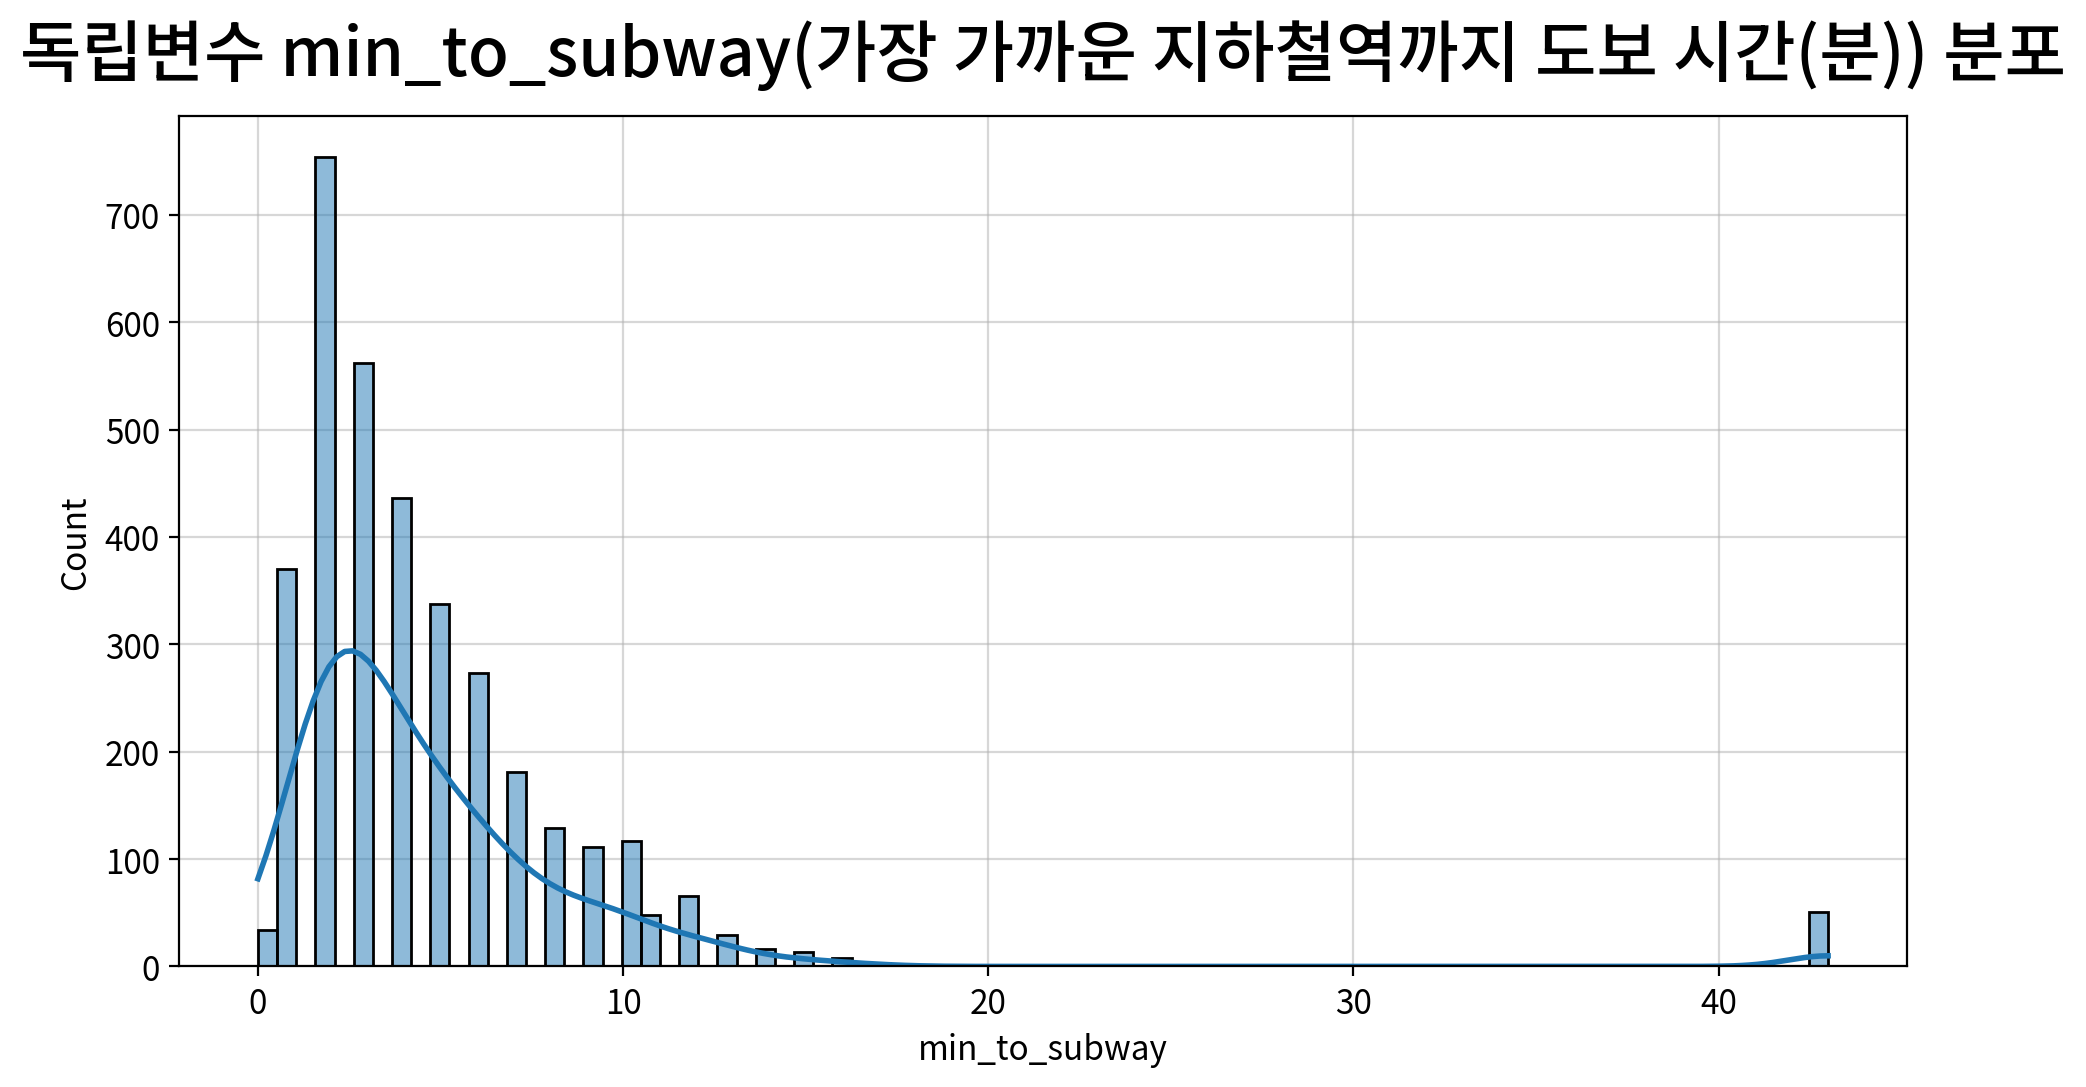

,min_to_subway
count,3512.000
mean,4.965
std,5.489
min,0.000
25%,2.000
50%,4.000
75%,6.000
max,43.000
rel_diff,0.241
rdiff_flag,diff


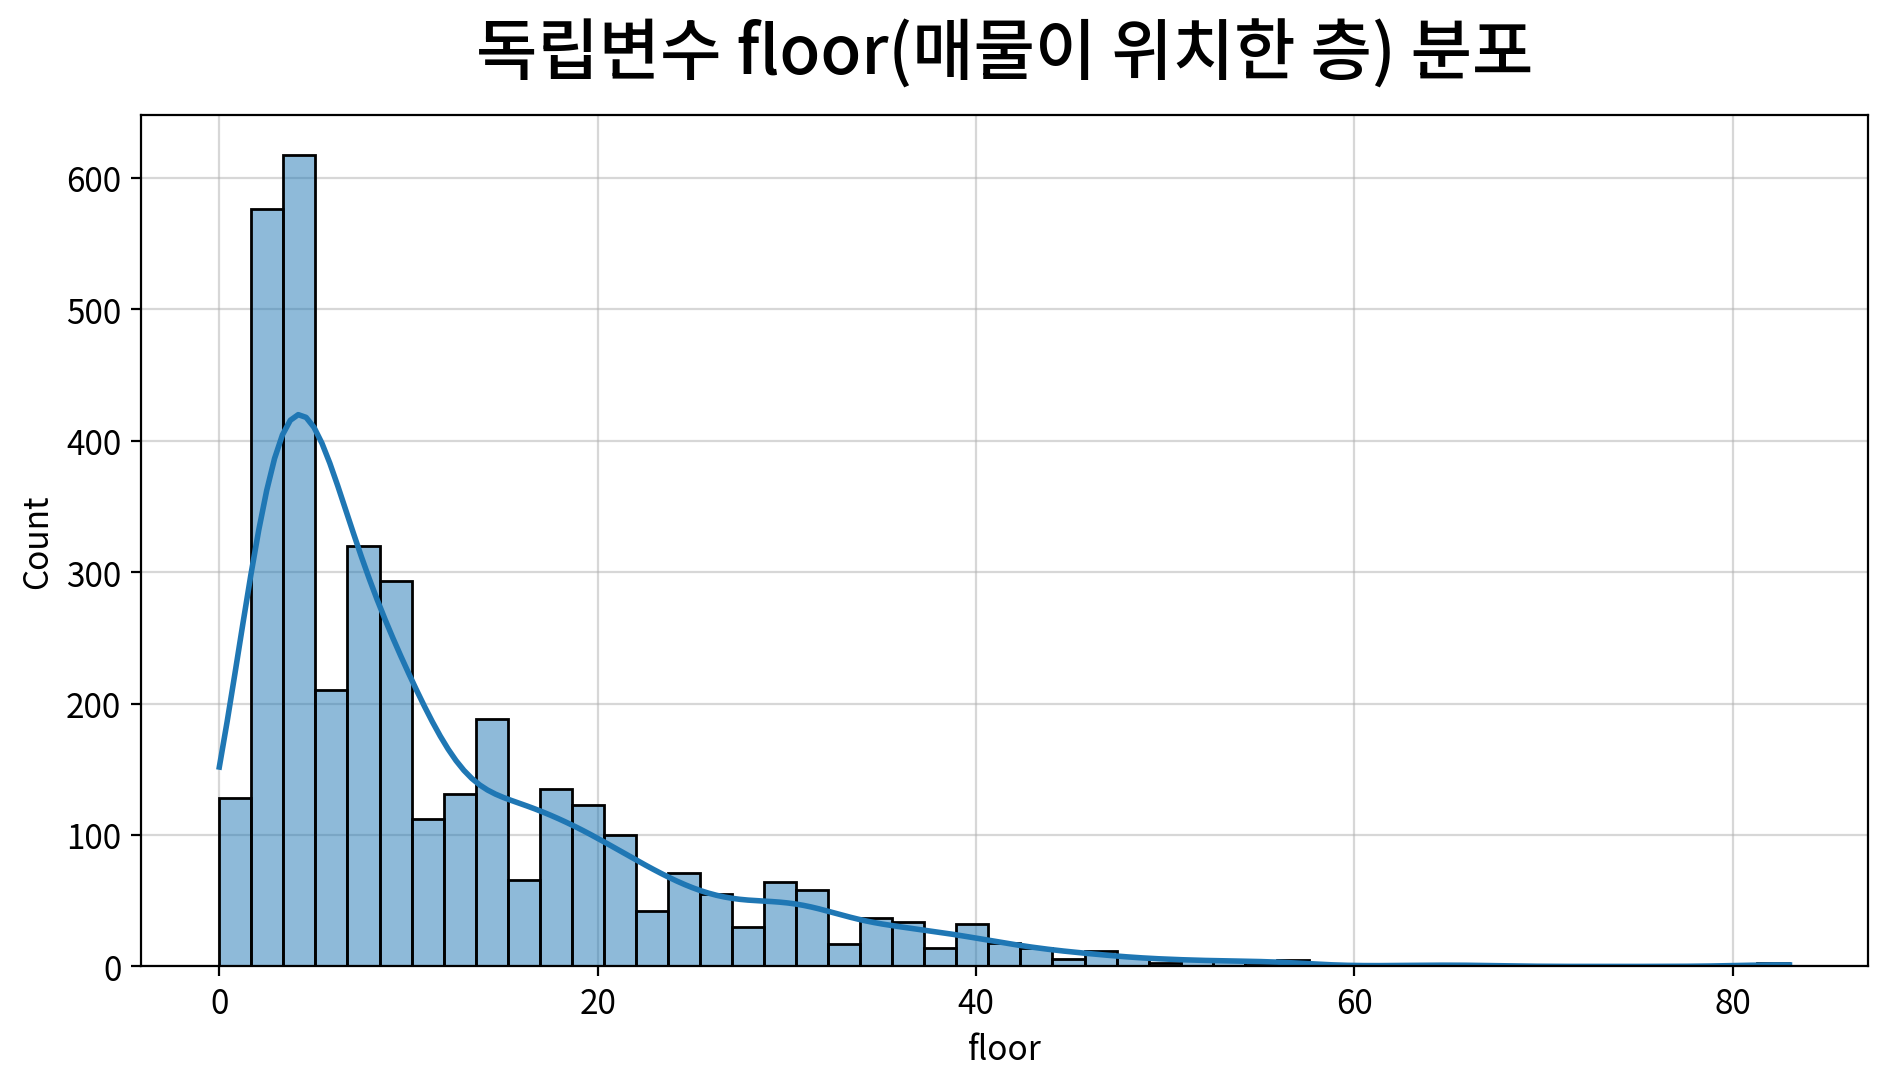

,floor
count,3512.000
mean,11.887
std,10.928
min,0.000
25%,4.000
50%,8.000
75%,17.000
max,83.000
rel_diff,0.486
rdiff_flag,diff


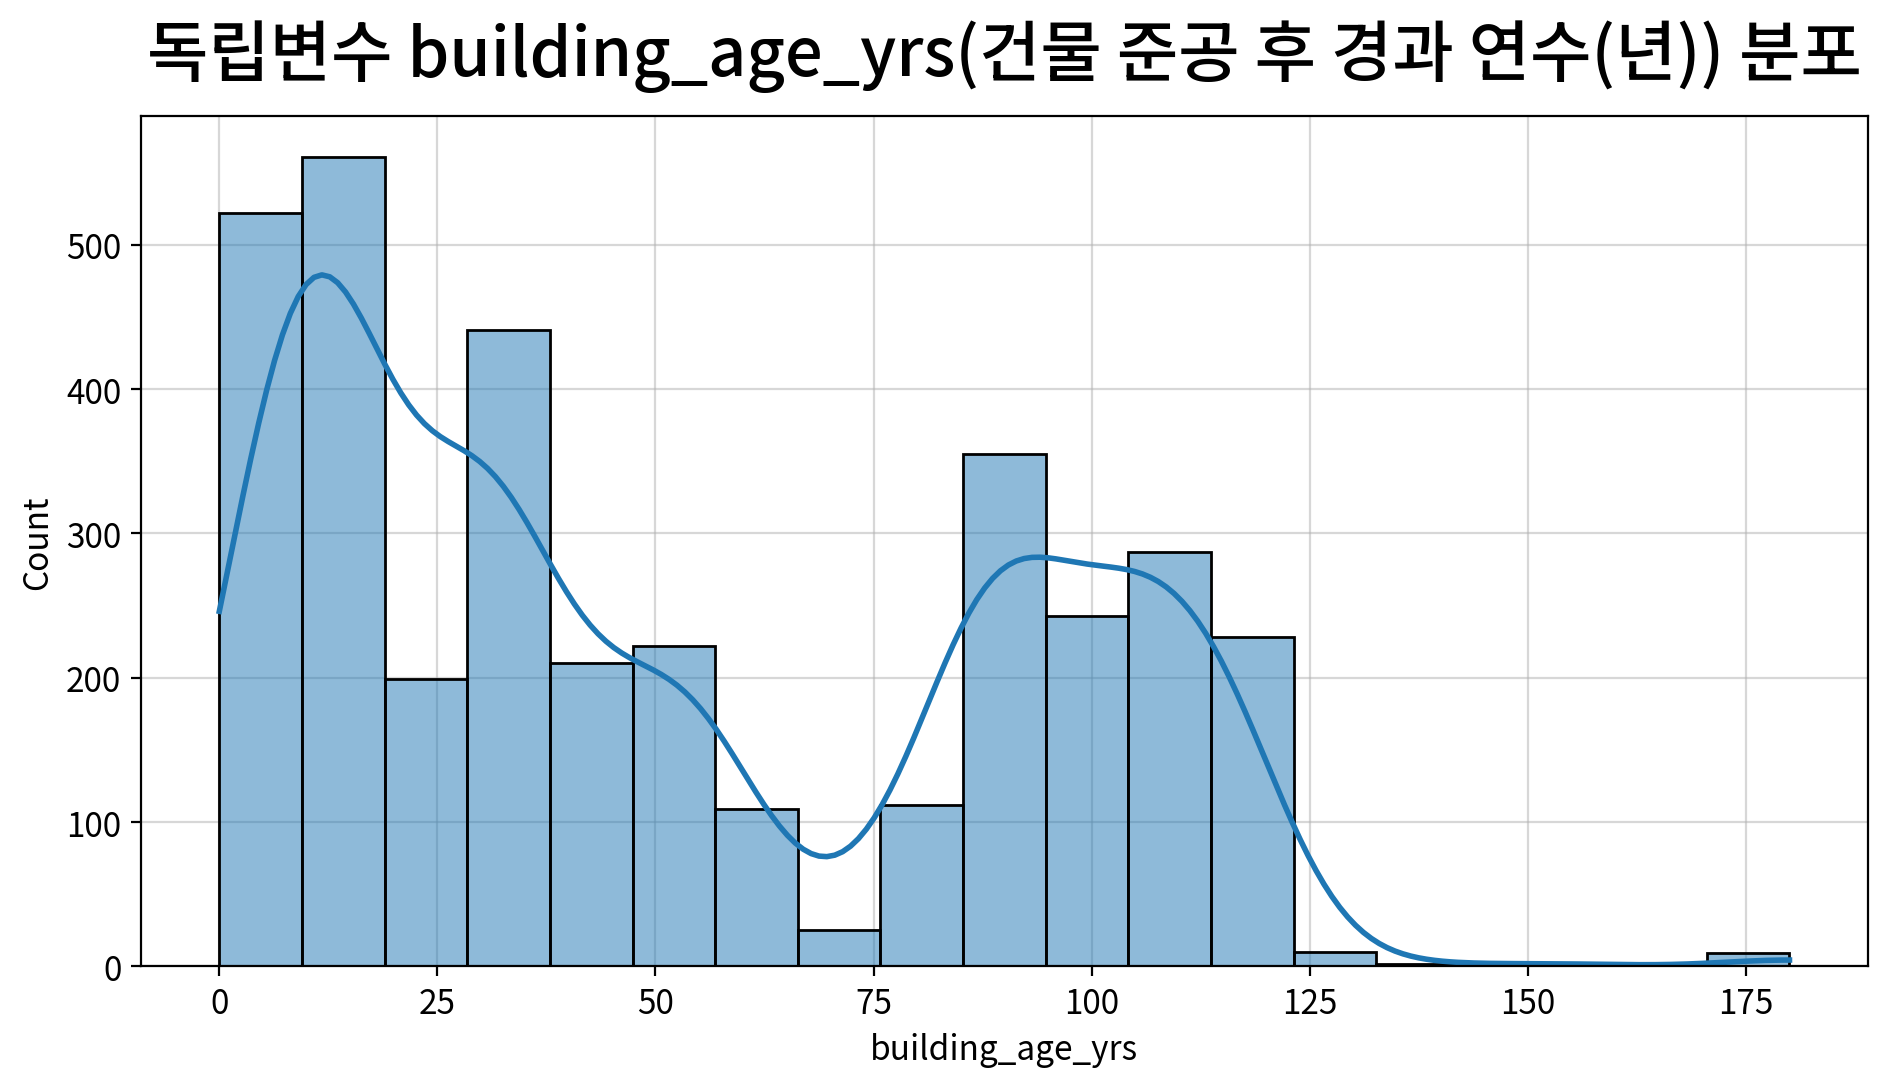

,building_age_yrs
count,3512.000
mean,51.958
std,39.420
min,0.000
25%,15.000
50%,39.000
75%,90.000
max,180.000
rel_diff,0.332
rdiff_flag,diff


In [19]:
for f in continuous_cols:
    # 히스토그램 및 박스플롯을 1행 2열 서브플롯으로 구성하는 경우
    #fig, ax = my_plot.init(rows=1, cols=2, width=960, height=640,
    #                      title=f"독립변수 {f}({column_means[f]}) 분포")
    #my_plot.histplot(data=df, x=f, kde=True, ax=ax[0])
    #my_plot.boxplot(data=df, x=f, ax=ax[1])
    #my_plot.show()

    # 히스토그램만 그리는 경우
    my_plot.histplot(data=df, x=f, kde=True, width=960, height=560,
                     title=f"독립변수 {f}({column_means[f]}) 분포")

    display(num_desc[num_desc.index == f].T)

### 미션2

1. 기술통계량 표 및 종속변수 분포 그래프 확인 결과 종속변수 rent의 로그 변환을 고려해야 함.

2. 로그 변환 후보 목록은 ['min_to_subway', 'size_sqft', 'floor', 'bathrooms', 'bedrooms'] 순서이며, 왜도 기준으로 0.5 이상을 후보로 놓았고, 1.0 이상은 강한 후보로 채택.

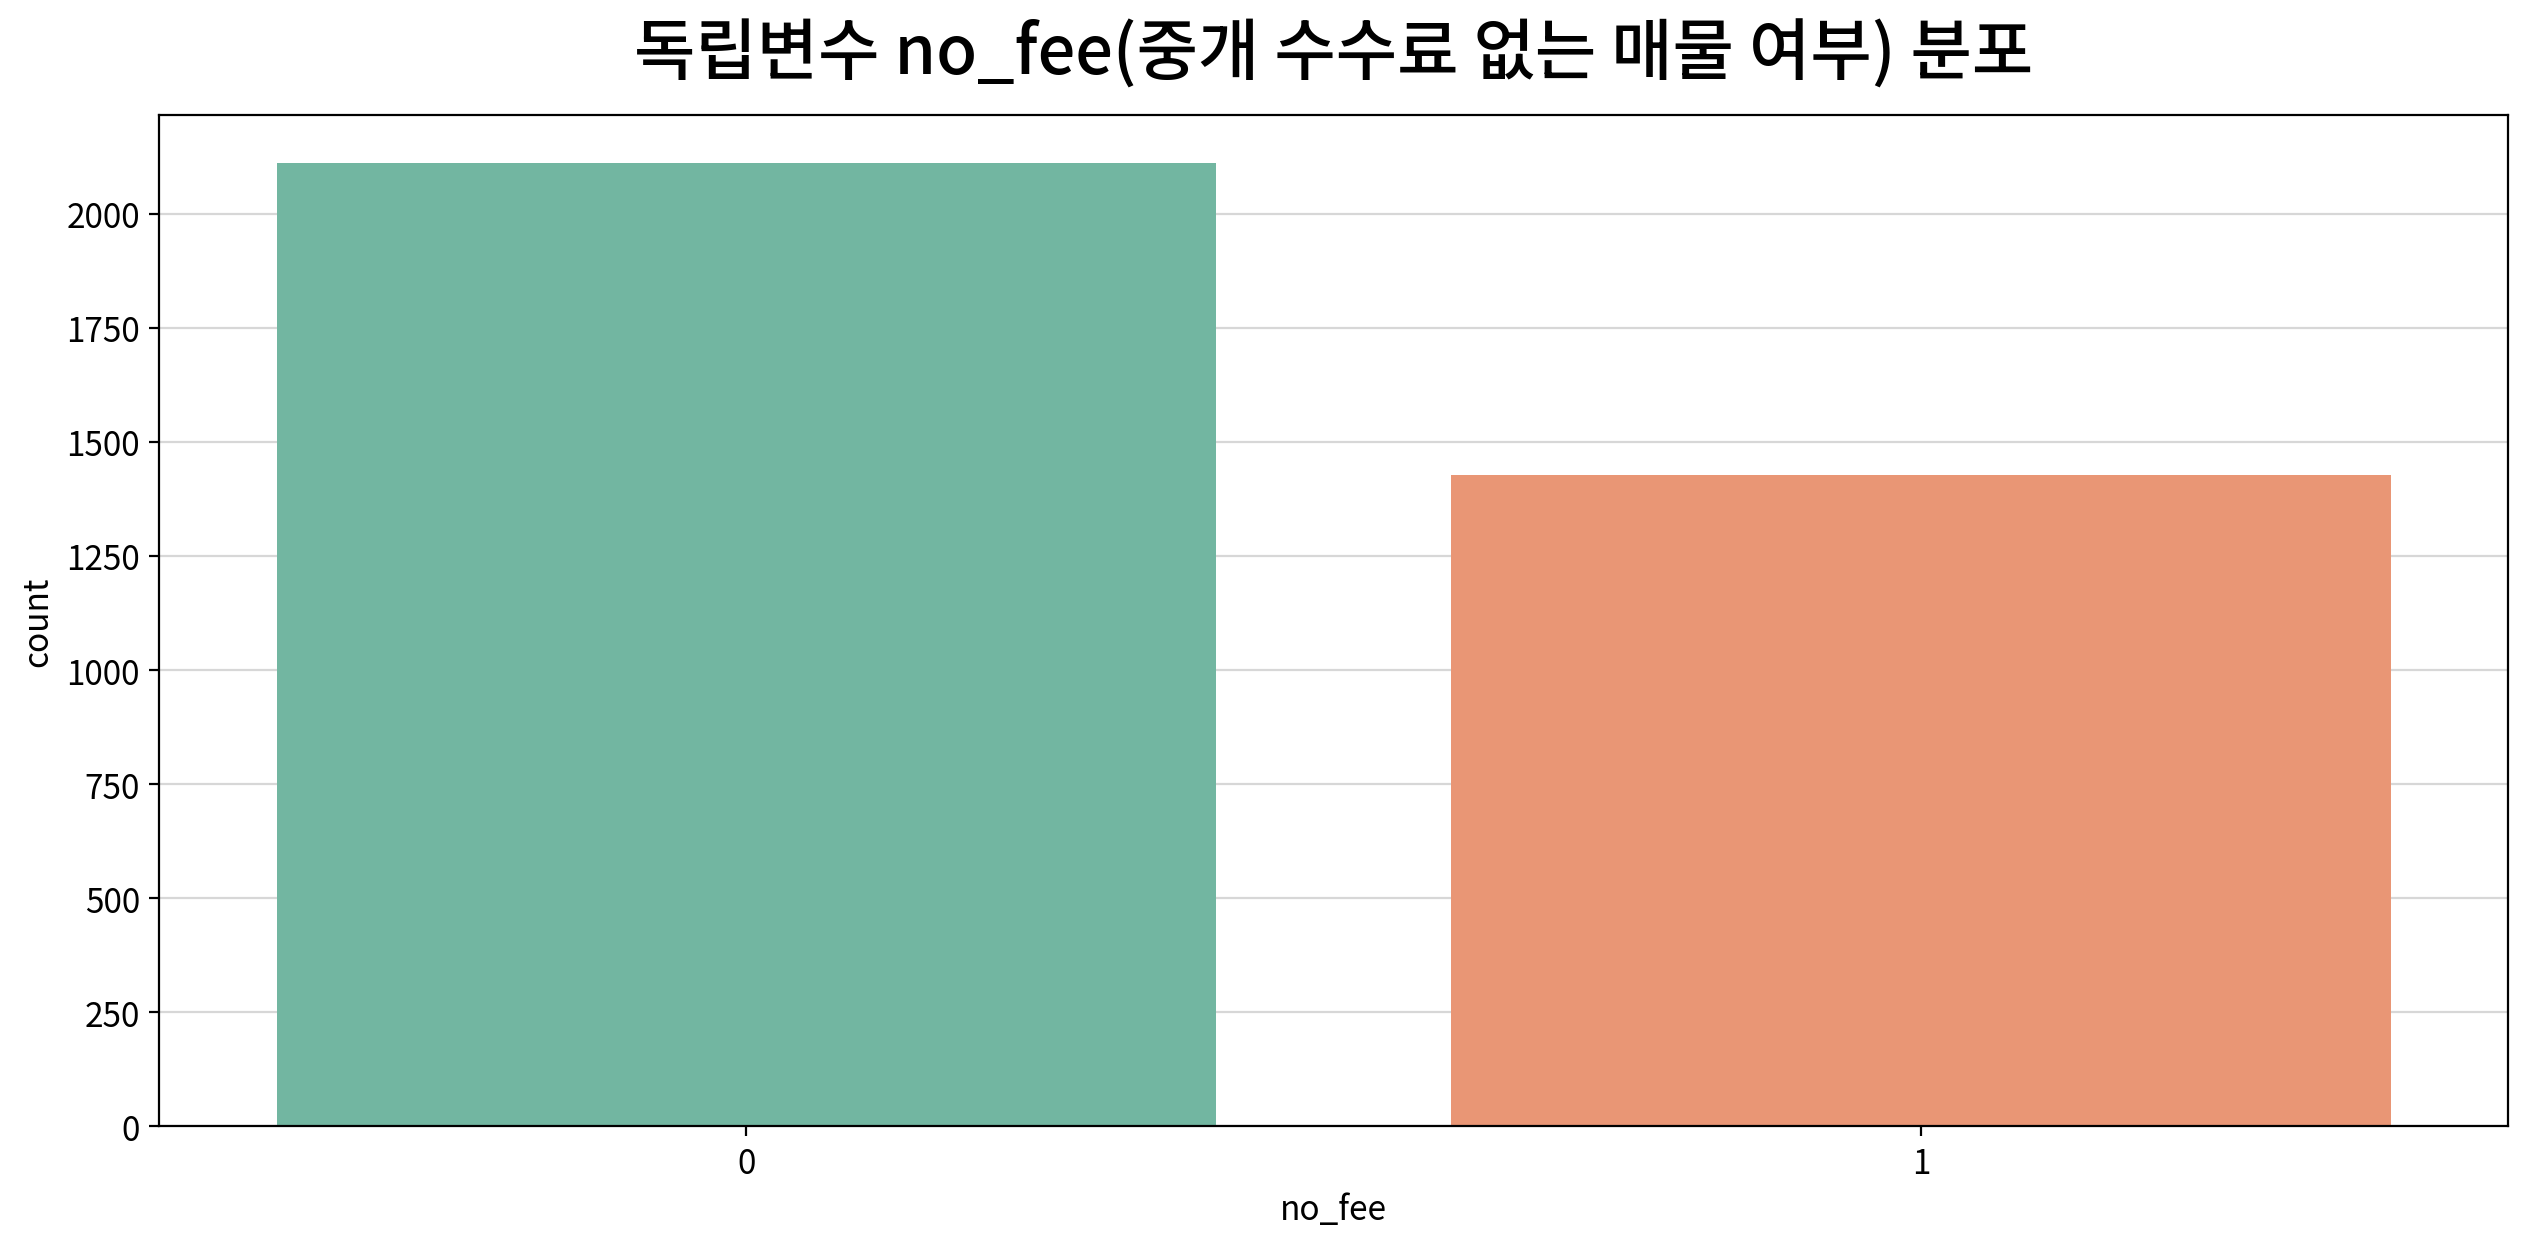

,count,unique,top,freq
no_fee,3512,2,0,2091


,빈도,비율
no_fee,,
0,2111,0.596
1,1428,0.404


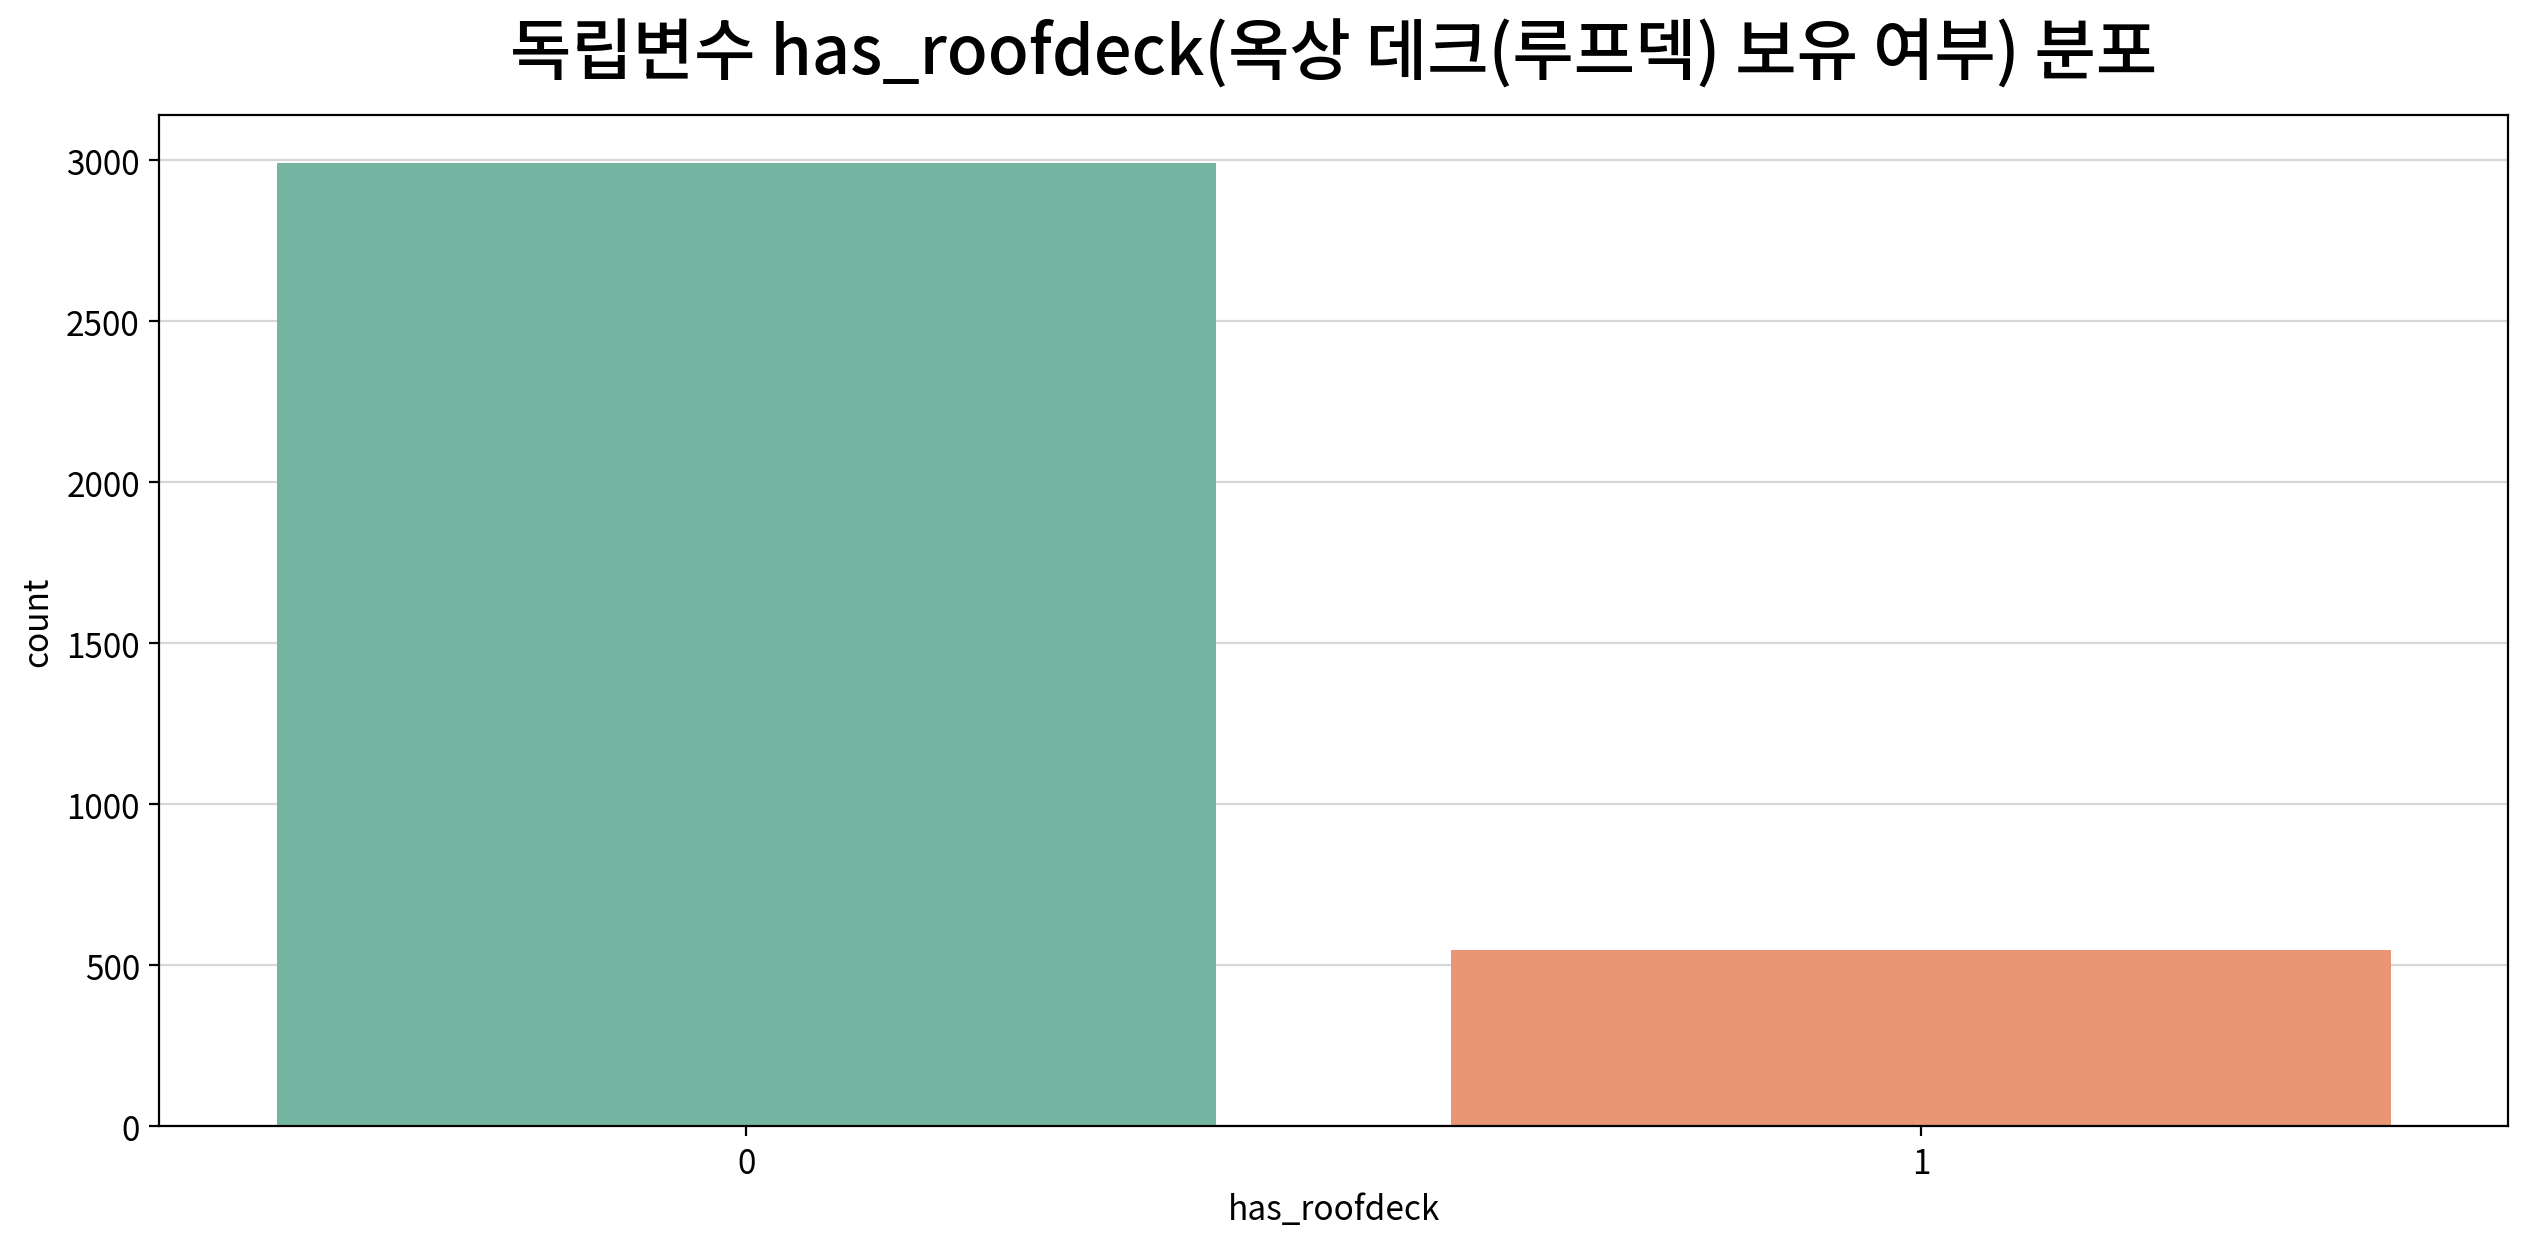

,count,unique,top,freq
has_roofdeck,3512,2,0,2967


,빈도,비율
has_roofdeck,,
0,2991,0.845
1,548,0.155


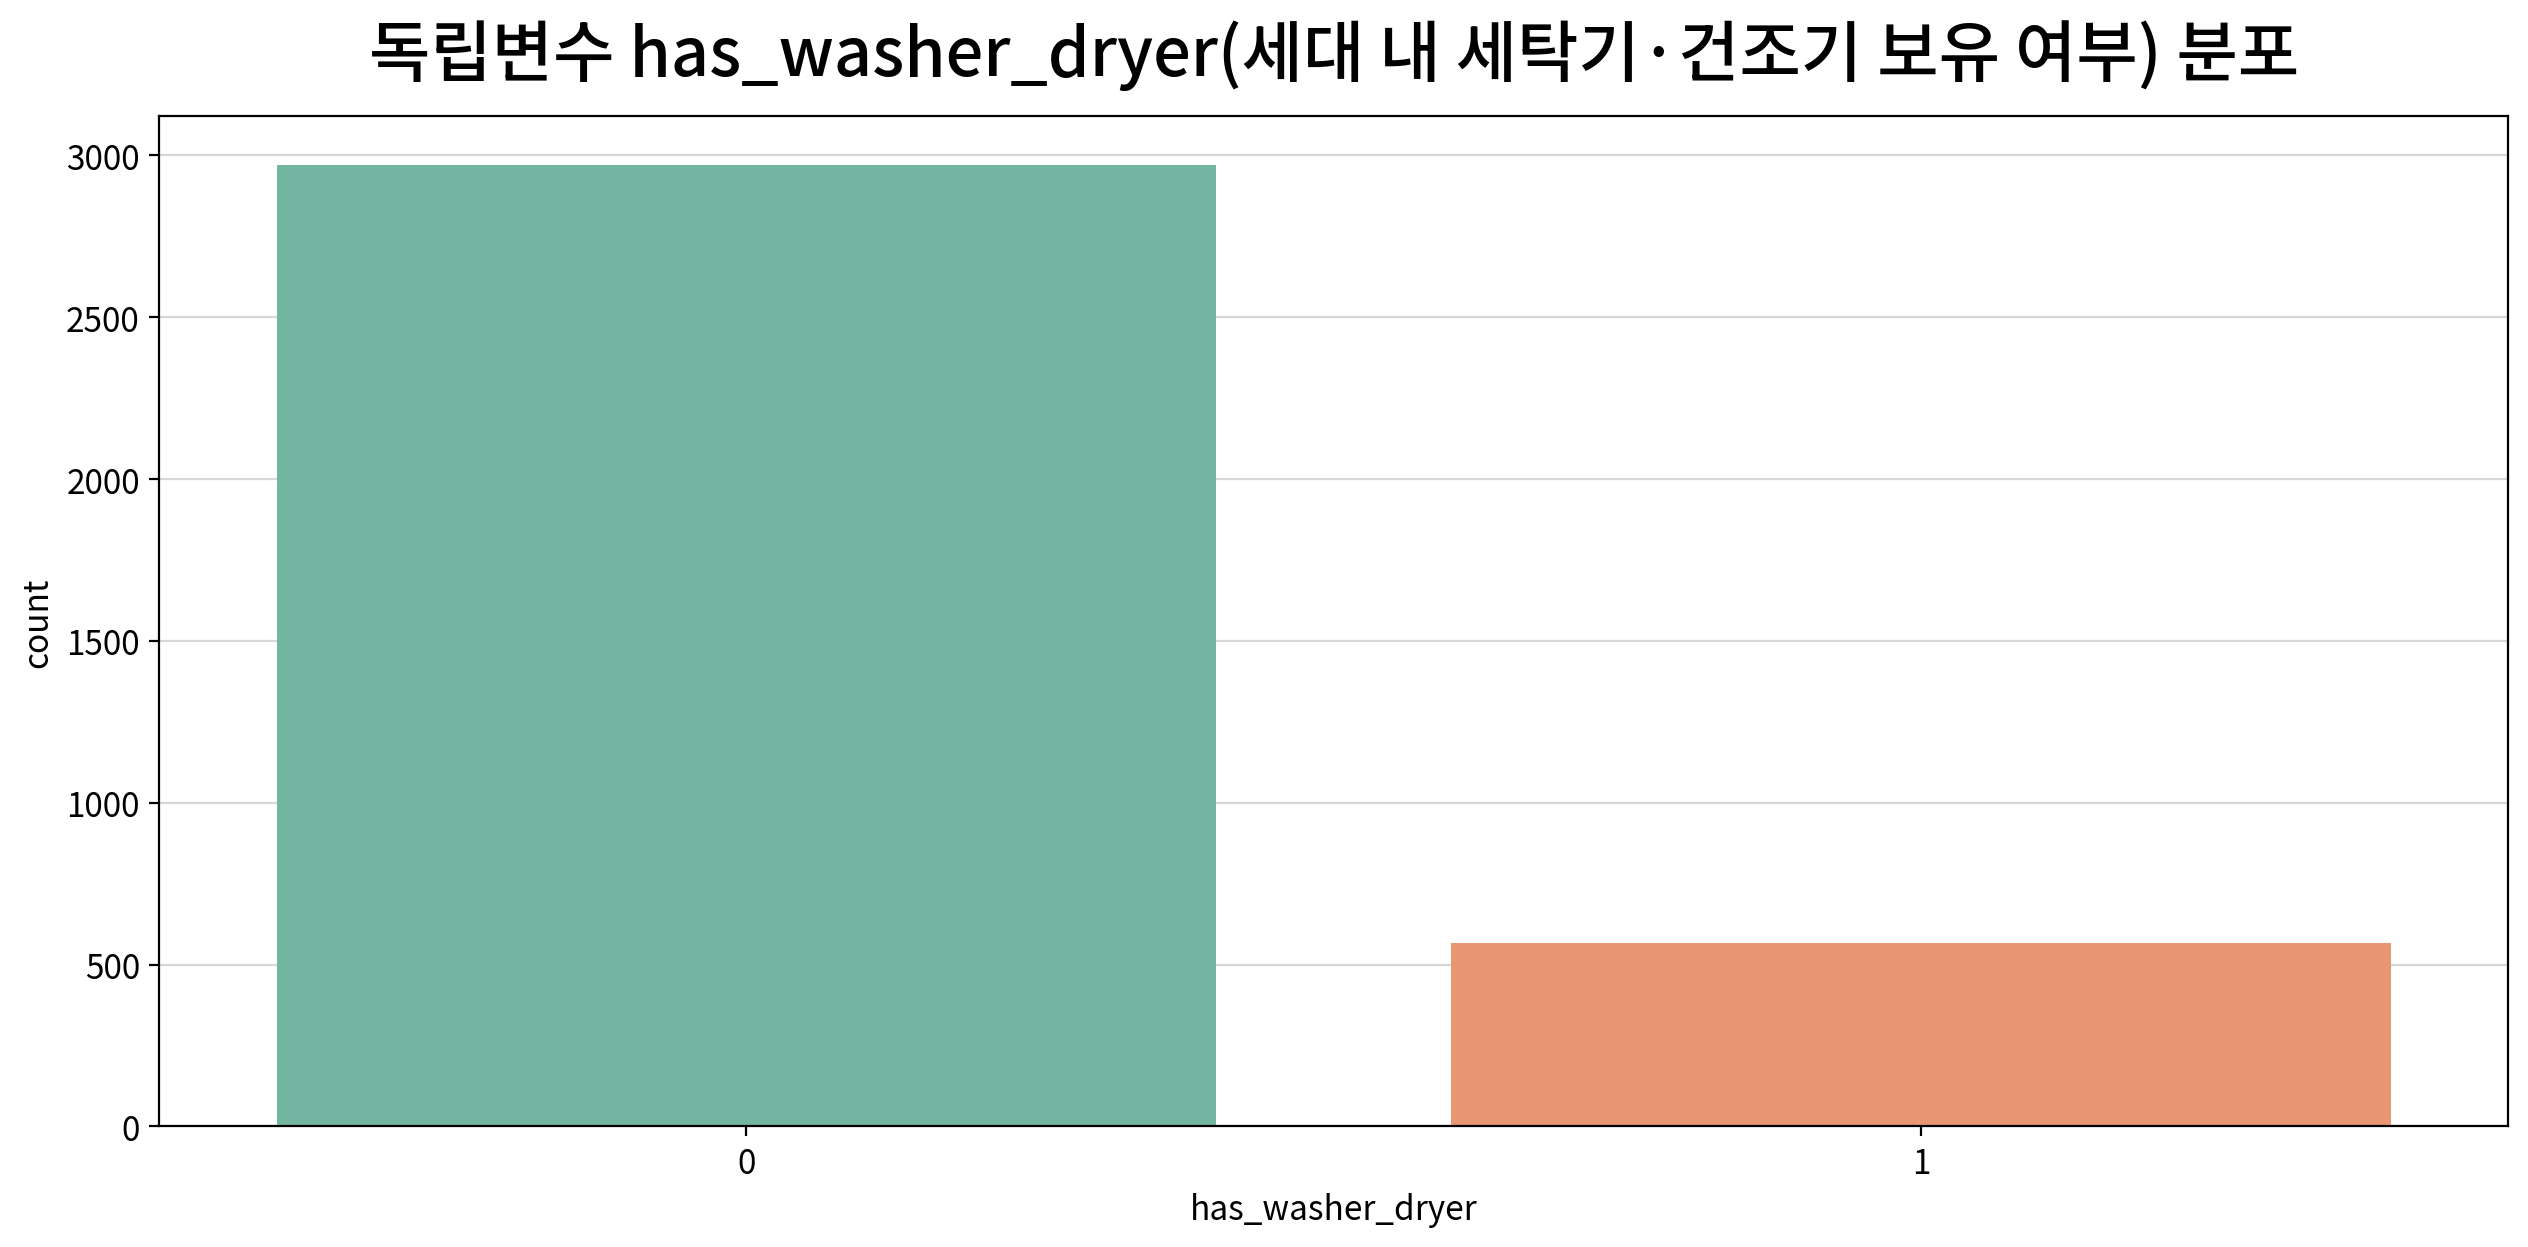

,count,unique,top,freq
has_washer_dryer,3512,2,0,2947


,빈도,비율
has_washer_dryer,,
0,2972,0.840
1,567,0.160


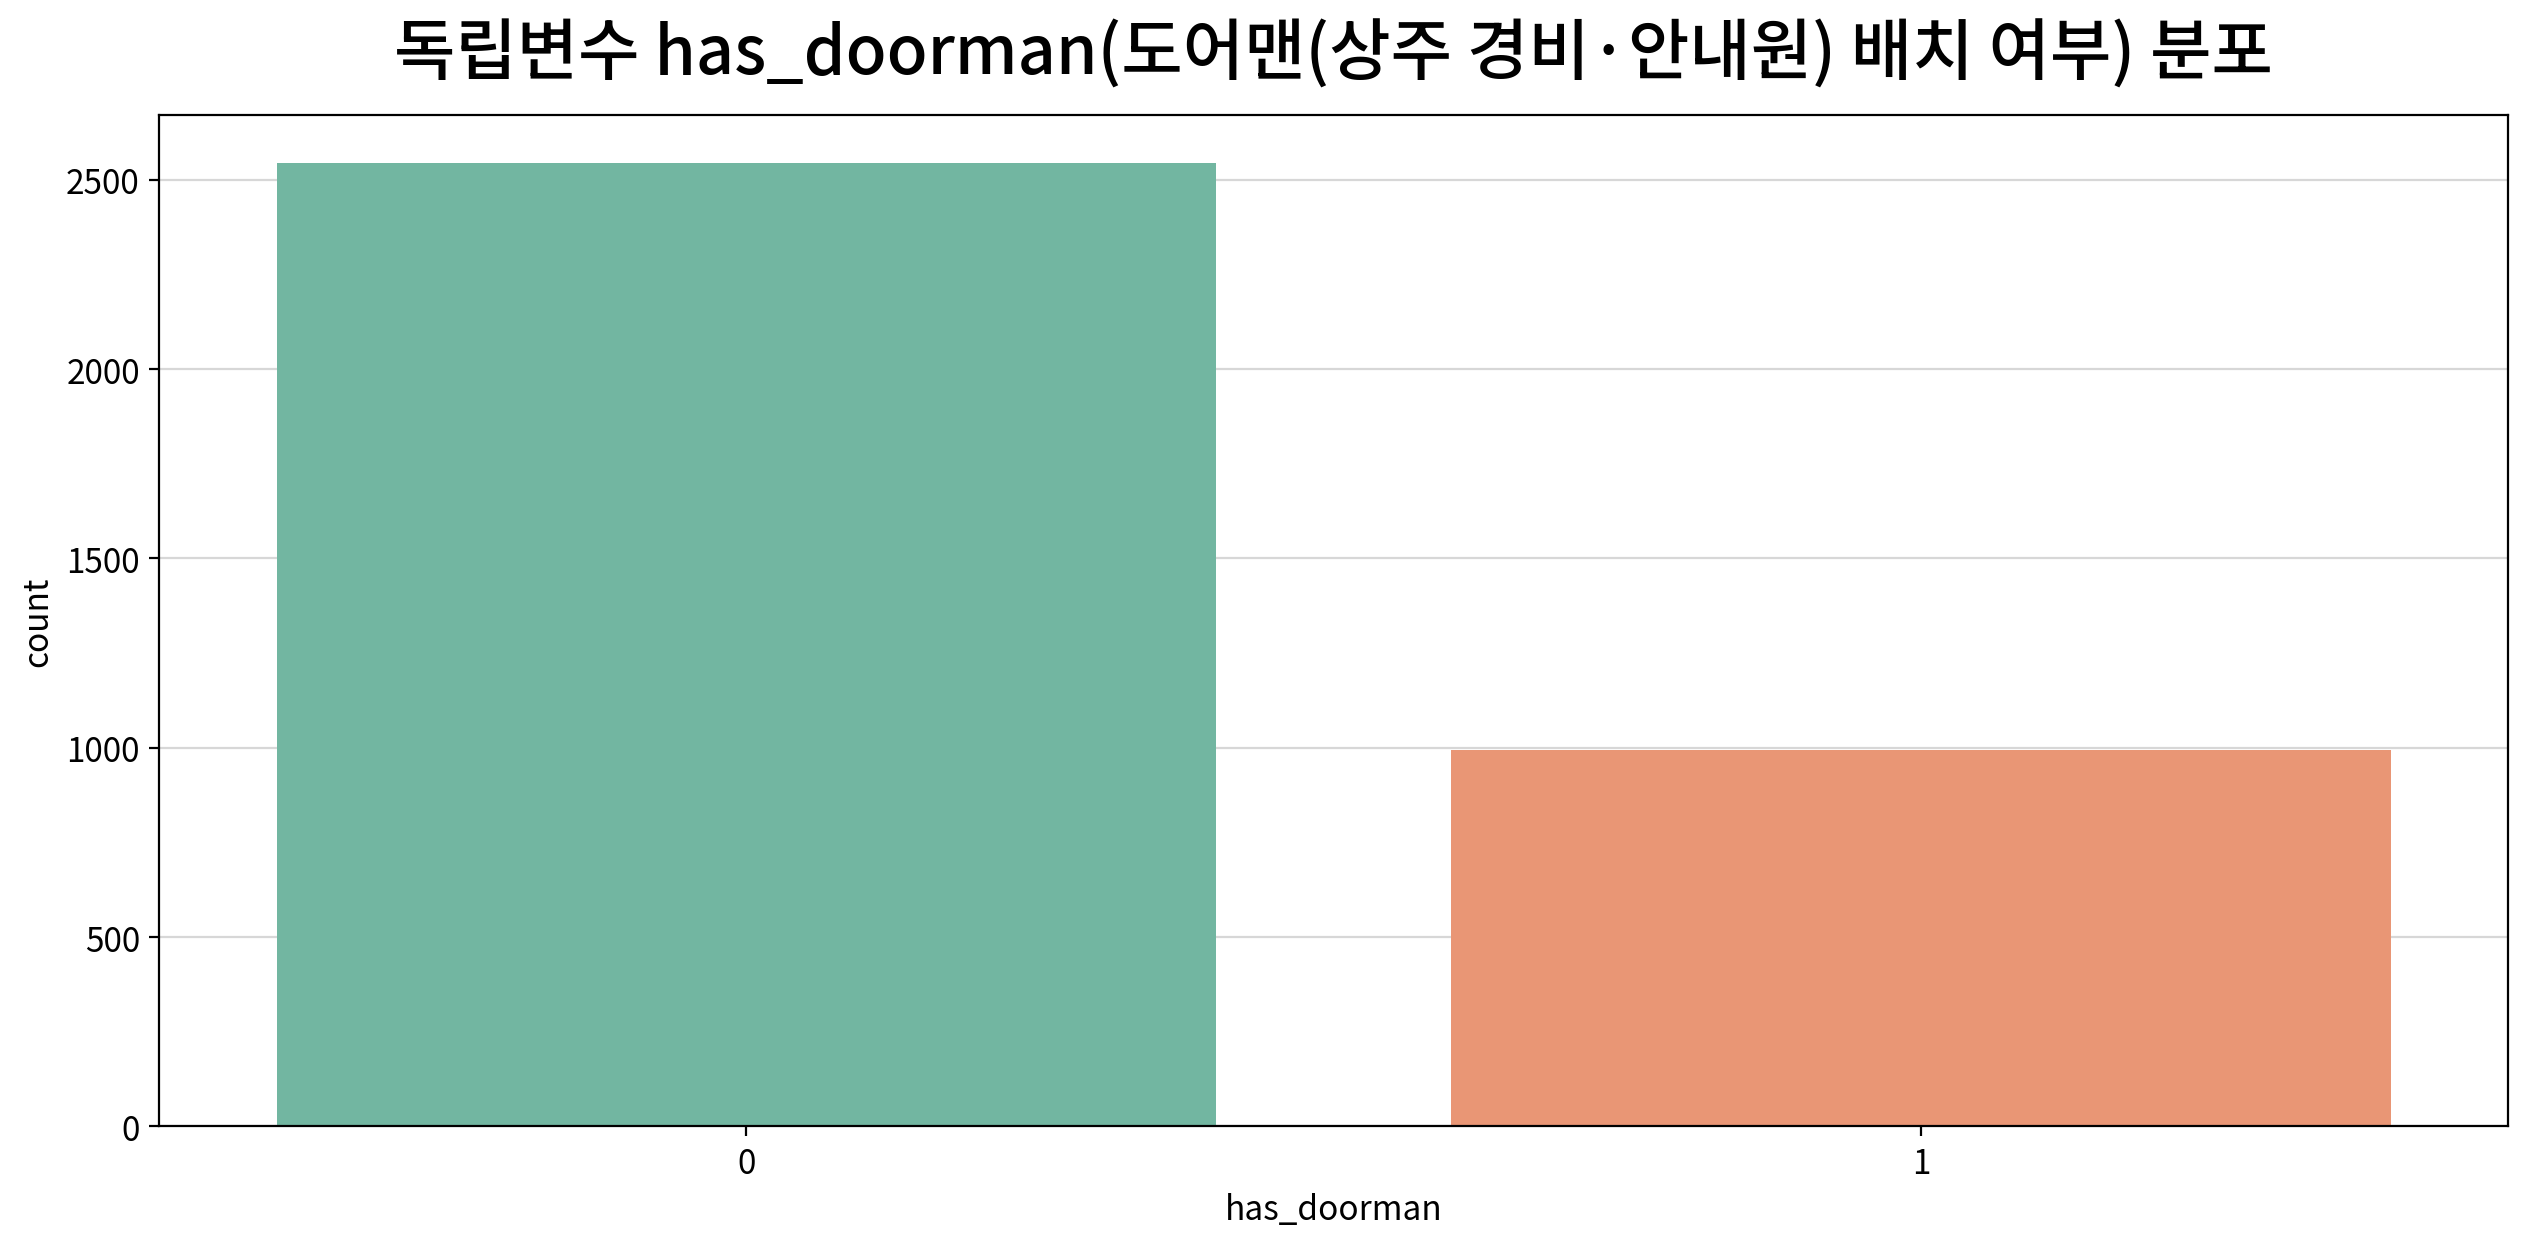

,count,unique,top,freq
has_doorman,3512,2,0,2529


,빈도,비율
has_doorman,,
0,2544,0.719
1,995,0.281


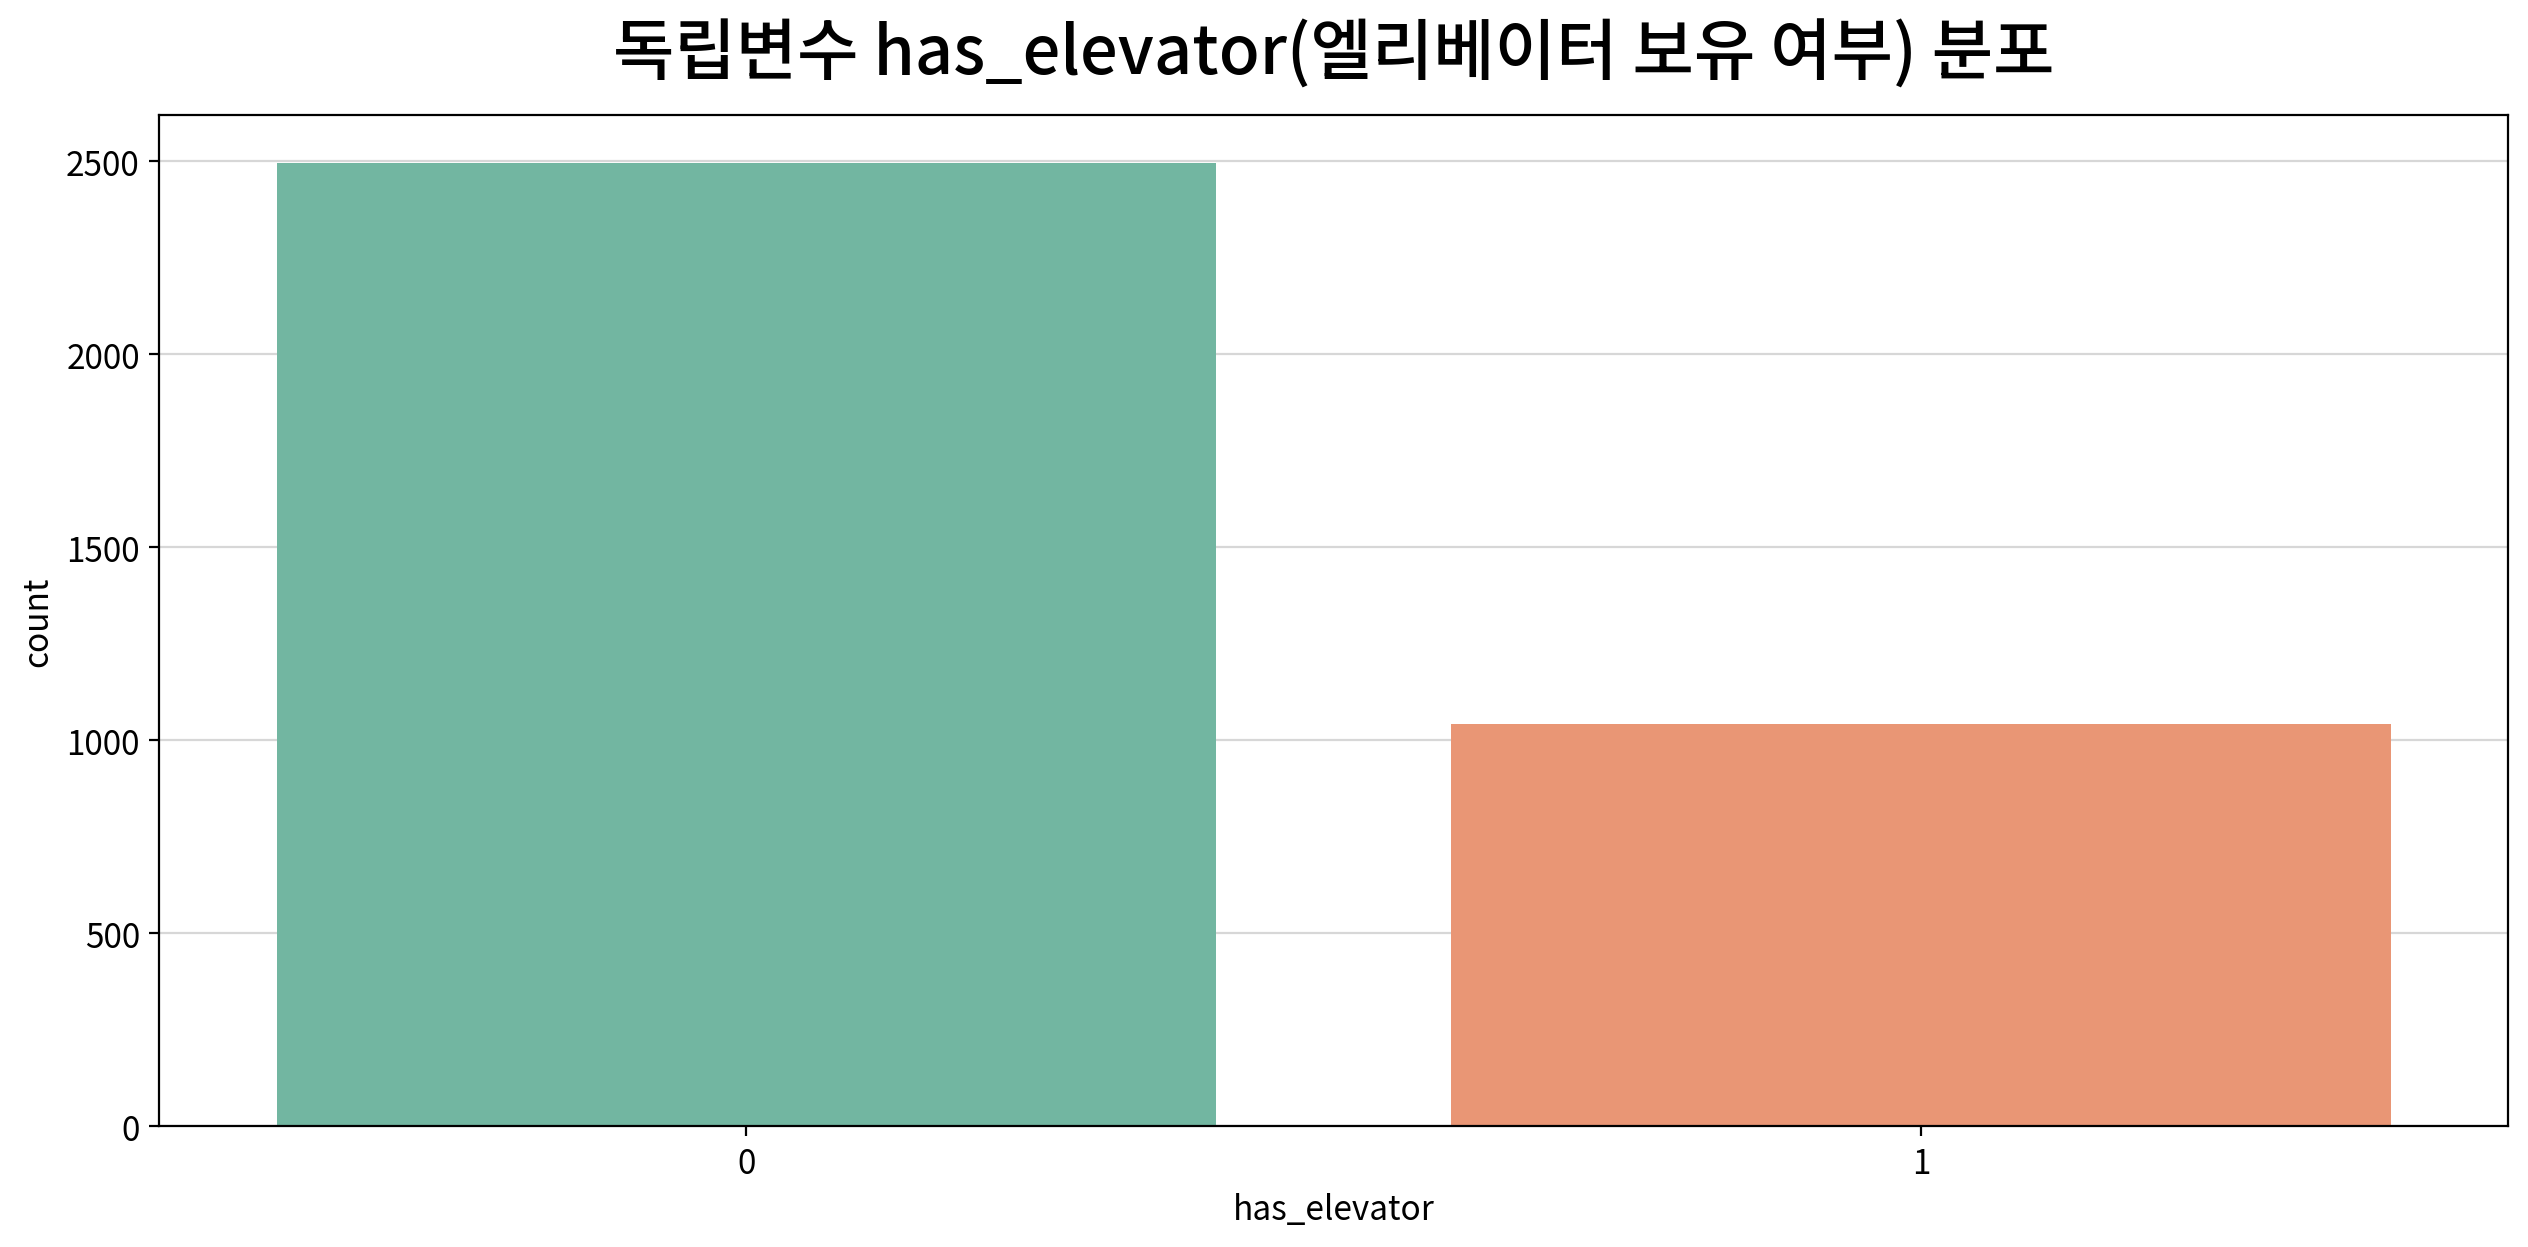

,count,unique,top,freq
has_elevator,3512,2,0,2479


,빈도,비율
has_elevator,,
0,2496,0.705
1,1043,0.295


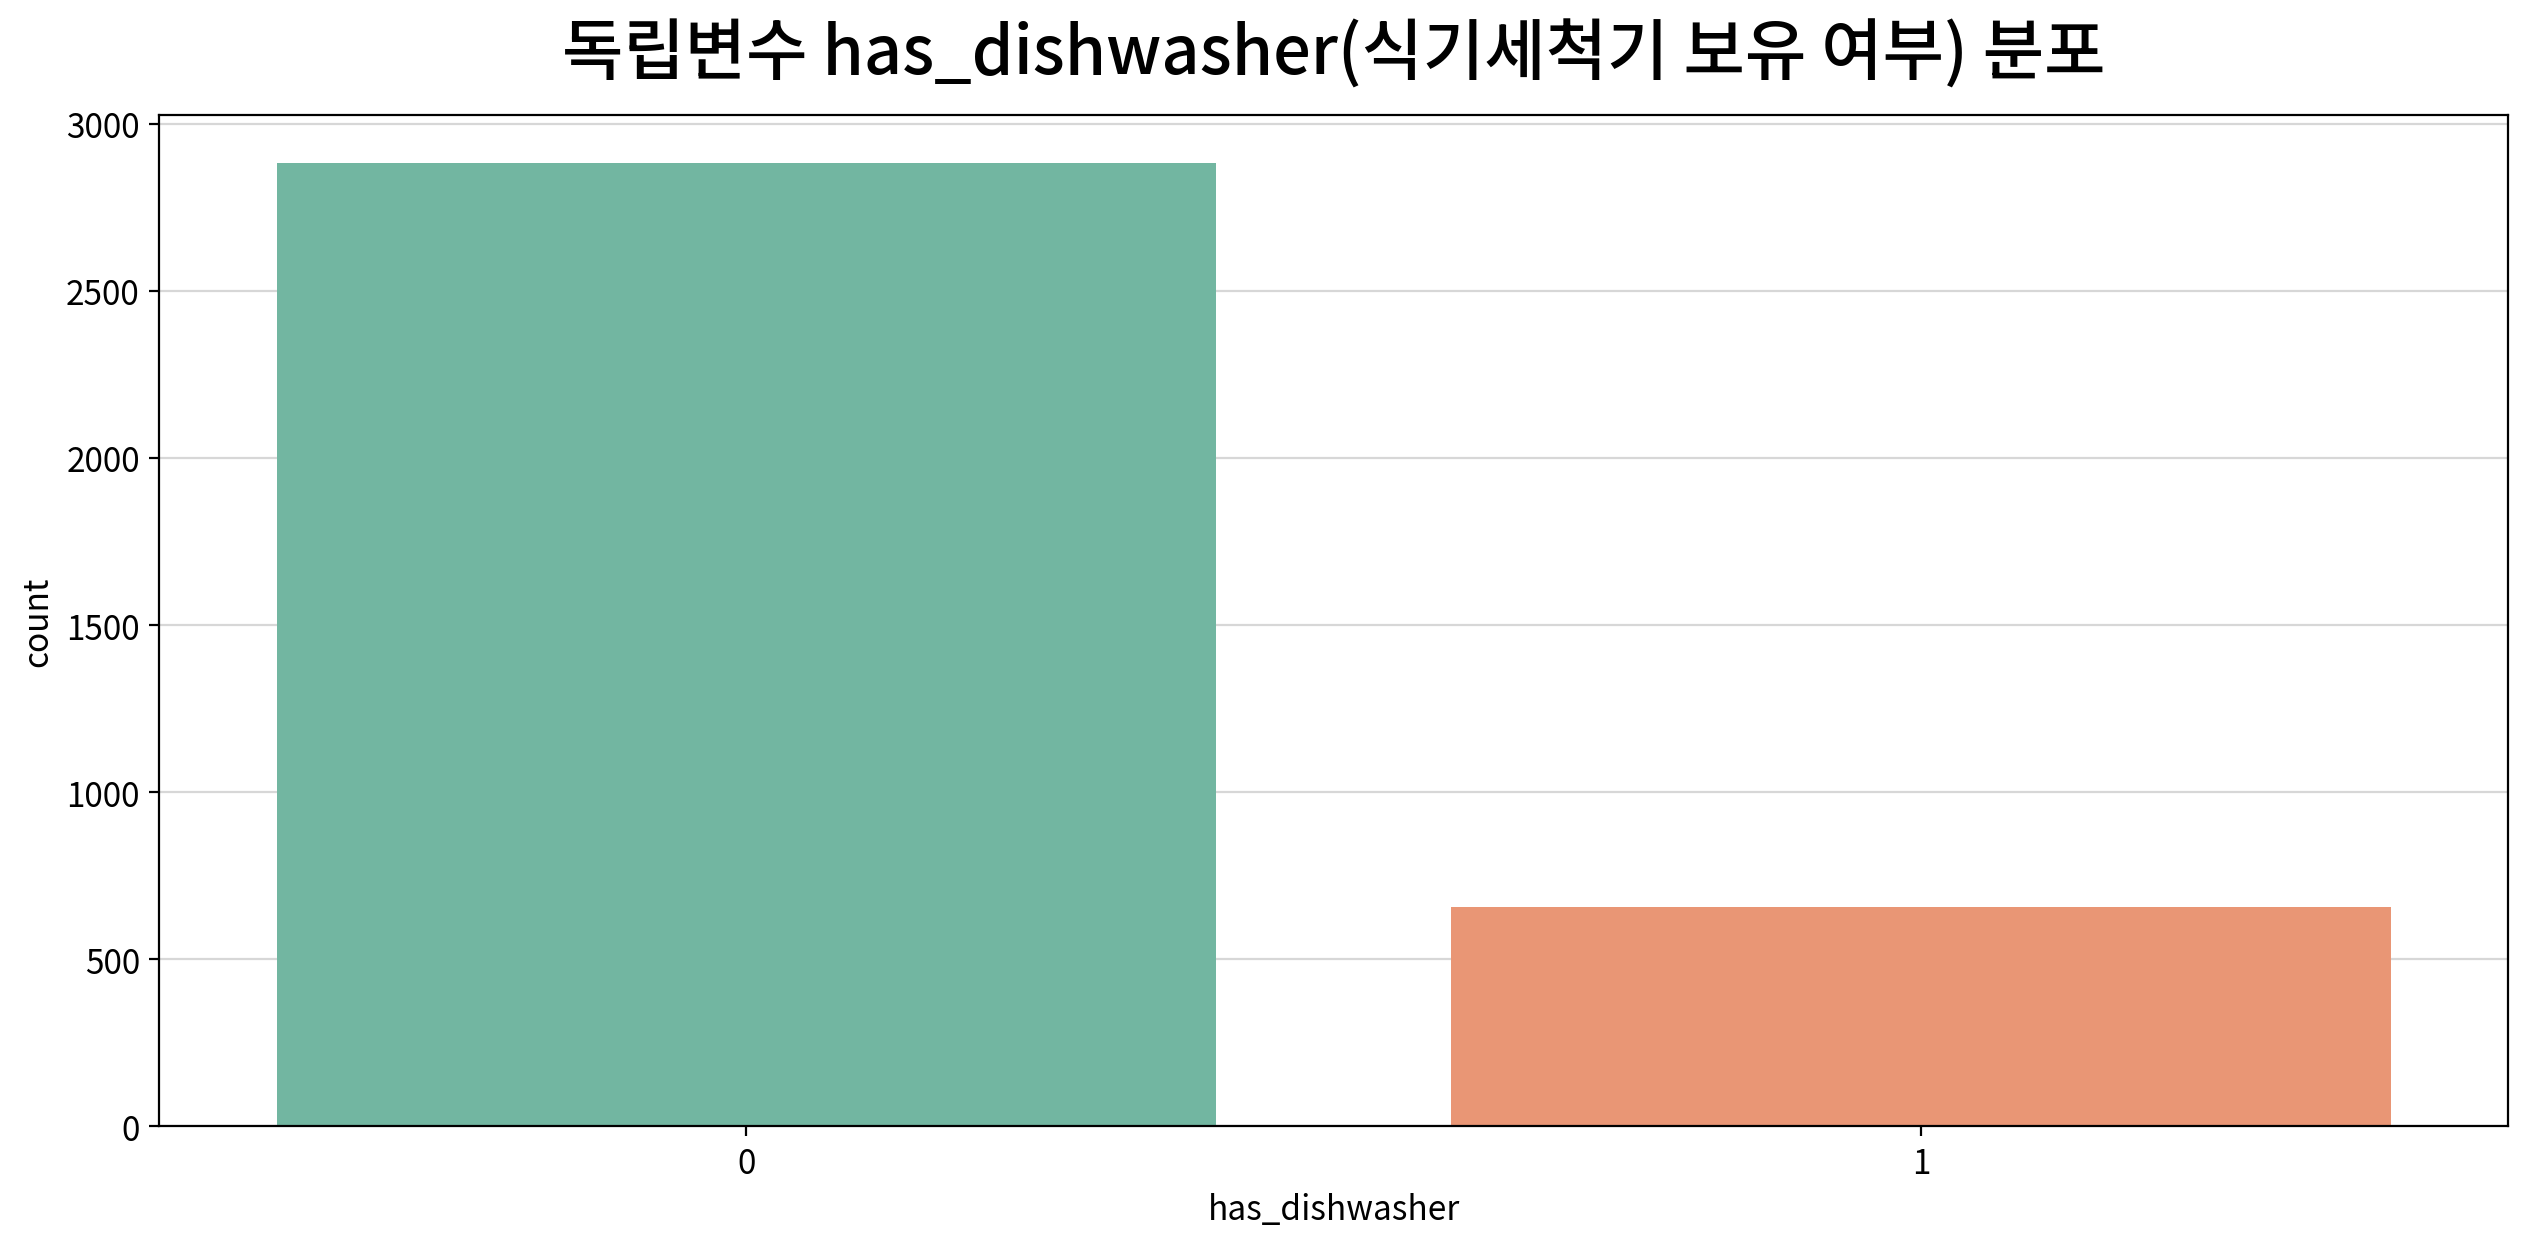

,count,unique,top,freq
has_dishwasher,3512,2,0,2860


,빈도,비율
has_dishwasher,,
0,2882,0.814
1,657,0.186


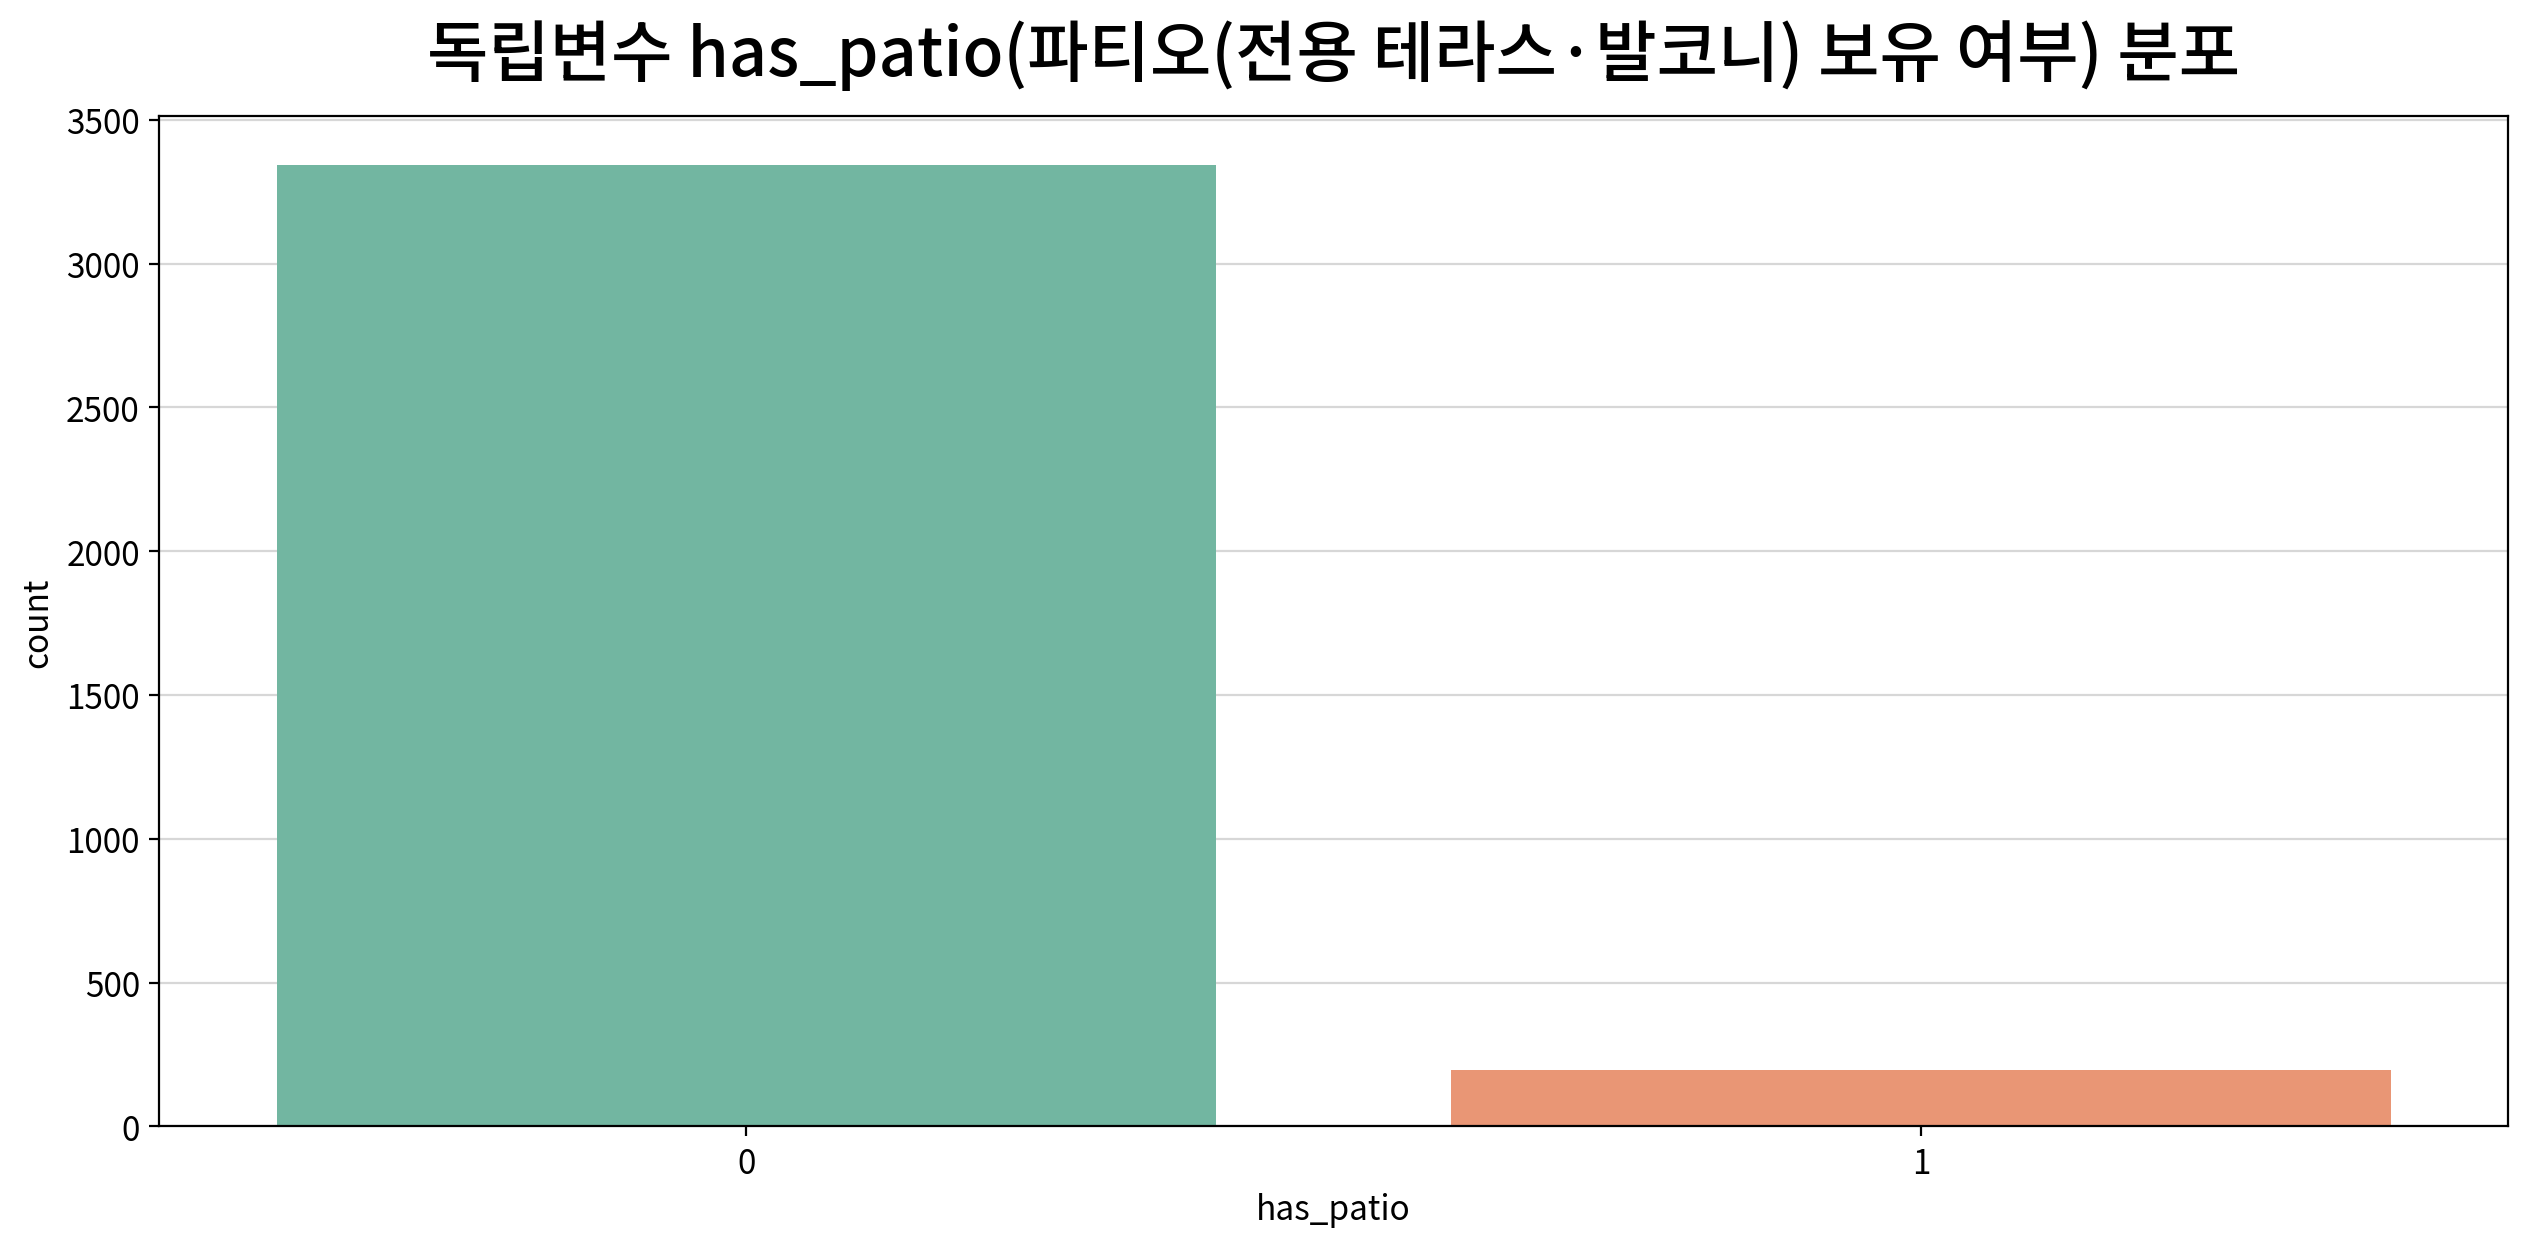

,count,unique,top,freq
has_patio,3512,2,0,3317


,빈도,비율
has_patio,,
0,3344,0.945
1,195,0.055


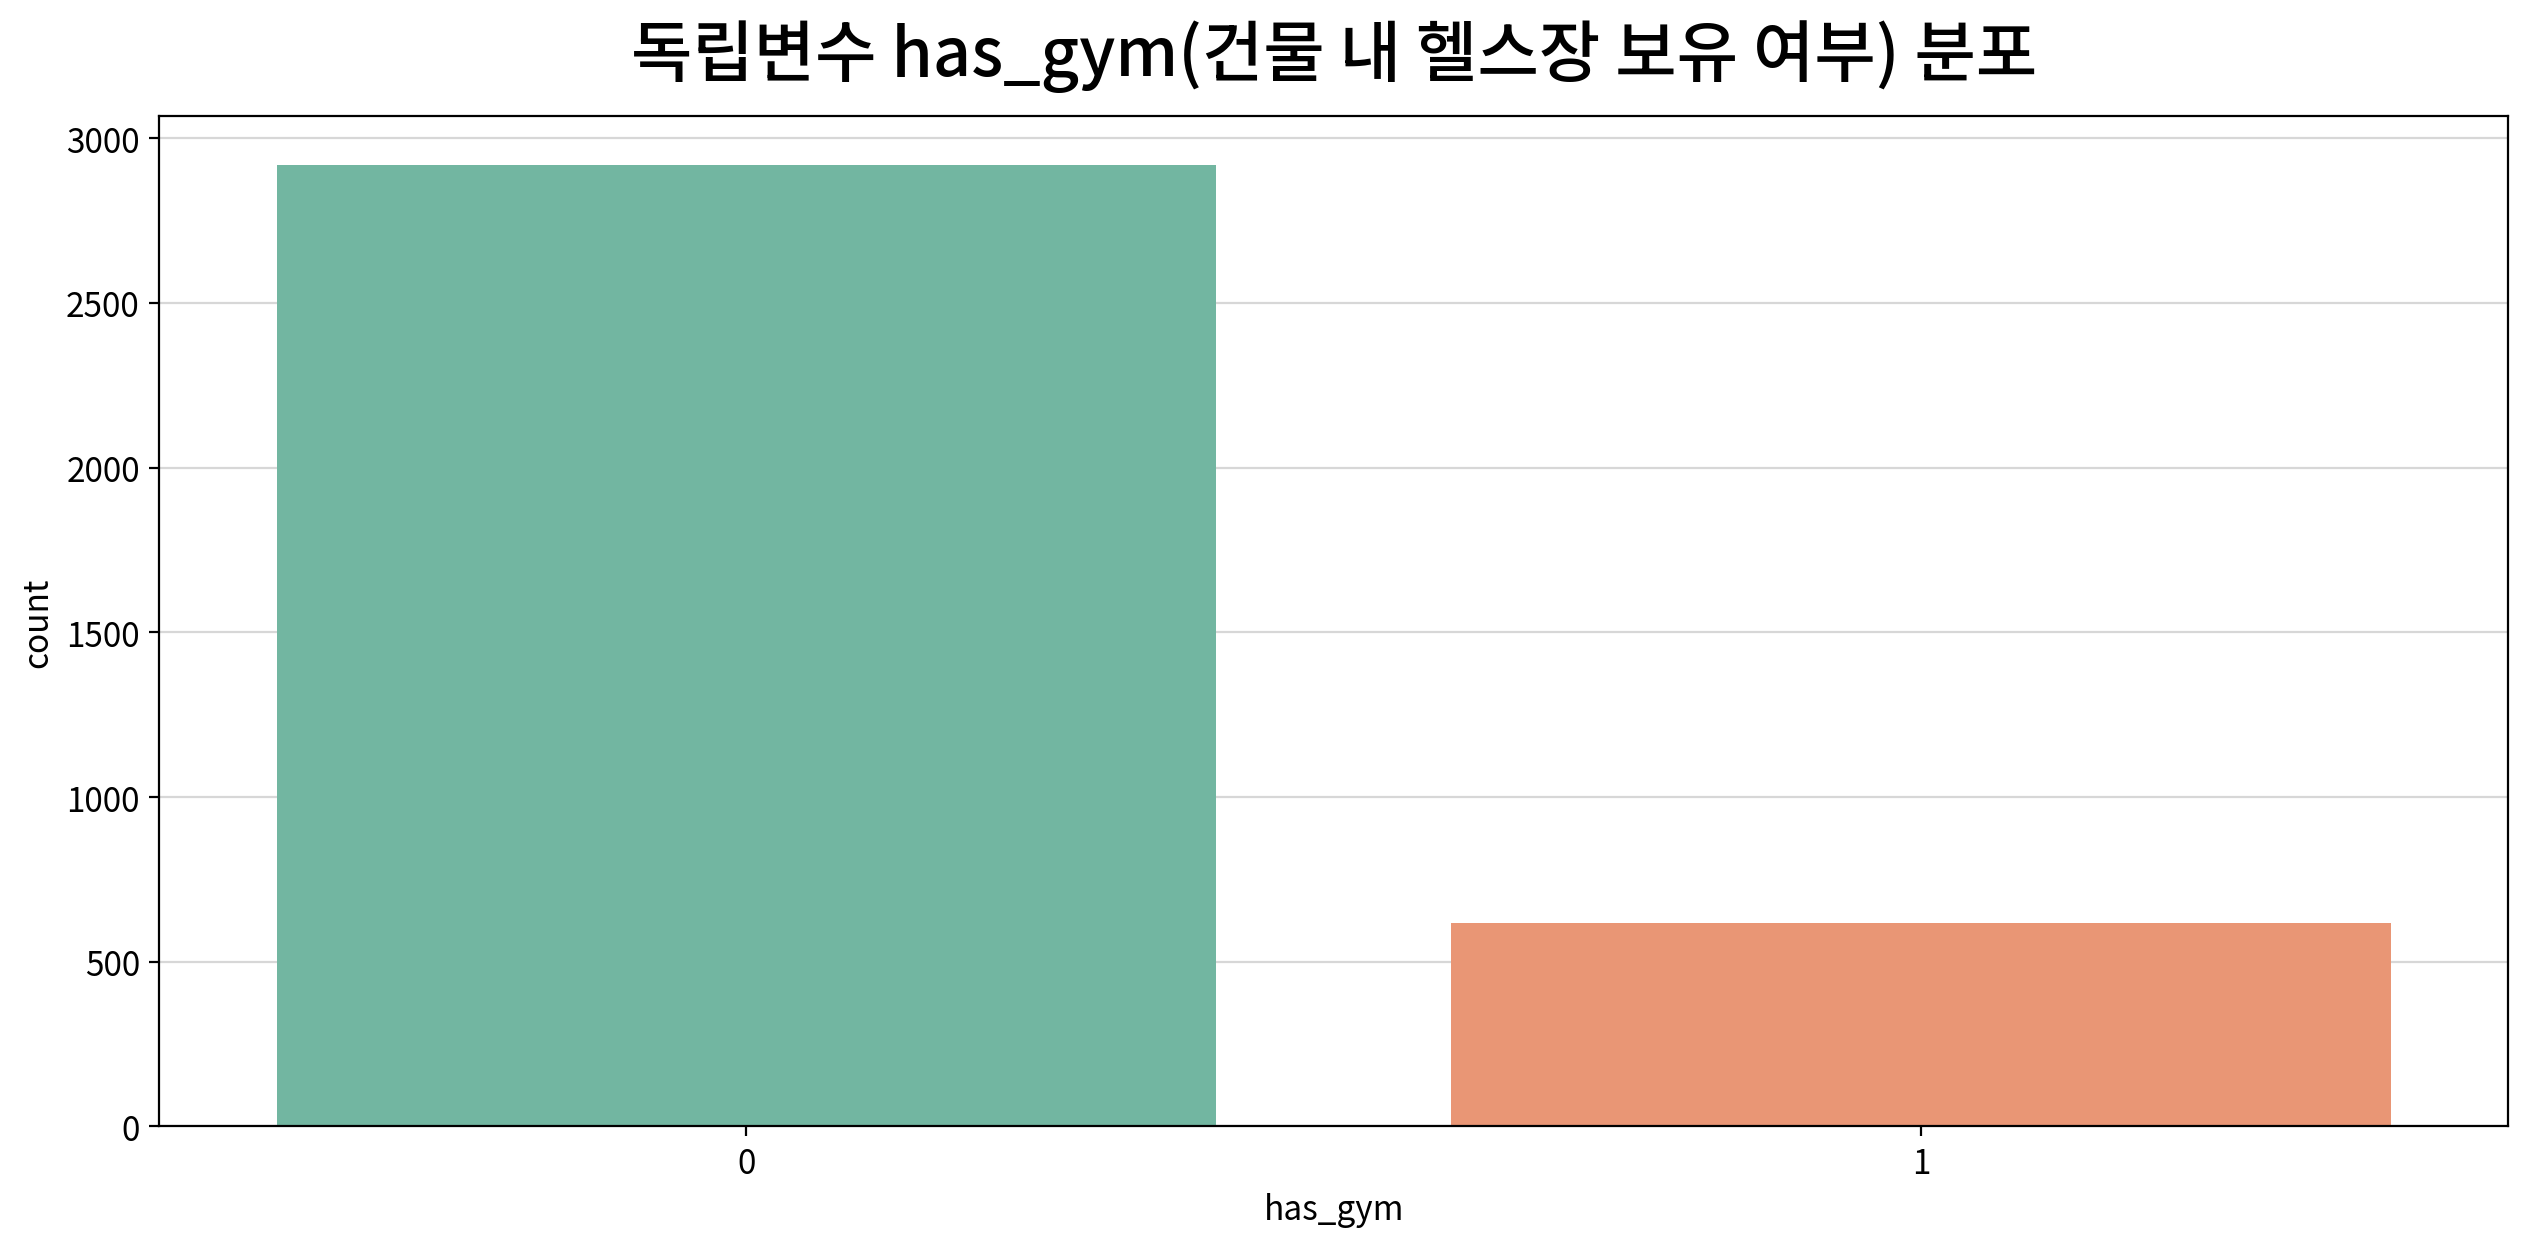

,count,unique,top,freq
has_gym,3512,2,0,2897


,빈도,비율
has_gym,,
0,2920,0.825
1,619,0.175


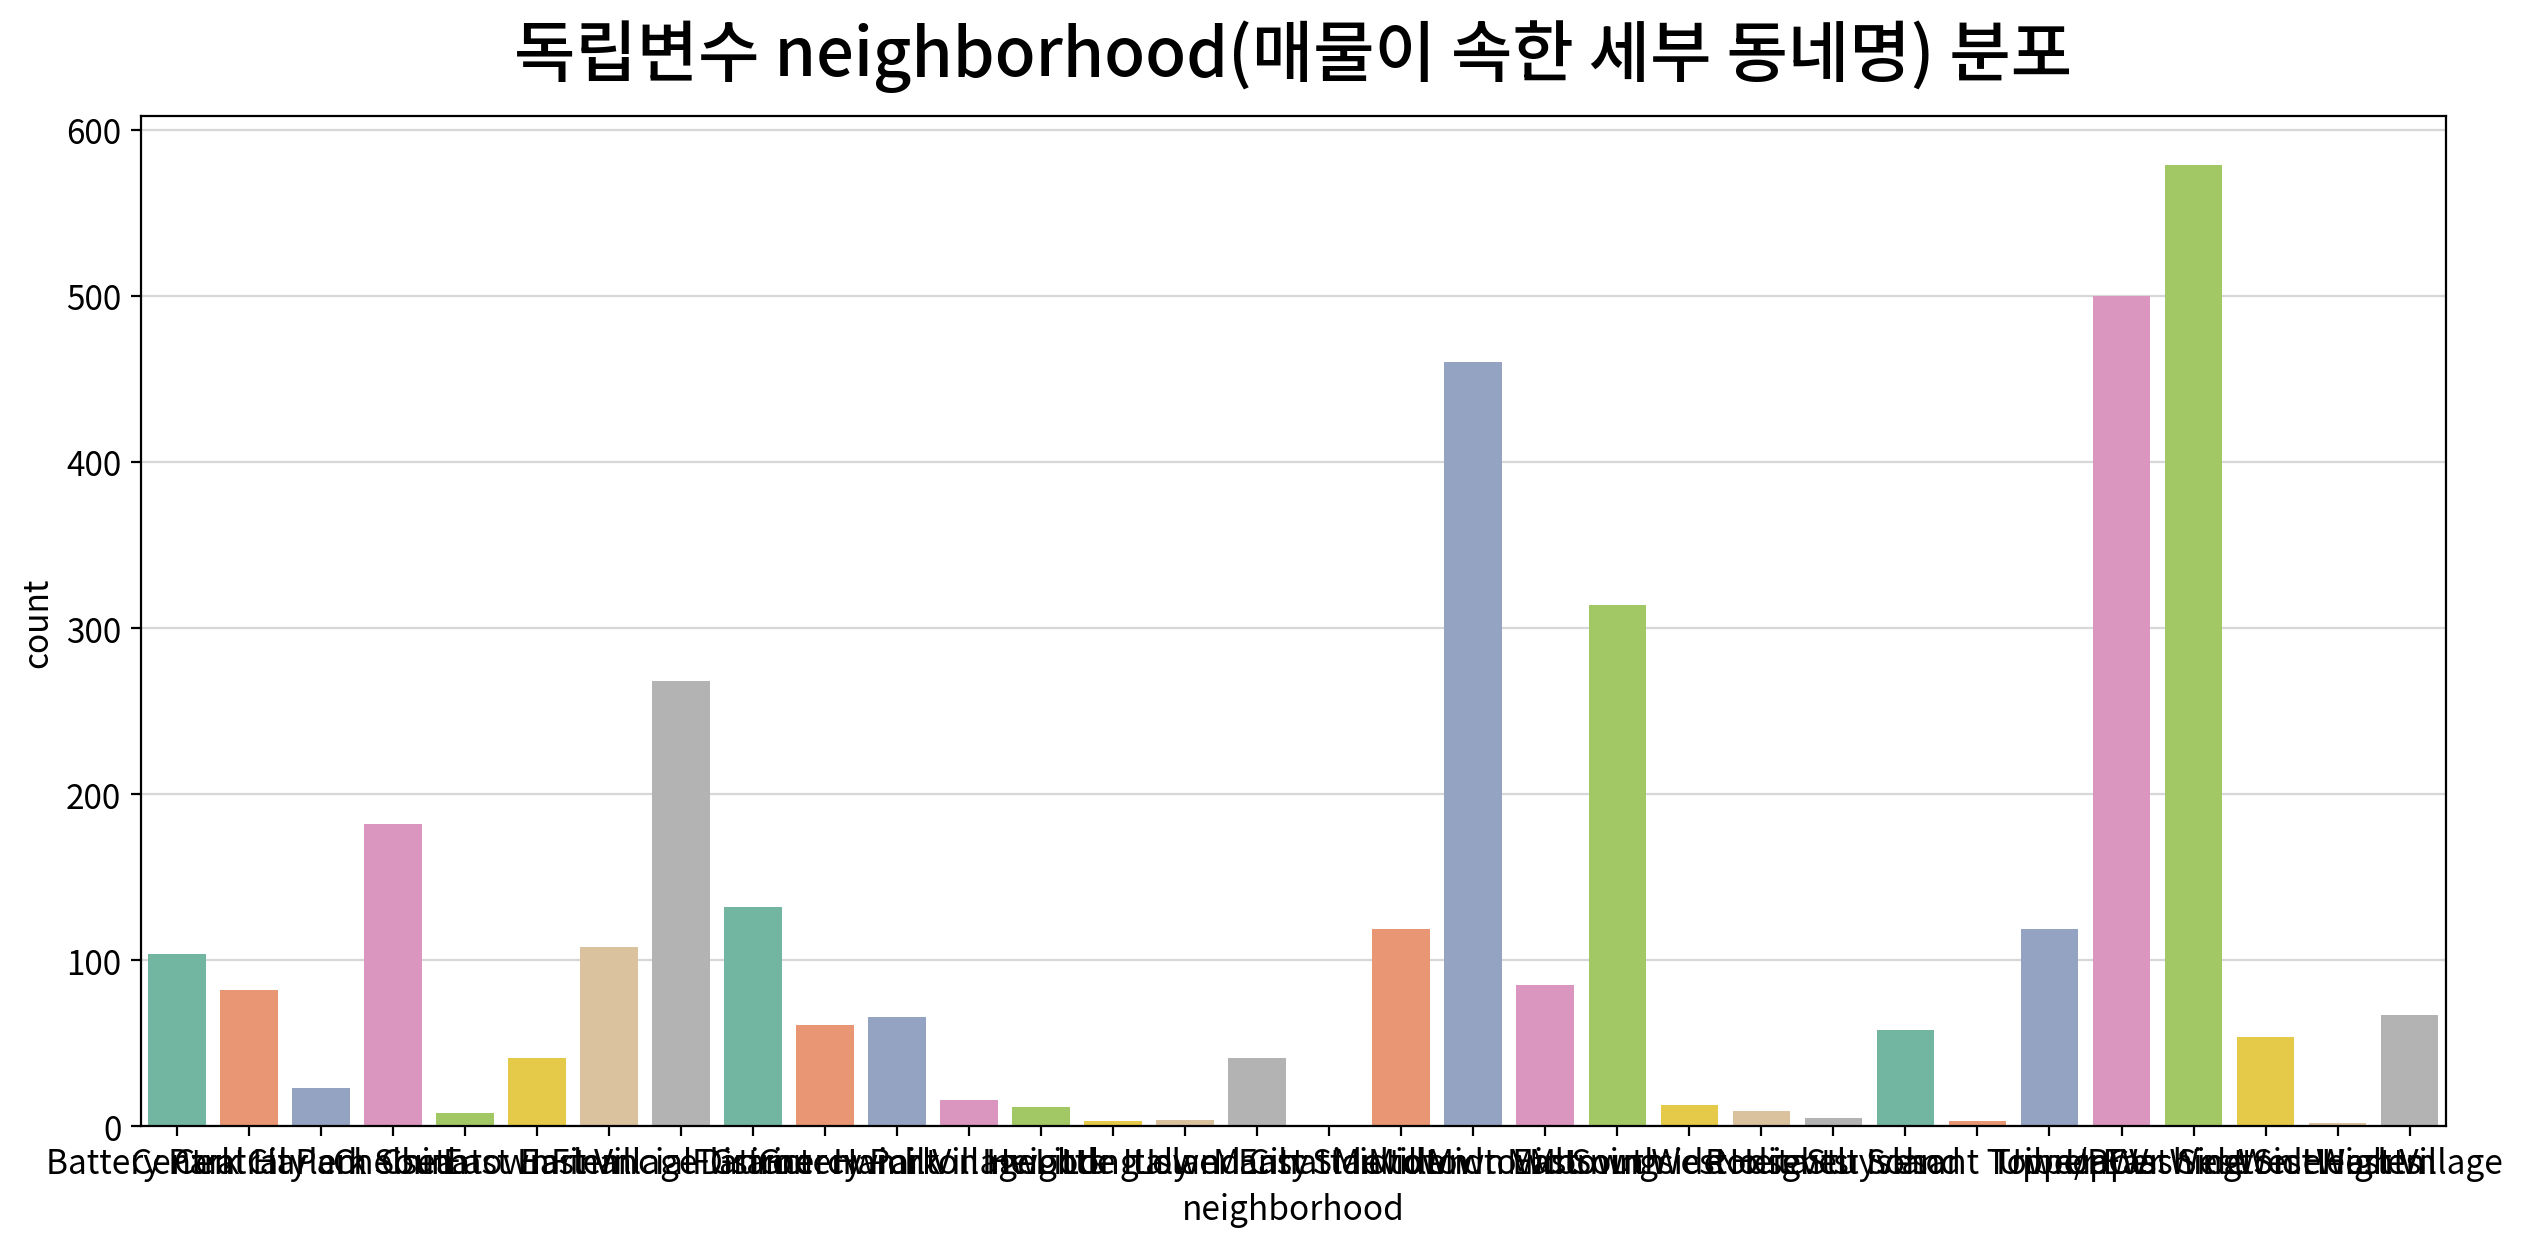

,count,unique,top,freq
neighborhood,3512,32,Upper West Side,577


,빈도,비율
neighborhood,,
Upper West Side,579,0.164
Upper East Side,500,0.141
Midtown East,460,0.130
Midtown West,314,0.089
Financial District,268,0.076
Chelsea,182,0.051
Flatiron,132,0.037
Midtown,119,0.034
Tribeca,119,0.034


In [20]:
for n in nominal_cols:
    # 범주형 분포는 카운트 플롯으로 처리한다.
    my_plot.countplot(data=df, x=n, hue=n, palette="Set2",
                      title=f"독립변수 {n}({column_means[n]}) 분포")

    # 범주형 기술통계량
    display(cat_desc[[n]].T)

    # 추가적으로 빈도표 생성
    freq = df[n].value_counts().rename("빈도").to_frame()
    freq["비율"] = df[n].value_counts(normalize=True)
    display(freq)

#### ▶ bedrooms → rent

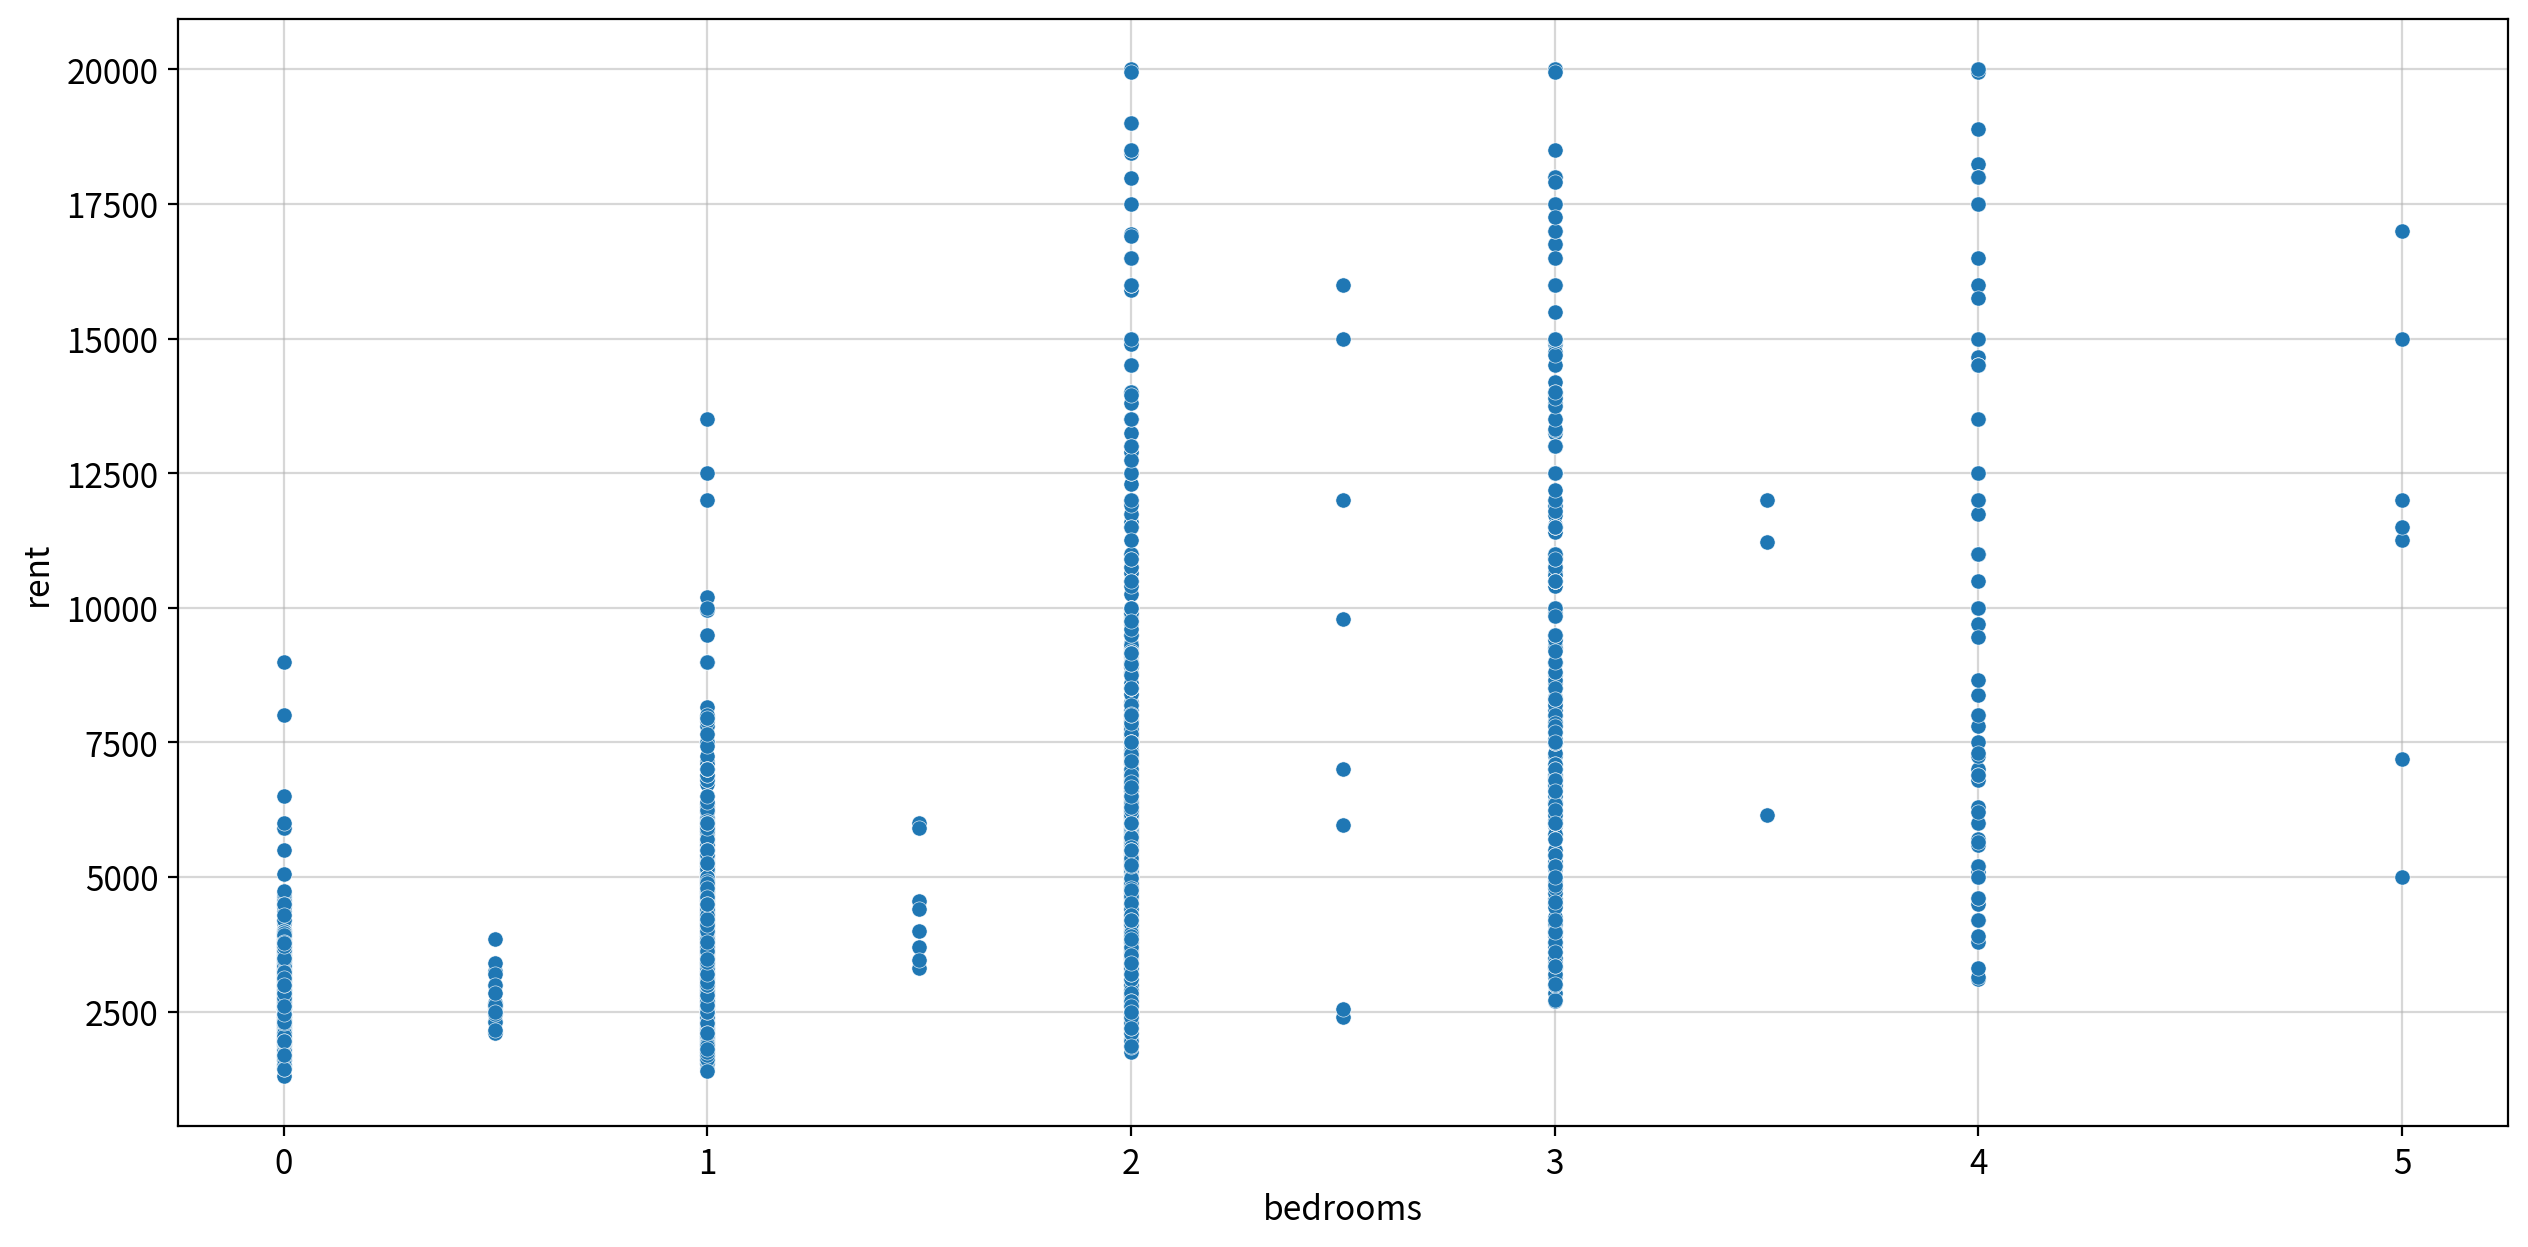

,,method,coef,p-value,strength,significant,normality_x,normality_y,linearity,influential_outlier,high_skew
x,y,,,,,,,,,,
bedrooms,rent,Spearman,0.678,0.000,Moderate,True,False,False,False,False,True


#### ▶ bathrooms → rent

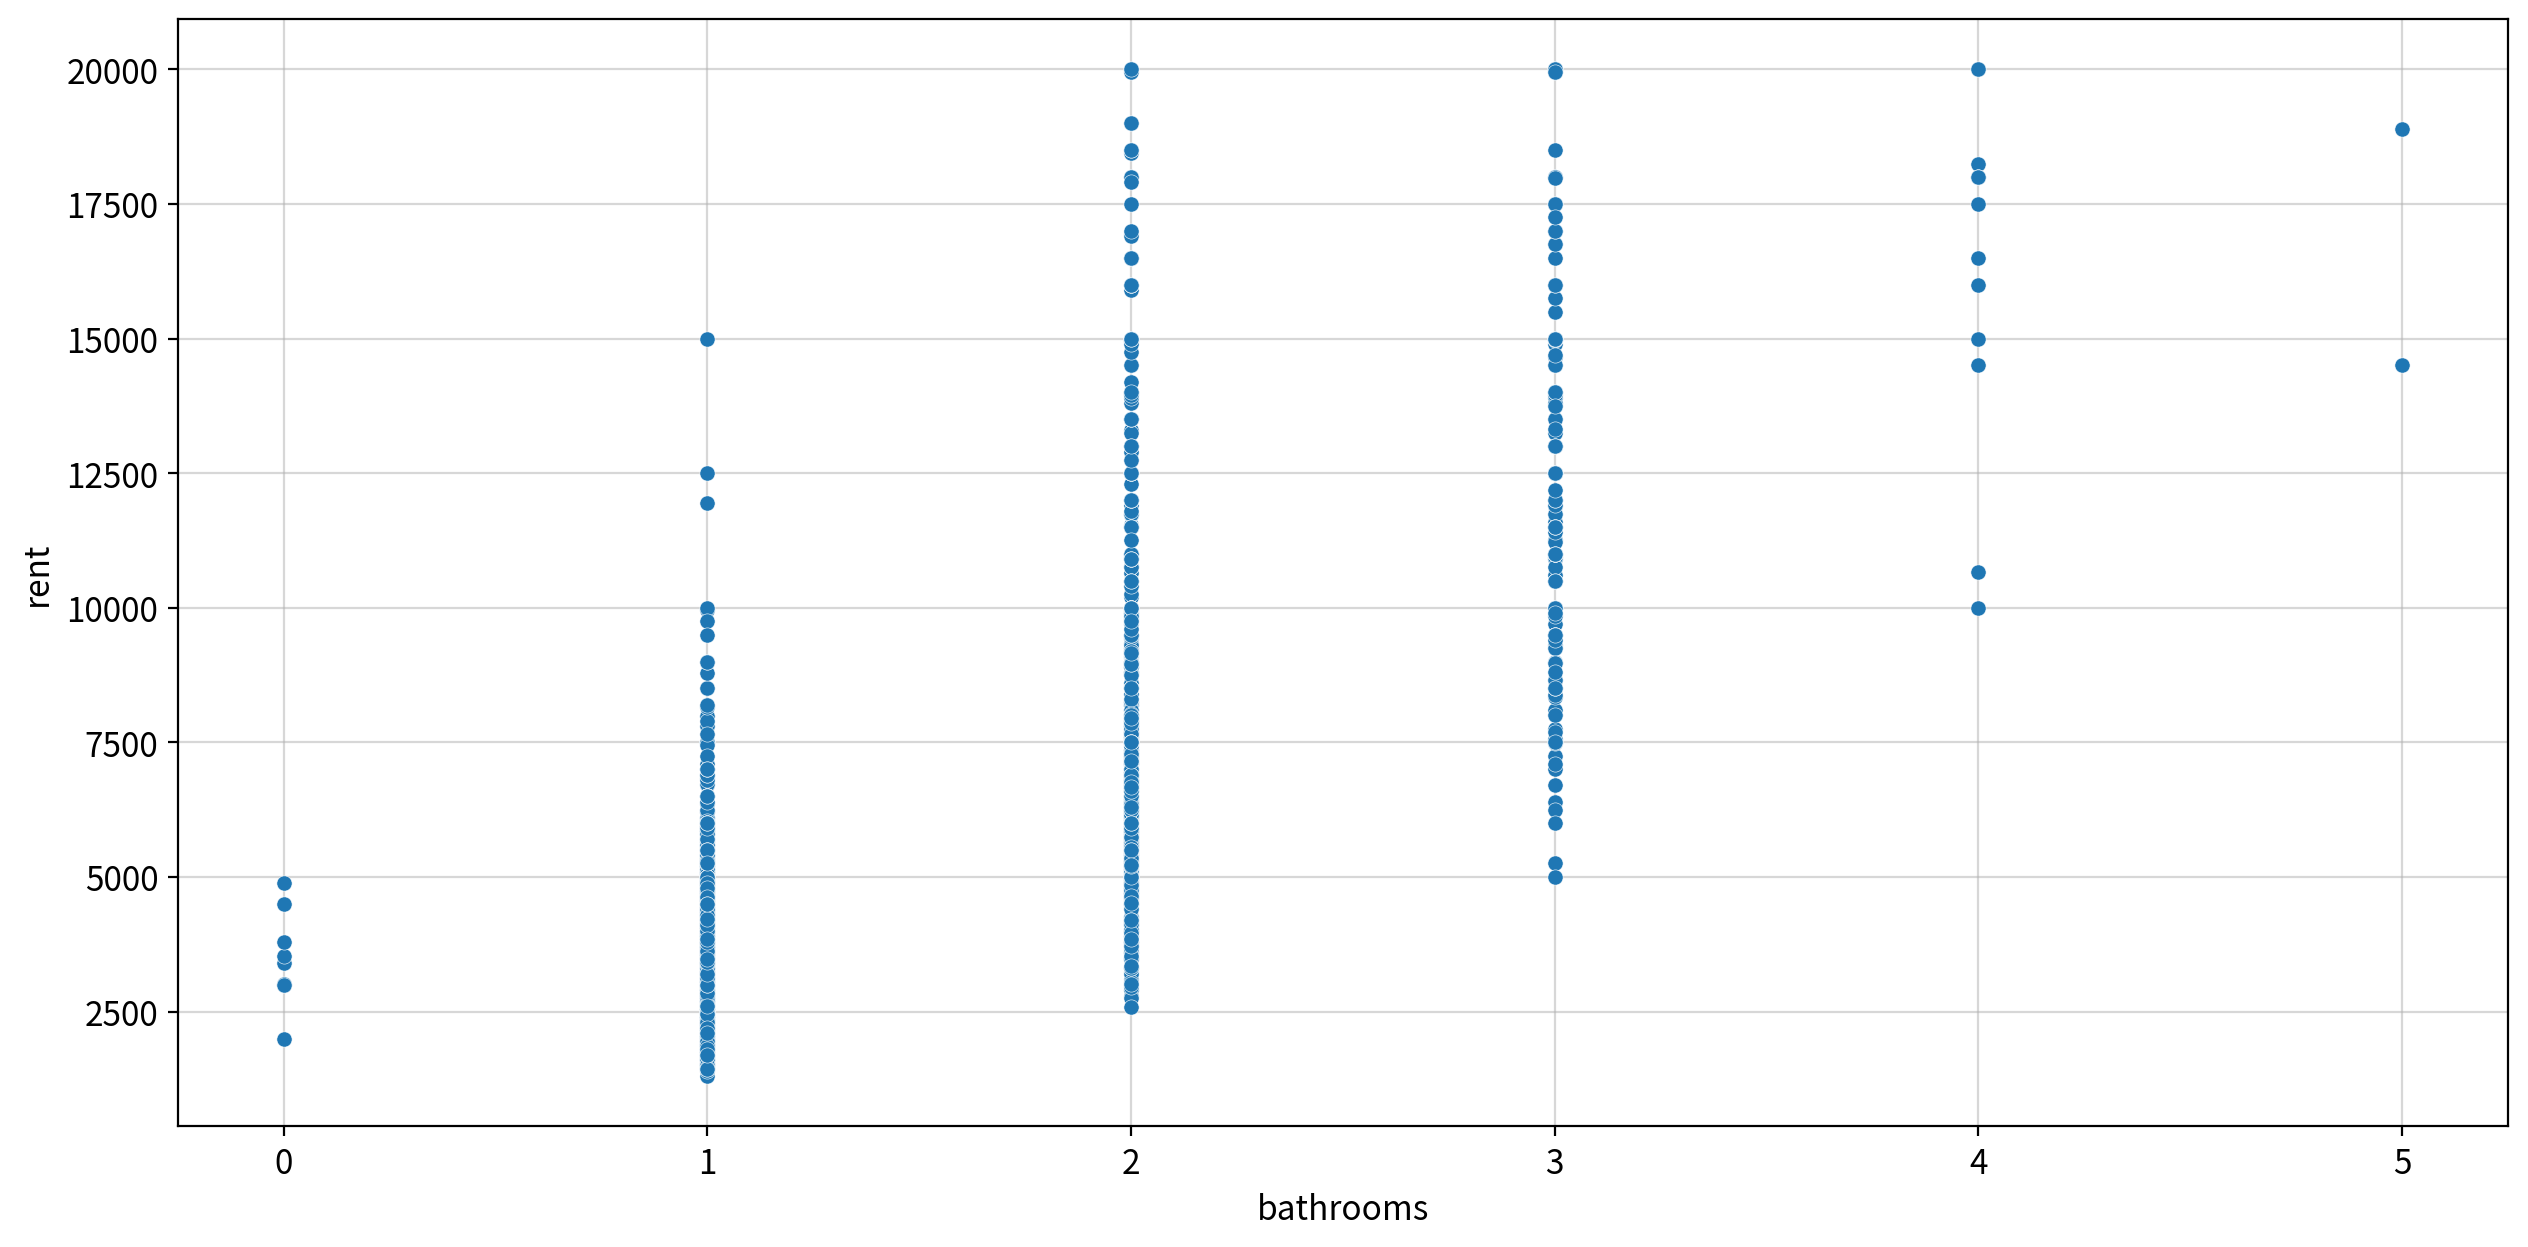

,,method,coef,p-value,strength,significant,normality_x,normality_y,linearity,influential_outlier,high_skew
x,y,,,,,,,,,,
bathrooms,rent,Spearman,0.722,0.000,Strong,True,False,False,False,False,True


#### ▶ size_sqft → rent

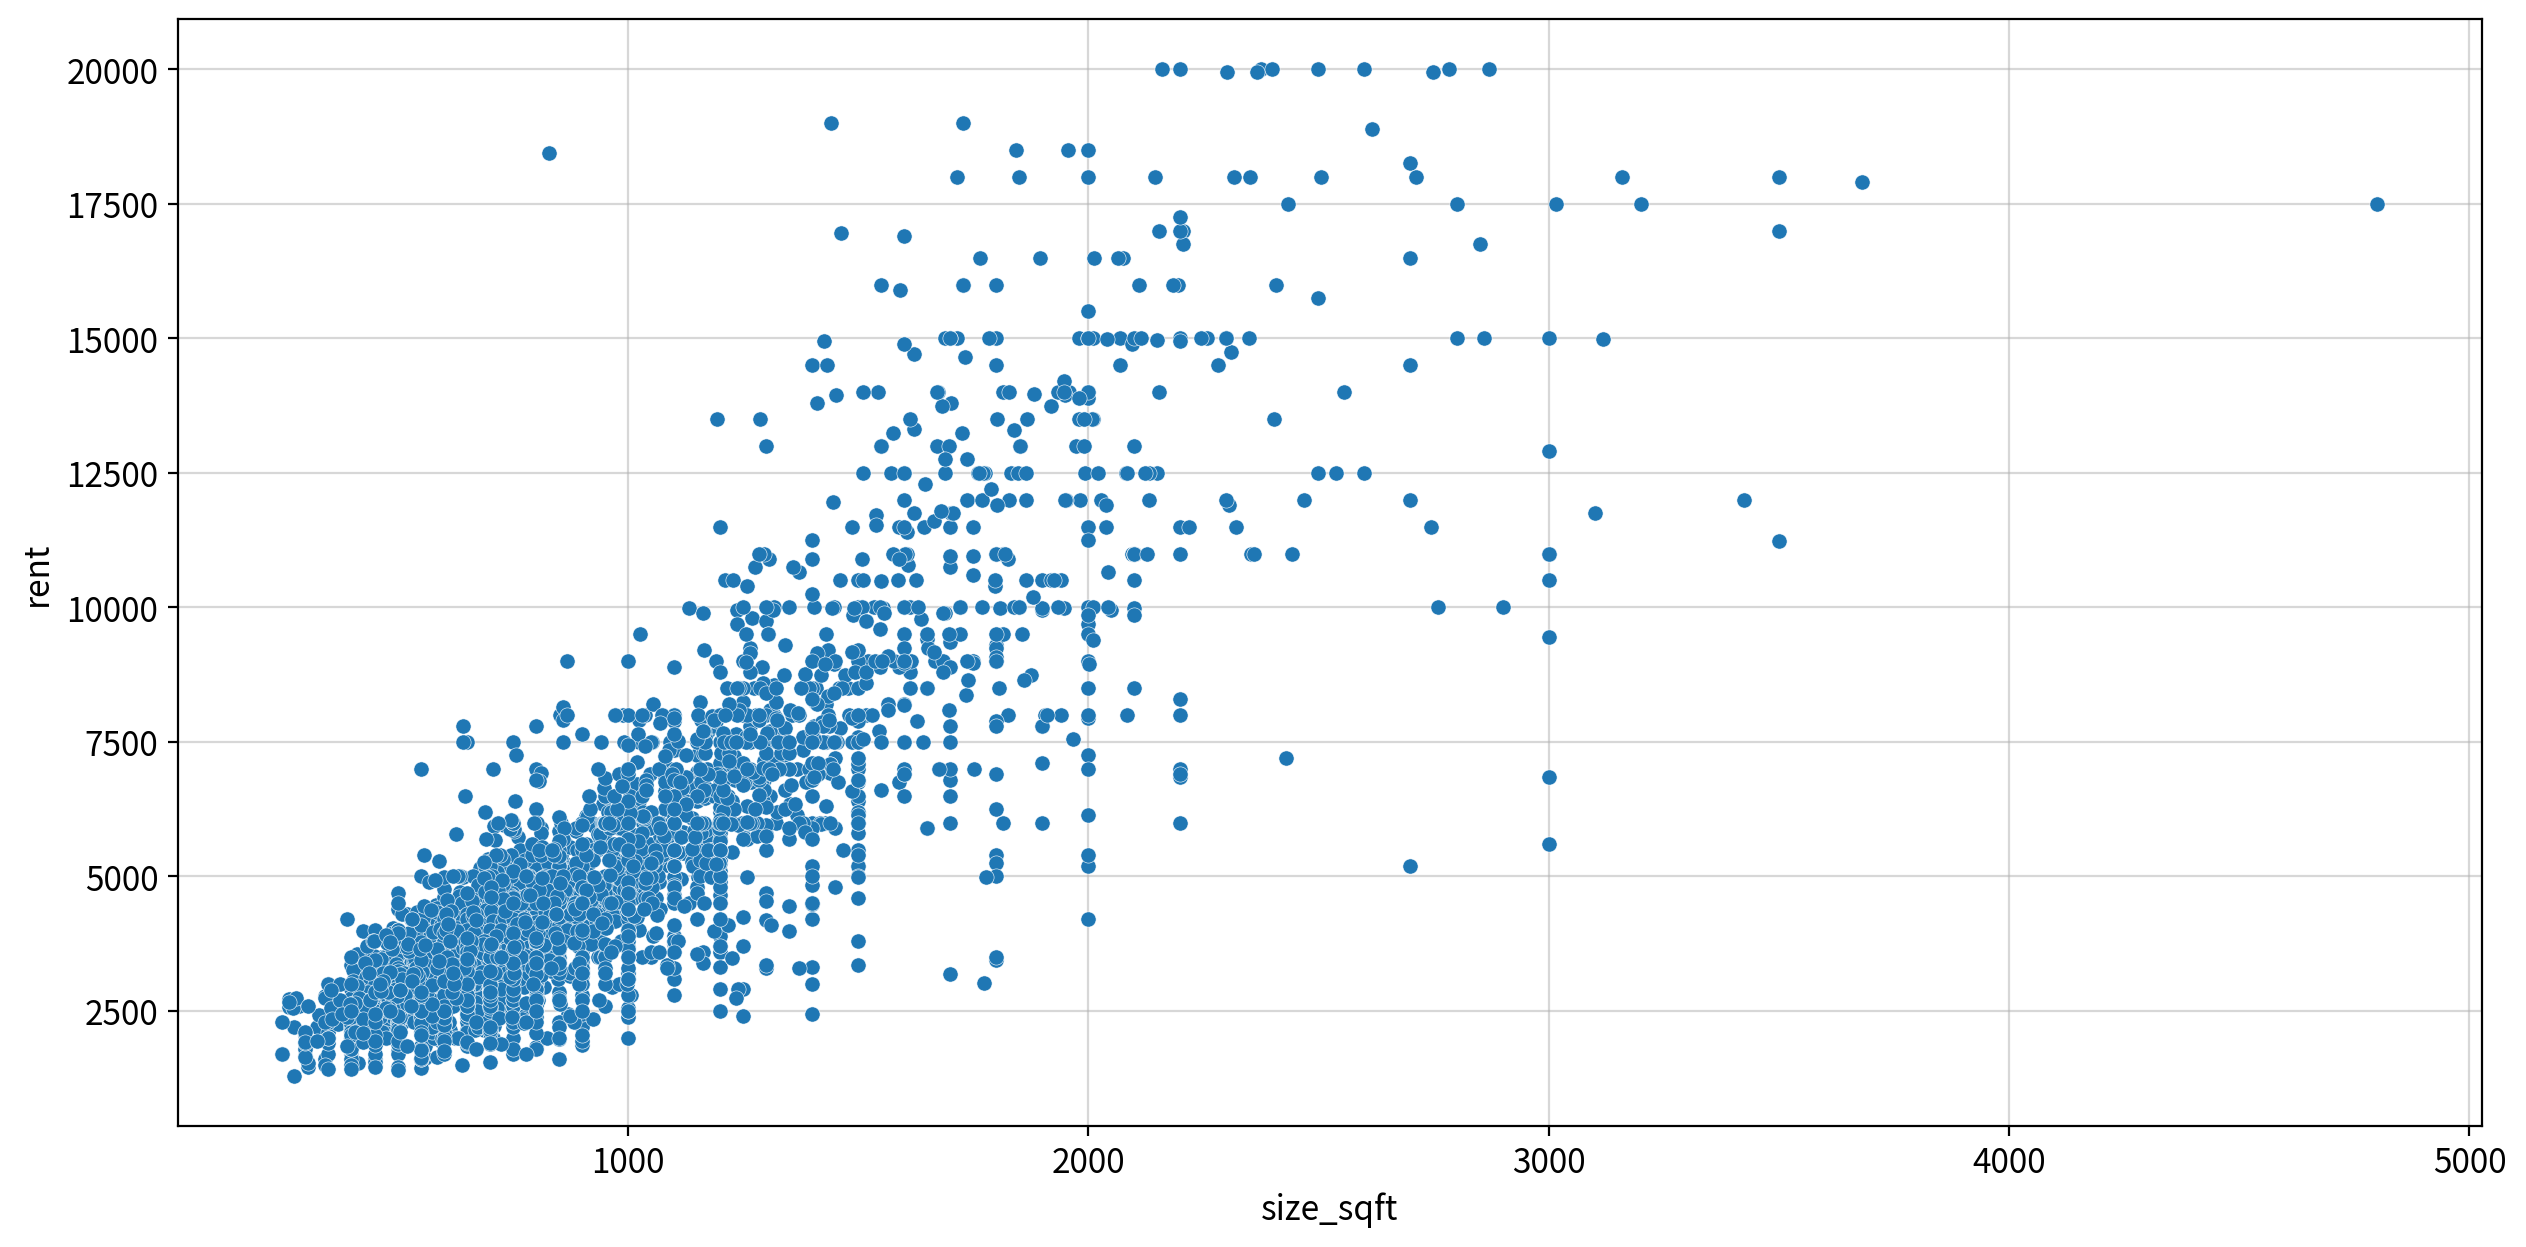

,,method,coef,p-value,strength,significant,normality_x,normality_y,linearity,influential_outlier,high_skew
x,y,,,,,,,,,,
size_sqft,rent,Spearman,0.837,0.000,Strong,True,False,False,False,False,True


#### ▶ min_to_subway → rent

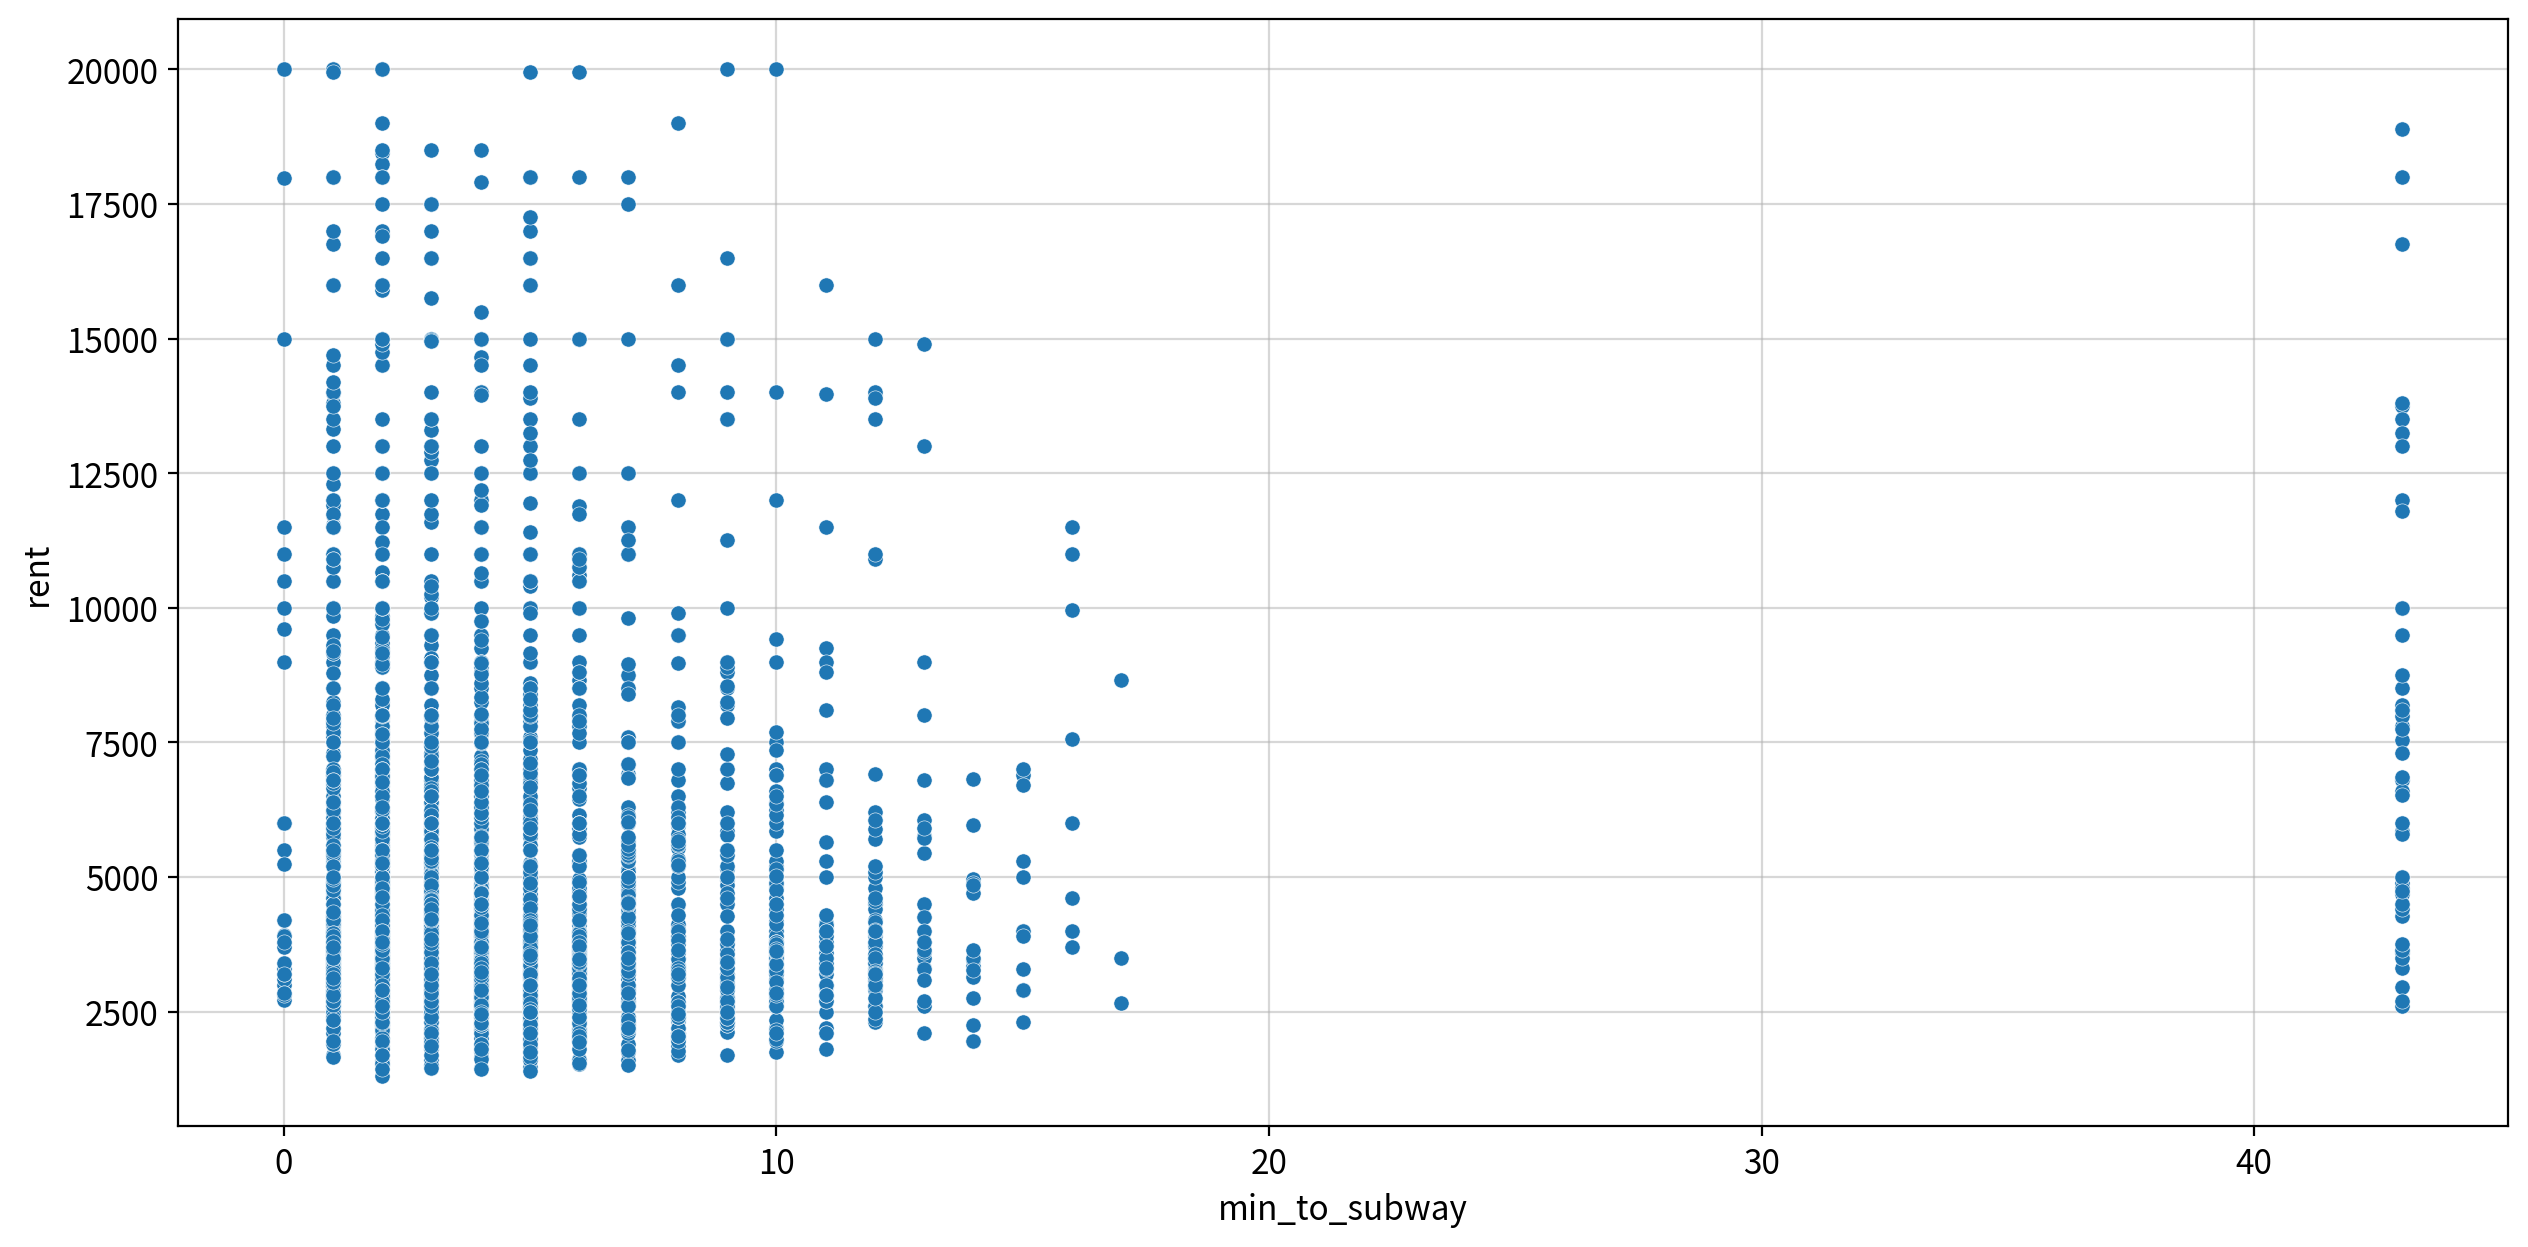

,,method,coef,p-value,strength,significant,normality_x,normality_y,linearity,influential_outlier,high_skew
x,y,,,,,,,,,,
min_to_subway,rent,Spearman,-0.083,0.000,Weak,True,False,False,False,True,True


#### ▶ floor → rent

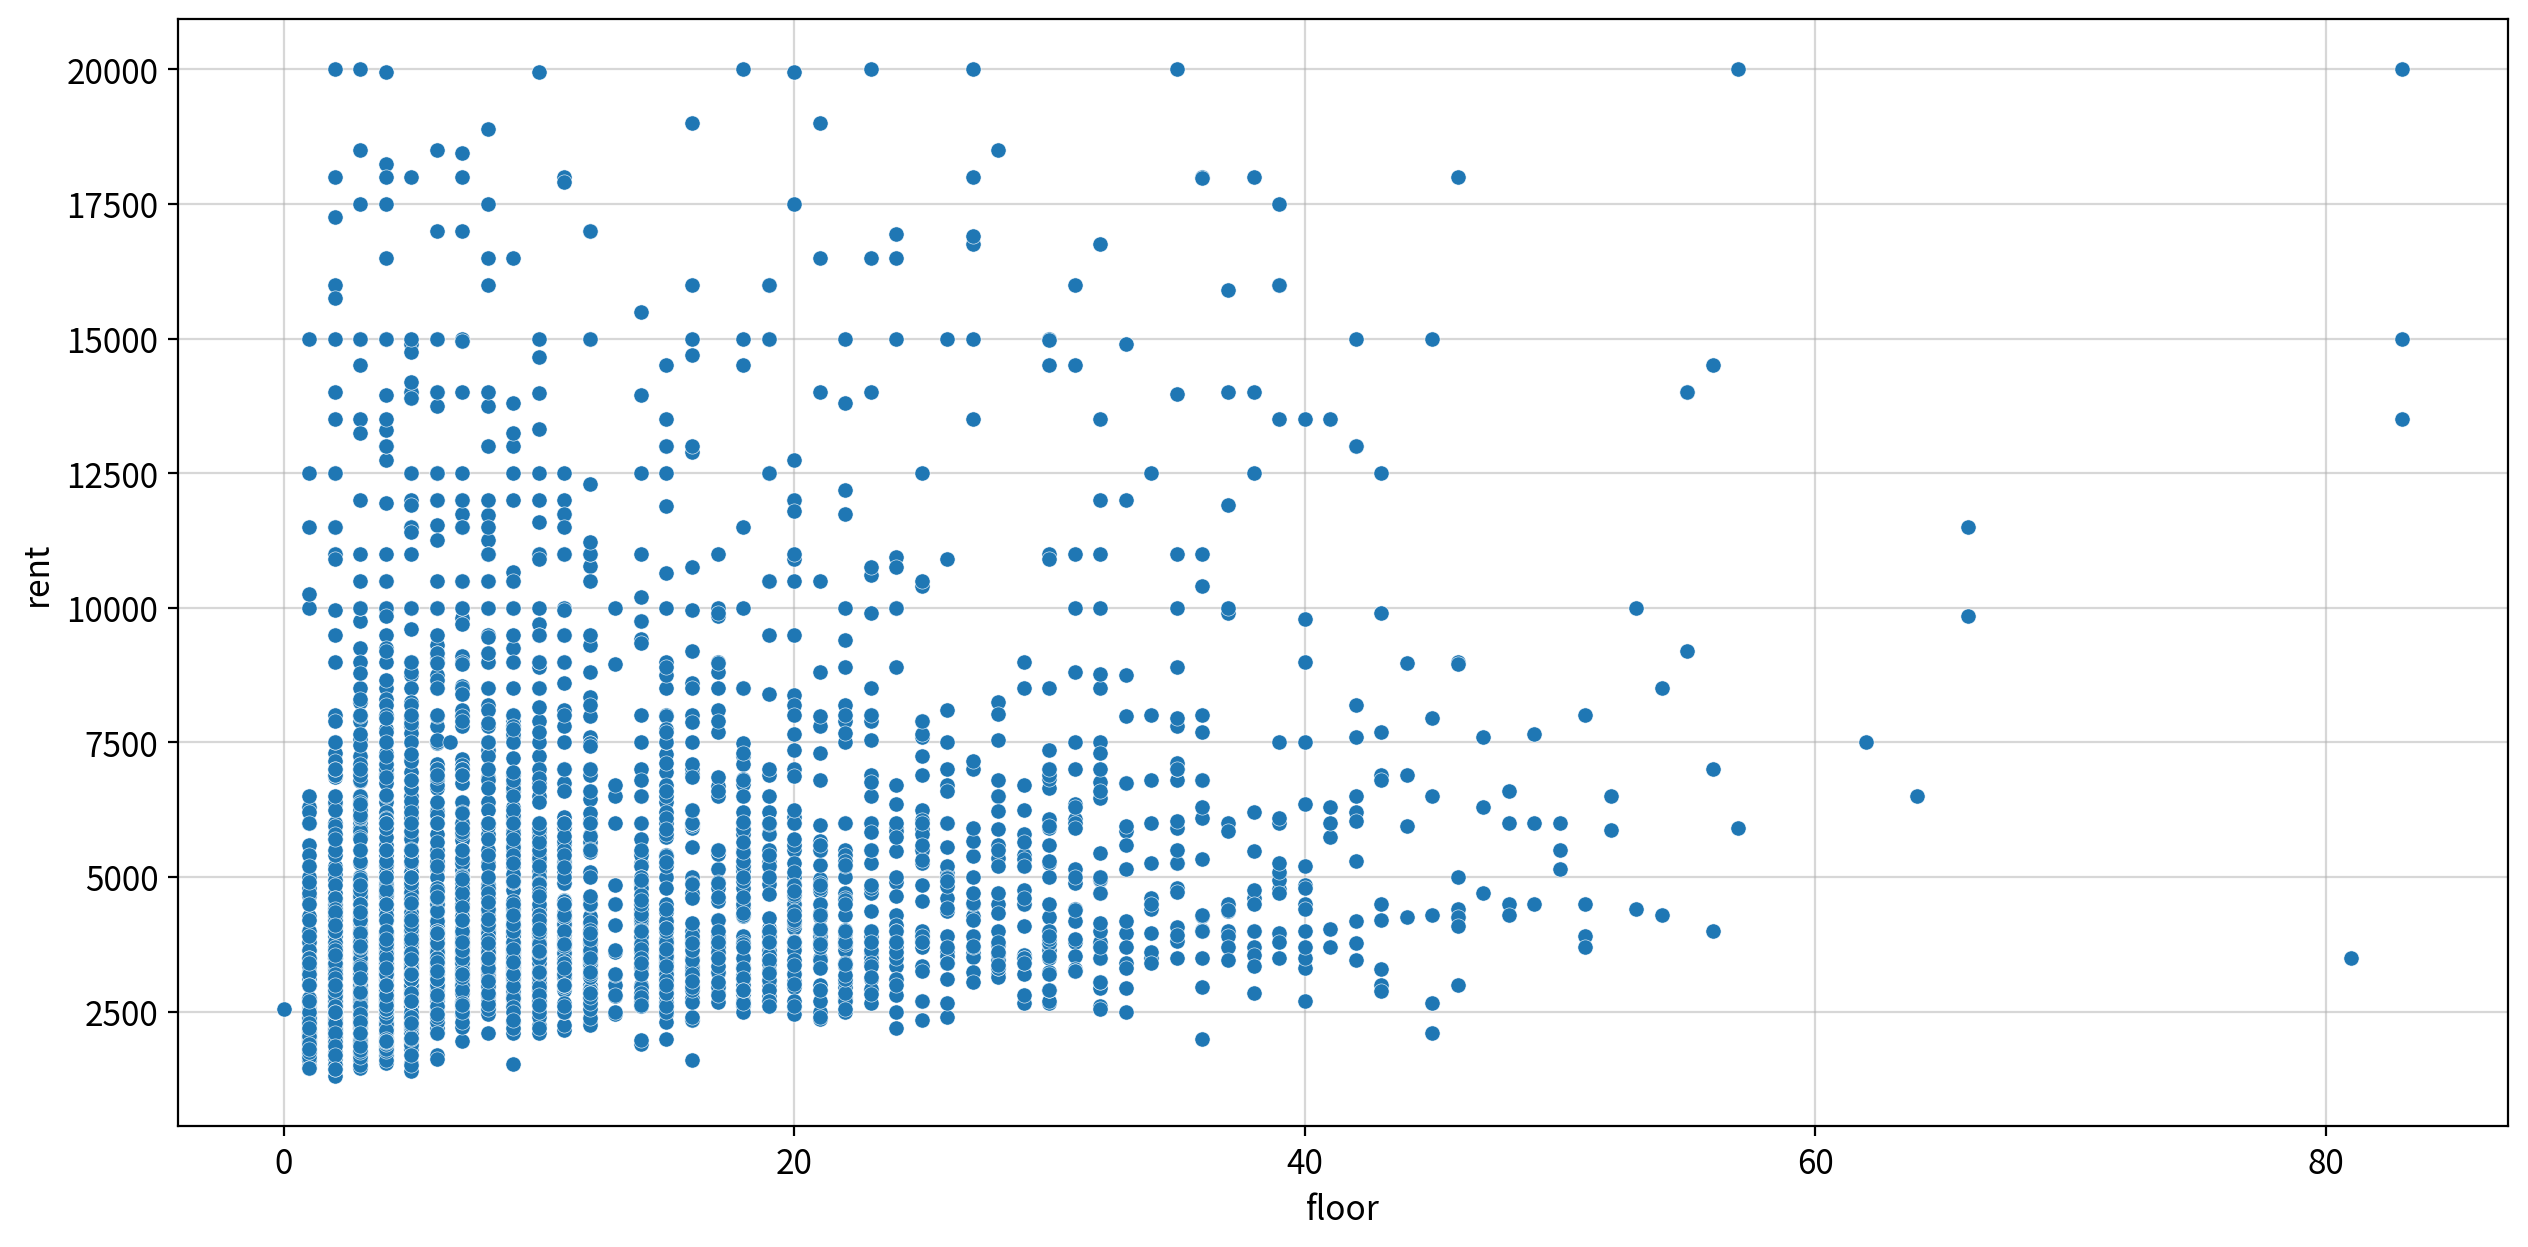

,,method,coef,p-value,strength,significant,normality_x,normality_y,linearity,influential_outlier,high_skew
x,y,,,,,,,,,,
floor,rent,Spearman,0.303,0.000,Moderate,True,False,False,True,False,True


#### ▶ building_age_yrs → rent

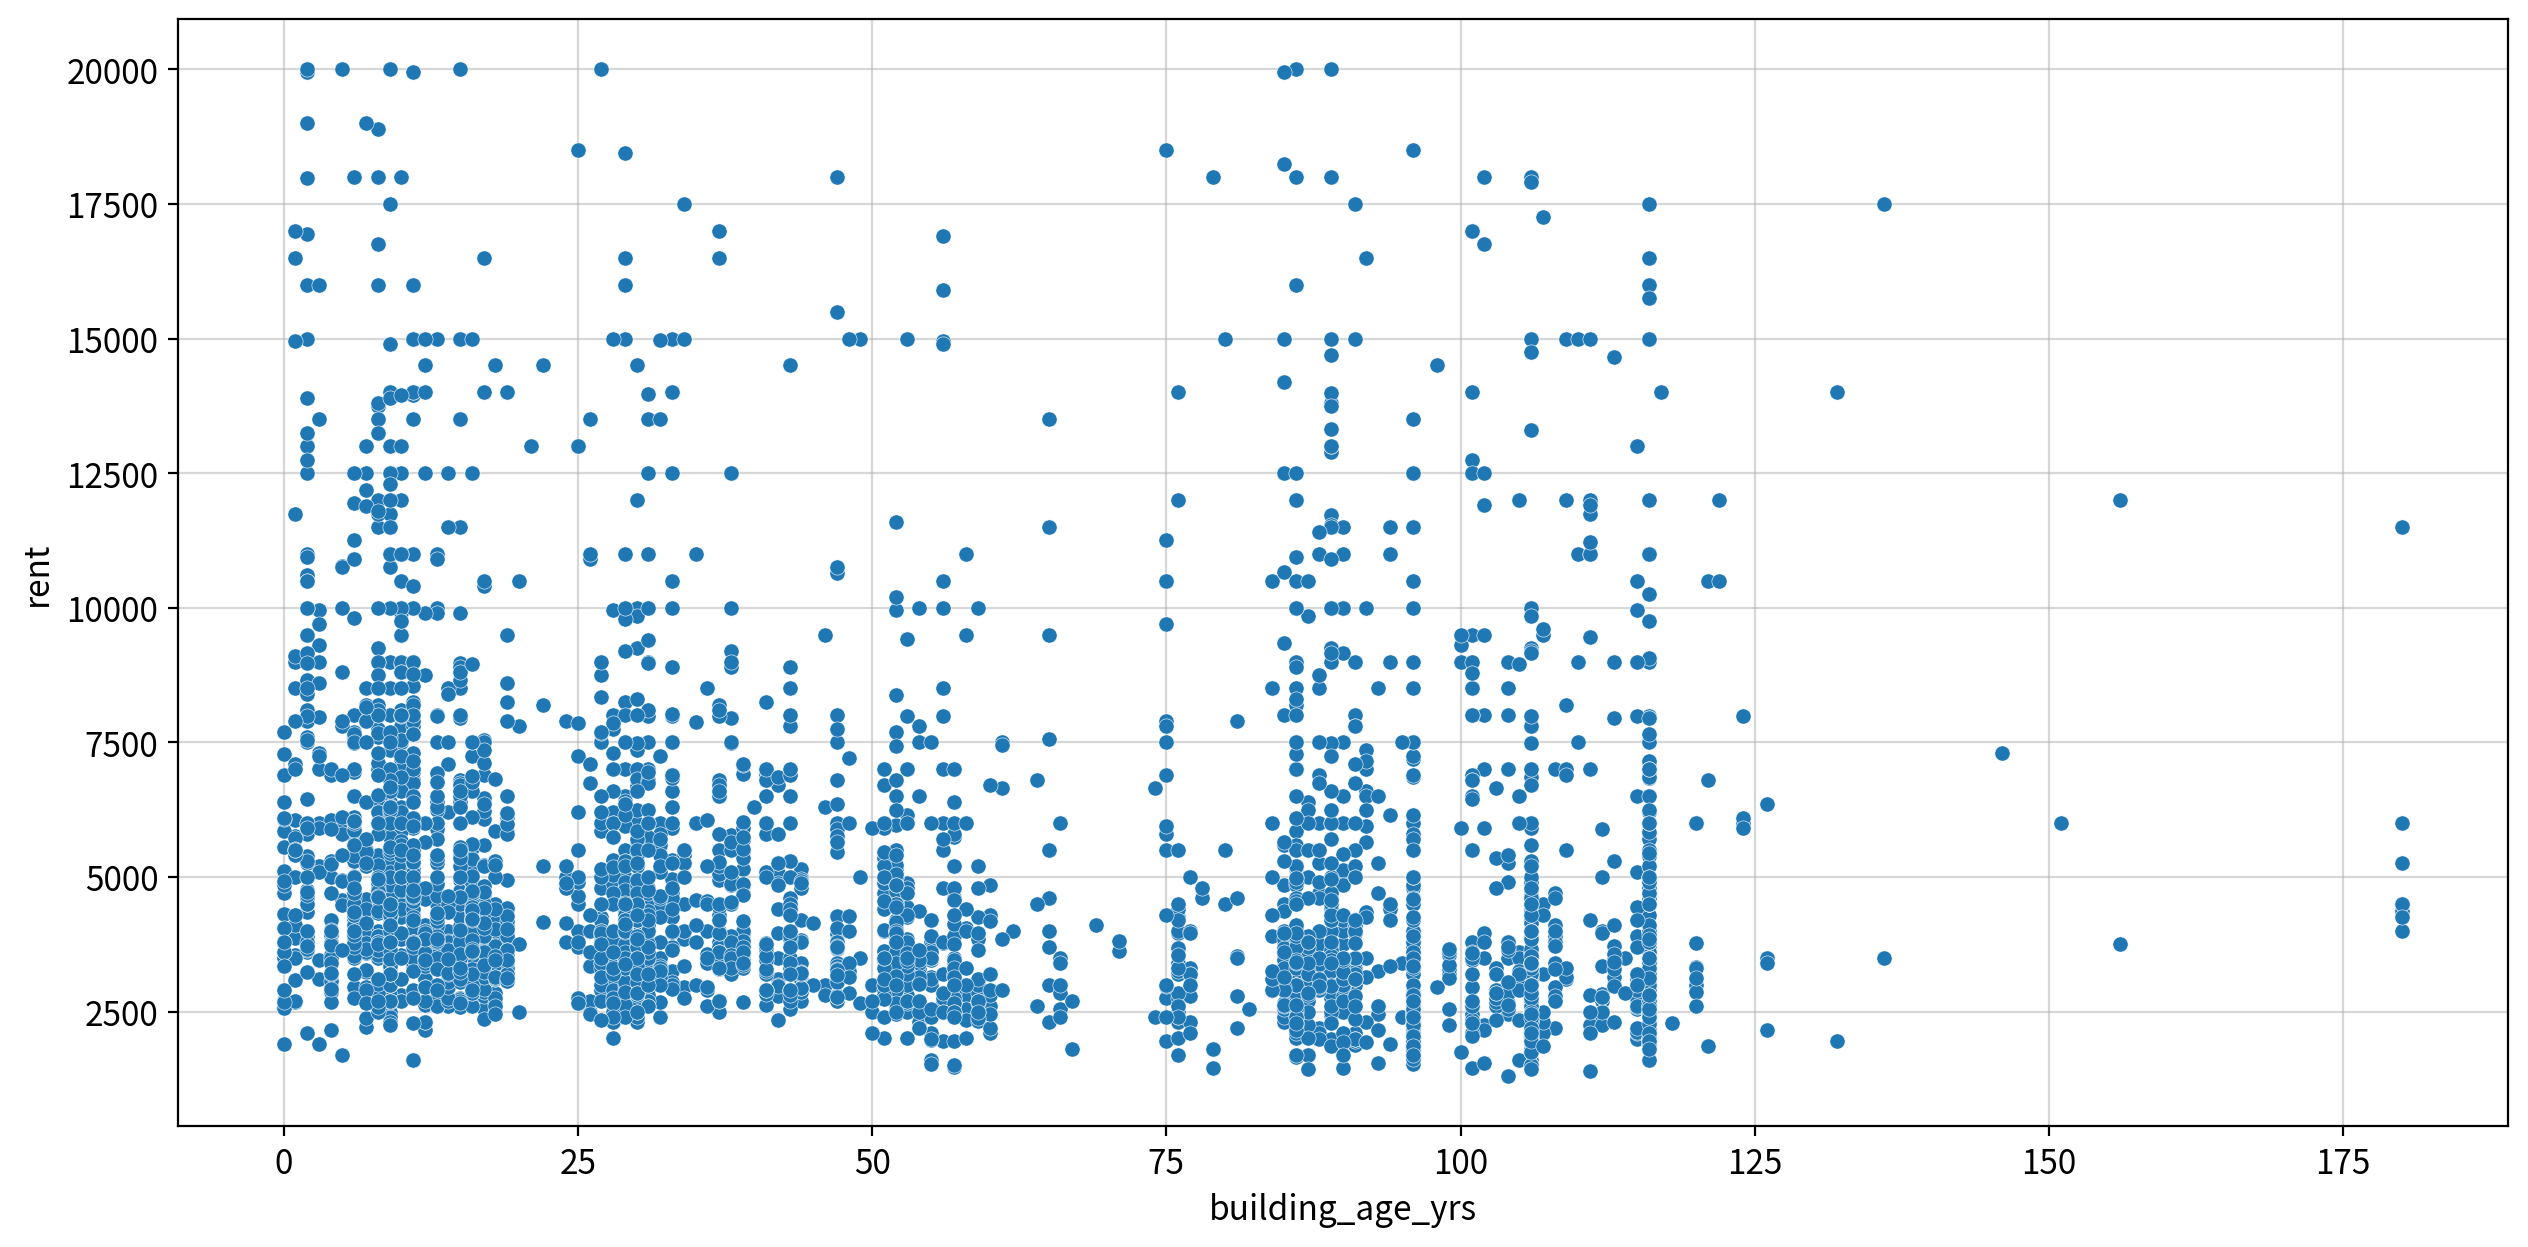

,,method,coef,p-value,strength,significant,normality_x,normality_y,linearity,influential_outlier,high_skew
x,y,,,,,,,,,,
building_age_yrs,rent,Spearman,-0.254,0.000,Weak,True,False,False,False,False,True


In [30]:
# 연속형 독립변수 이름을 탐색하면서 반복
for f in continuous_cols:
    # 빈 줄 출력용
    print()

    # 분석 단위 제목 출력
    display(Markdown(f"#### ▶ {f} → {target}"))

    #시각화
    my_plot.scatterplot(data=df, x=f, y=target, outline=False,
                        # 데이터 밀도에 따라 외곽선 굵기와 점 크기 조절
                      linewidth=0.2, size=30)

    # my_stats는 시각화까지 일괄처리 한다.
    display(my_stats.correlation(df, x=f, y=target, plot=False))

#### ▶ no_fee → rent

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

0 vs. 1: Mann-Whitney-Wilcoxon test two-sided, P_val:6.547e-01 U_stat=1.521e+06


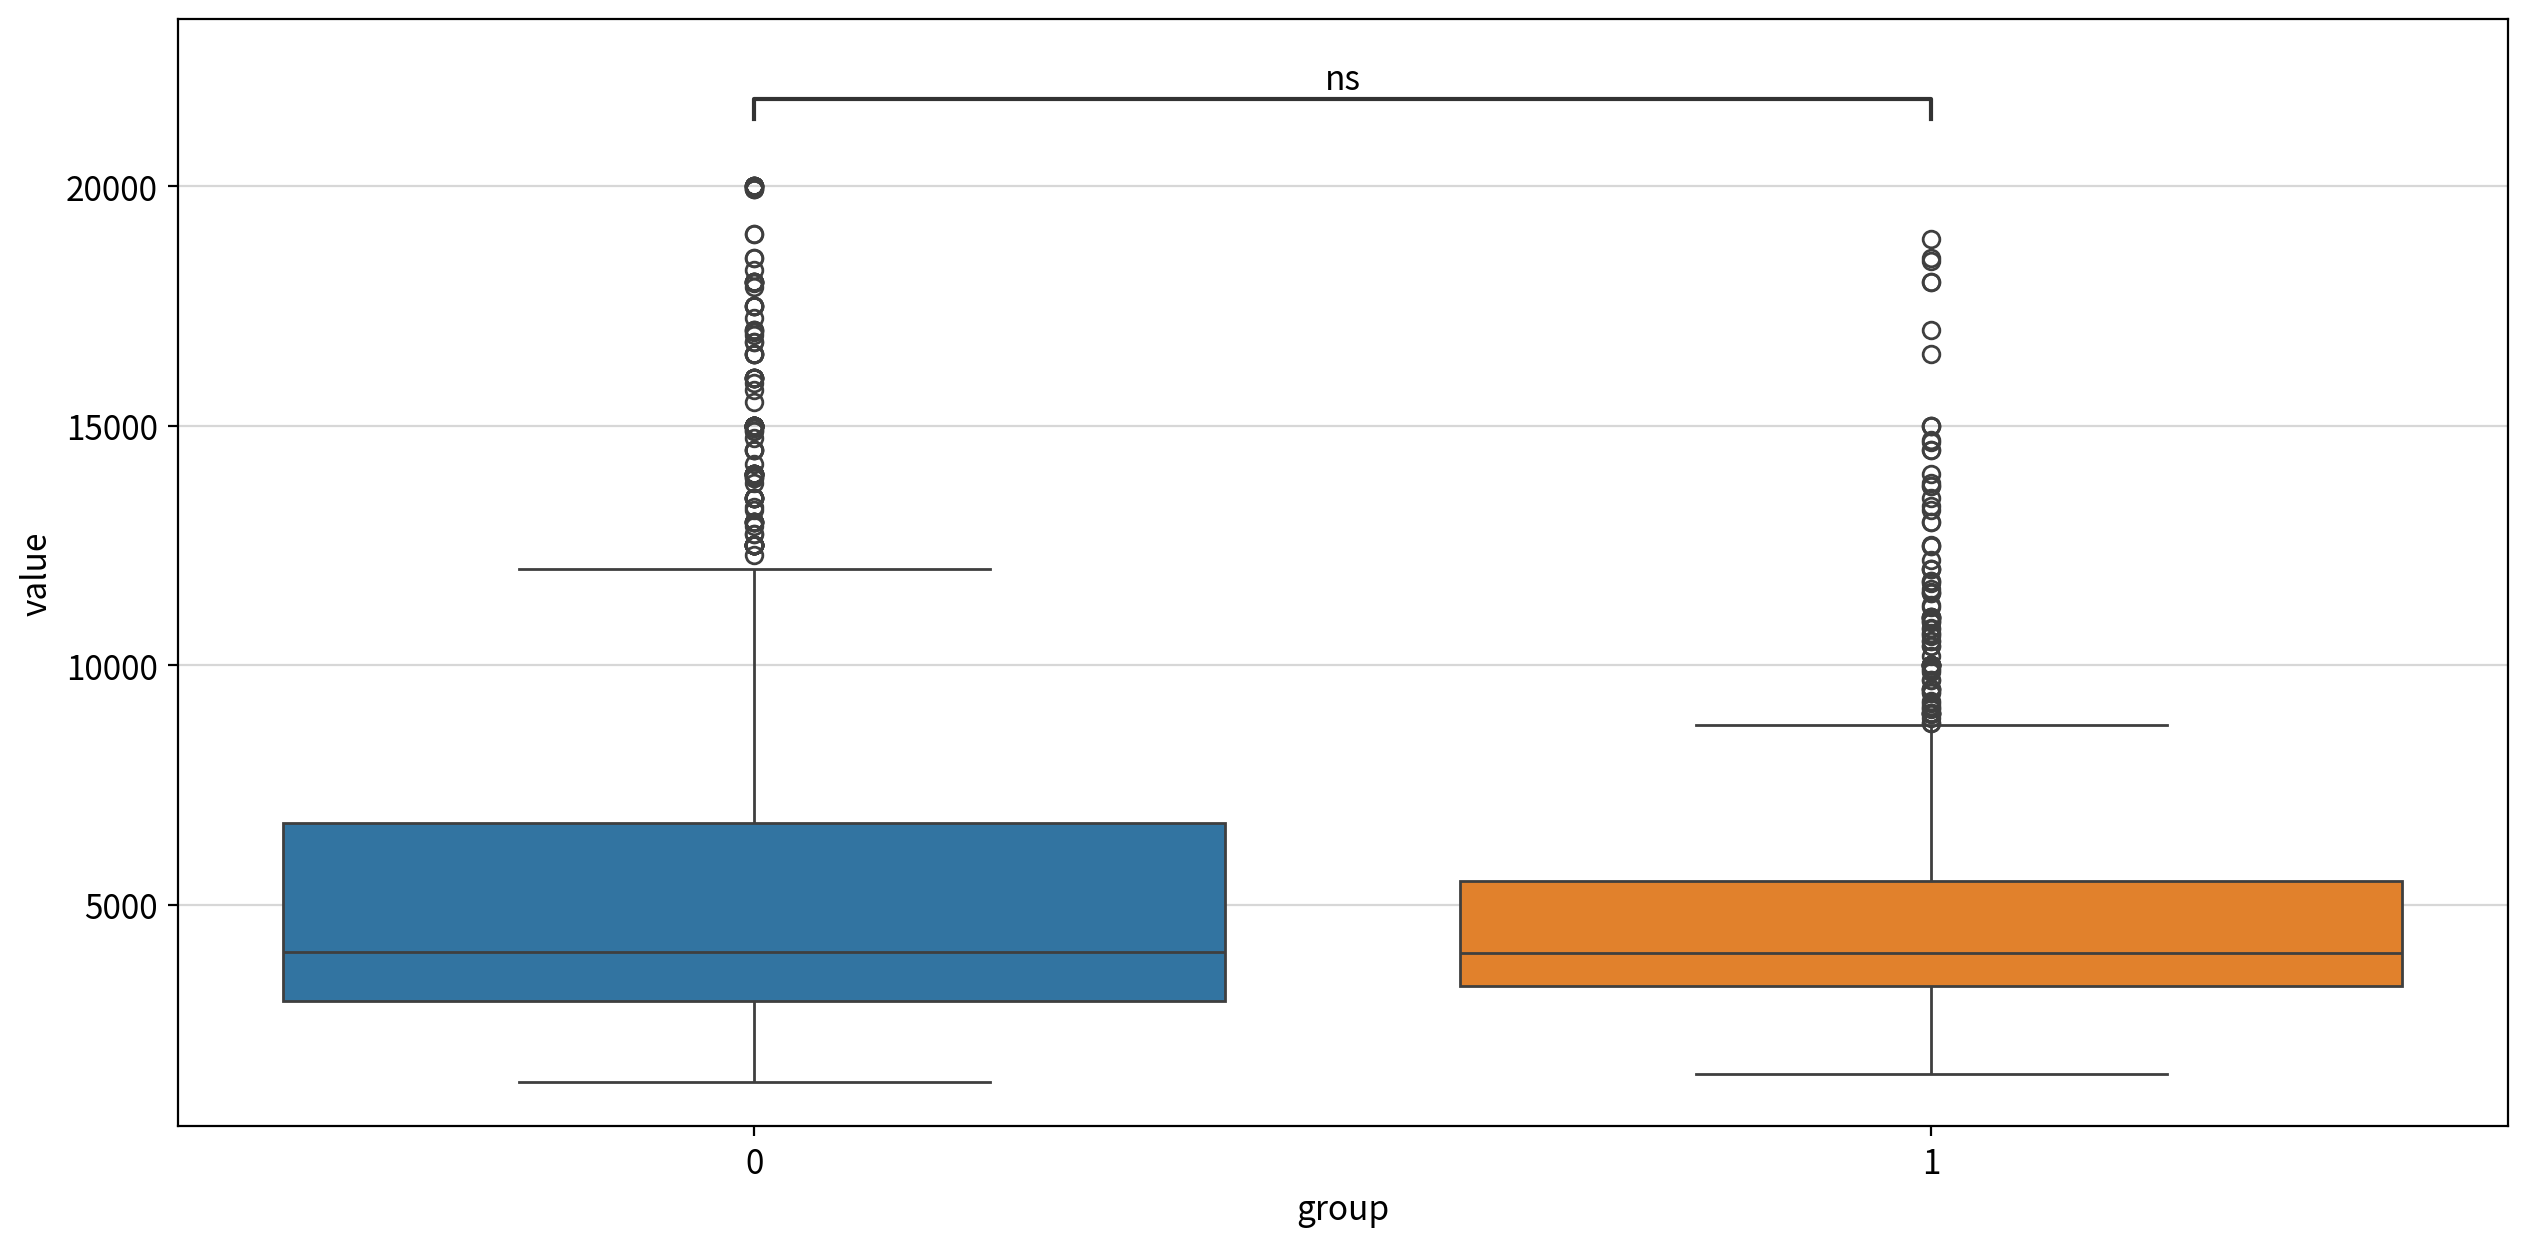

statistic  p-value  significant result
test                alternative                                         
Mann-Whitney U test two-sided   1520591.500    0.655        False  0 = 1
                    less        1520591.500    0.673        False  0 ≥ 1
                    greater     1520591.500    0.327        False  0 ≤ 1

#### ▶ has_roofdeck → rent

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

0 vs. 1: Mann-Whitney-Wilcoxon test two-sided, P_val:4.902e-02 U_stat=7.763e+05


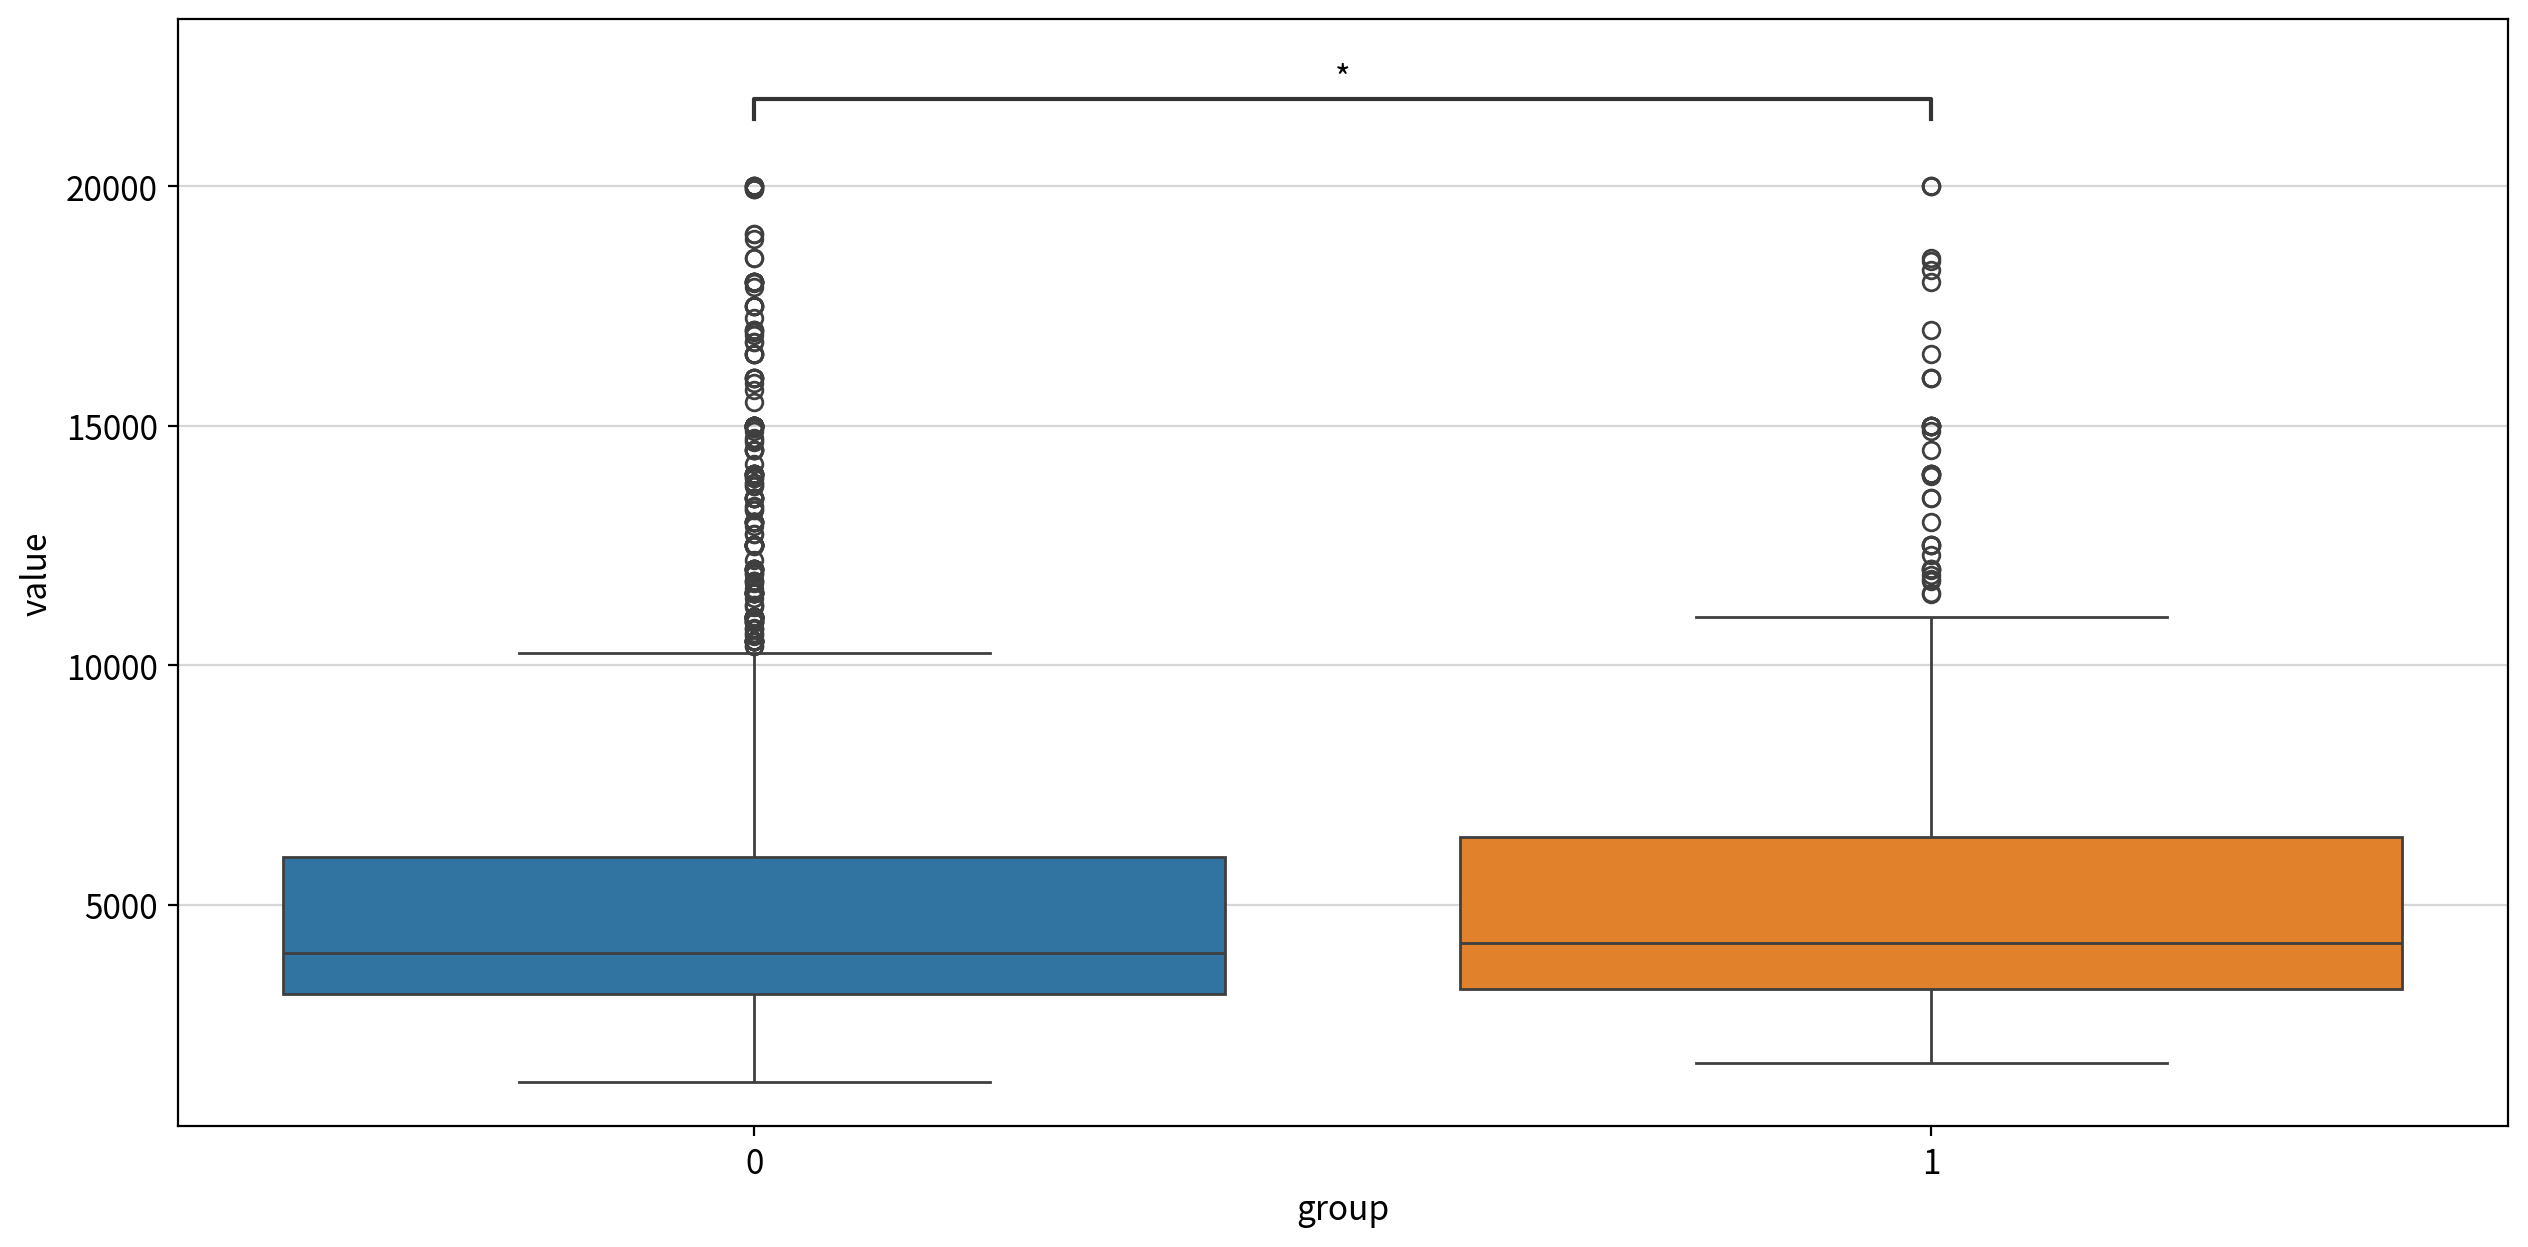

statistic  p-value  significant result
test                alternative                                        
Mann-Whitney U test two-sided   776250.500    0.049         True  0 ≠ 1
                    less        776250.500    0.025         True  0 < 1
                    greater     776250.500    0.976        False  0 ≤ 1

#### ▶ has_washer_dryer → rent

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

0 vs. 1: Mann-Whitney-Wilcoxon test two-sided, P_val:1.641e-04 U_stat=7.585e+05


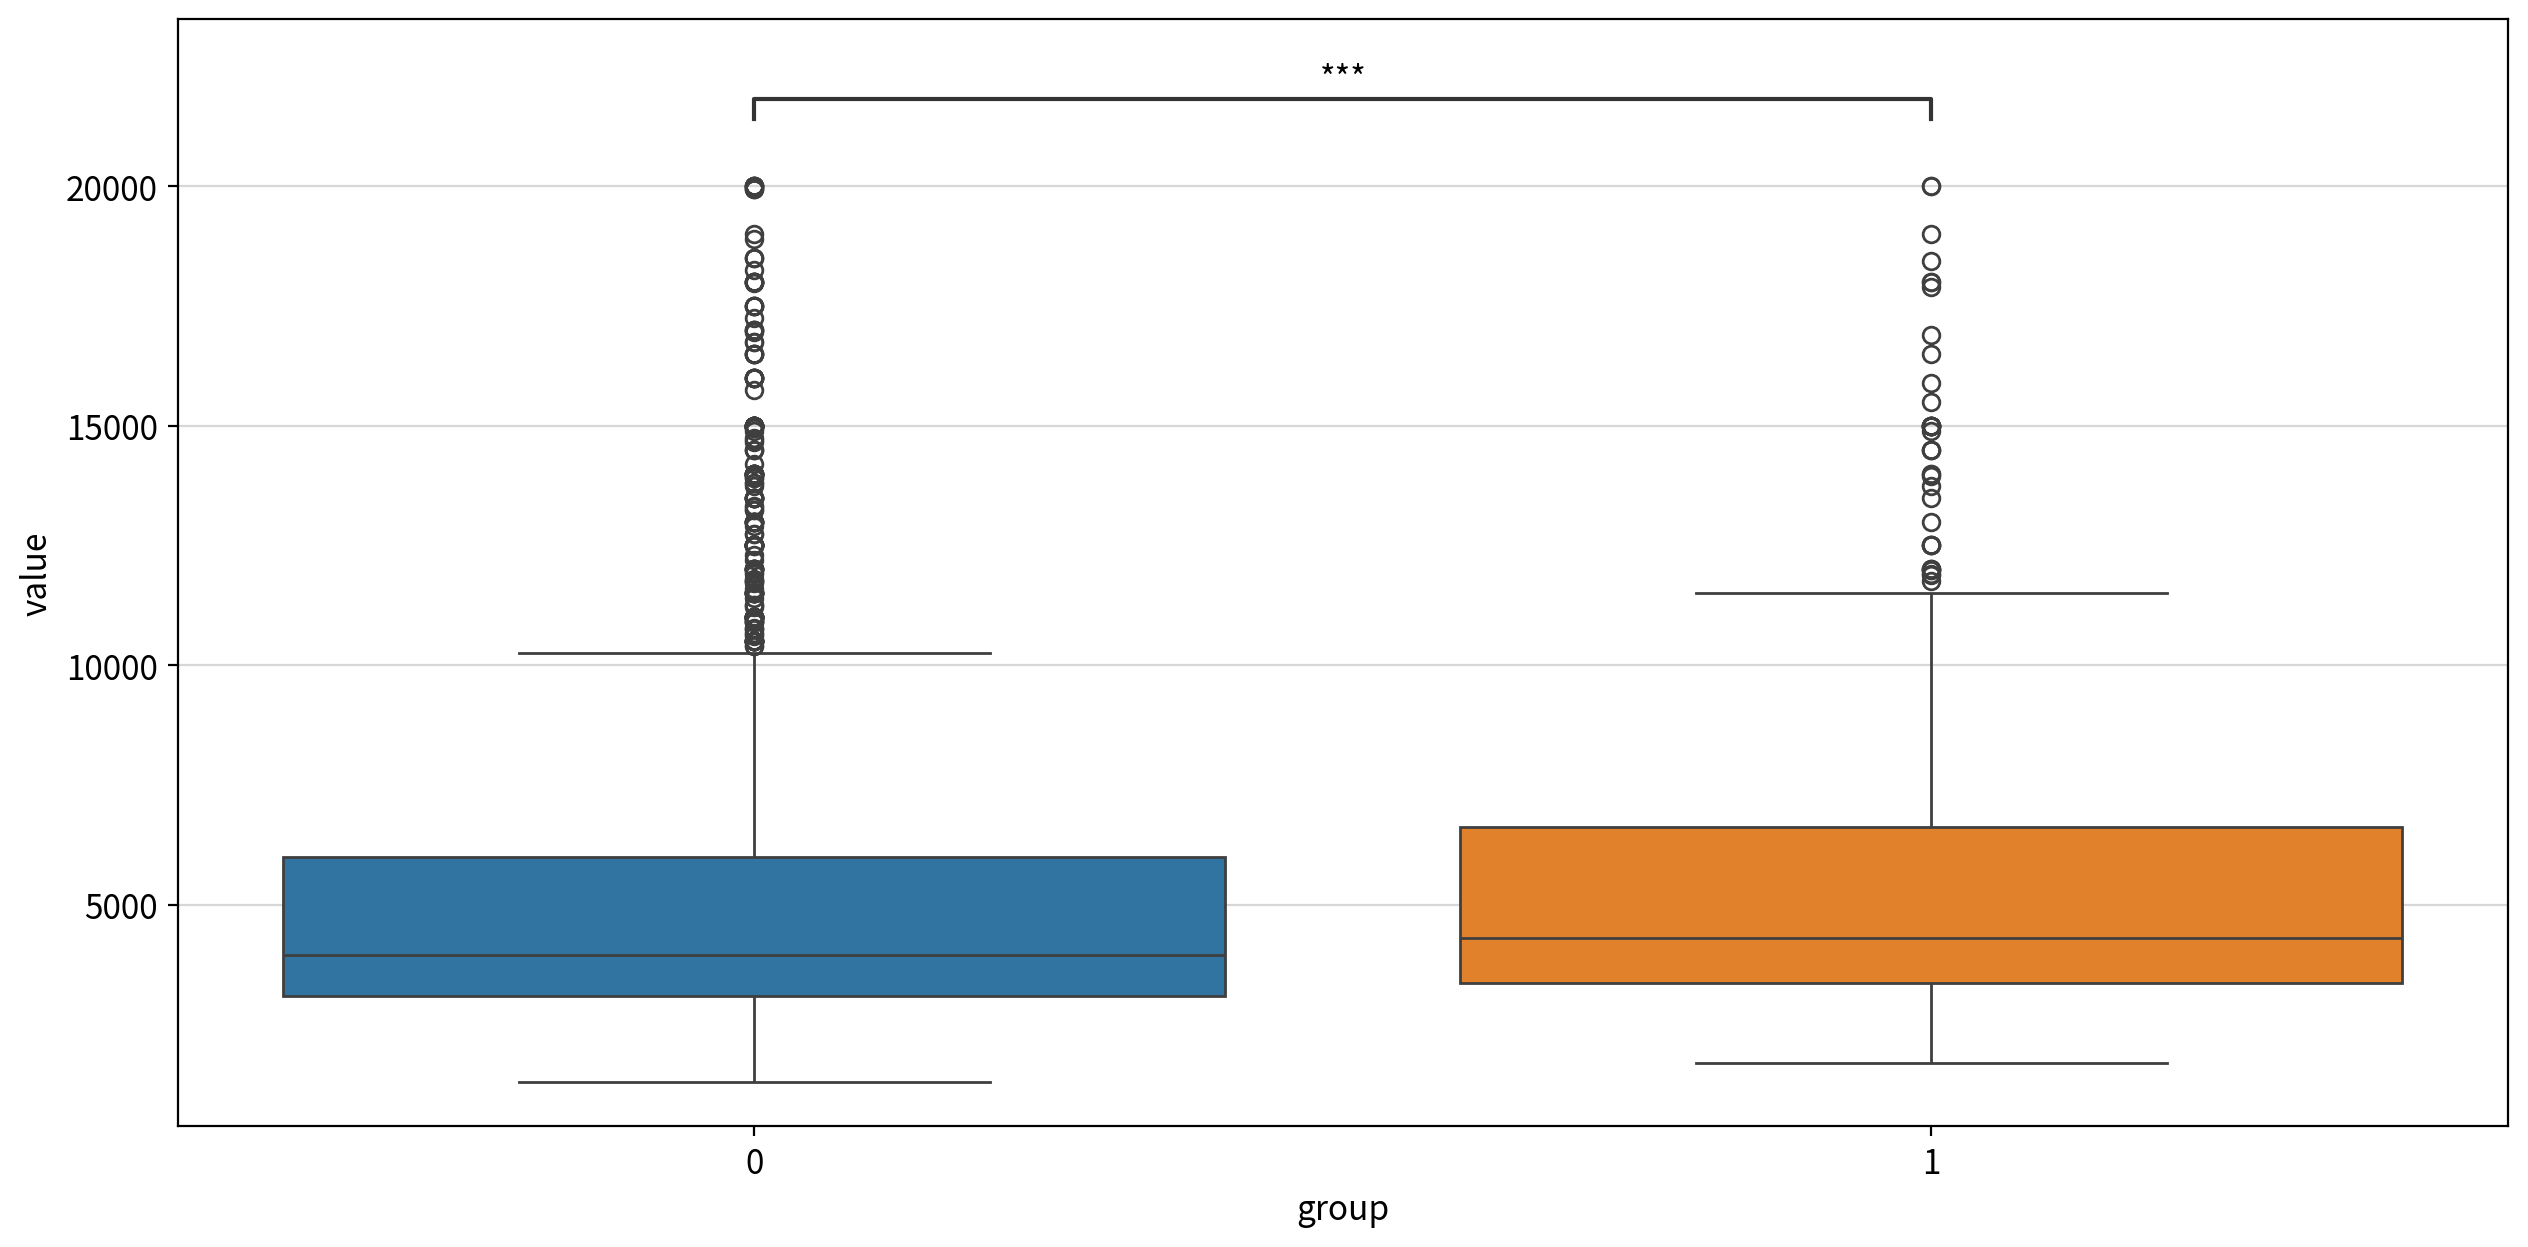

statistic  p-value  significant result
test                alternative                                        
Mann-Whitney U test two-sided   758537.000    0.000         True  0 ≠ 1
                    less        758537.000    0.000         True  0 < 1
                    greater     758537.000    1.000        False  0 ≤ 1

#### ▶ has_doorman → rent

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

0 vs. 1: Mann-Whitney-Wilcoxon test two-sided, P_val:1.100e-02 U_stat=1.196e+06


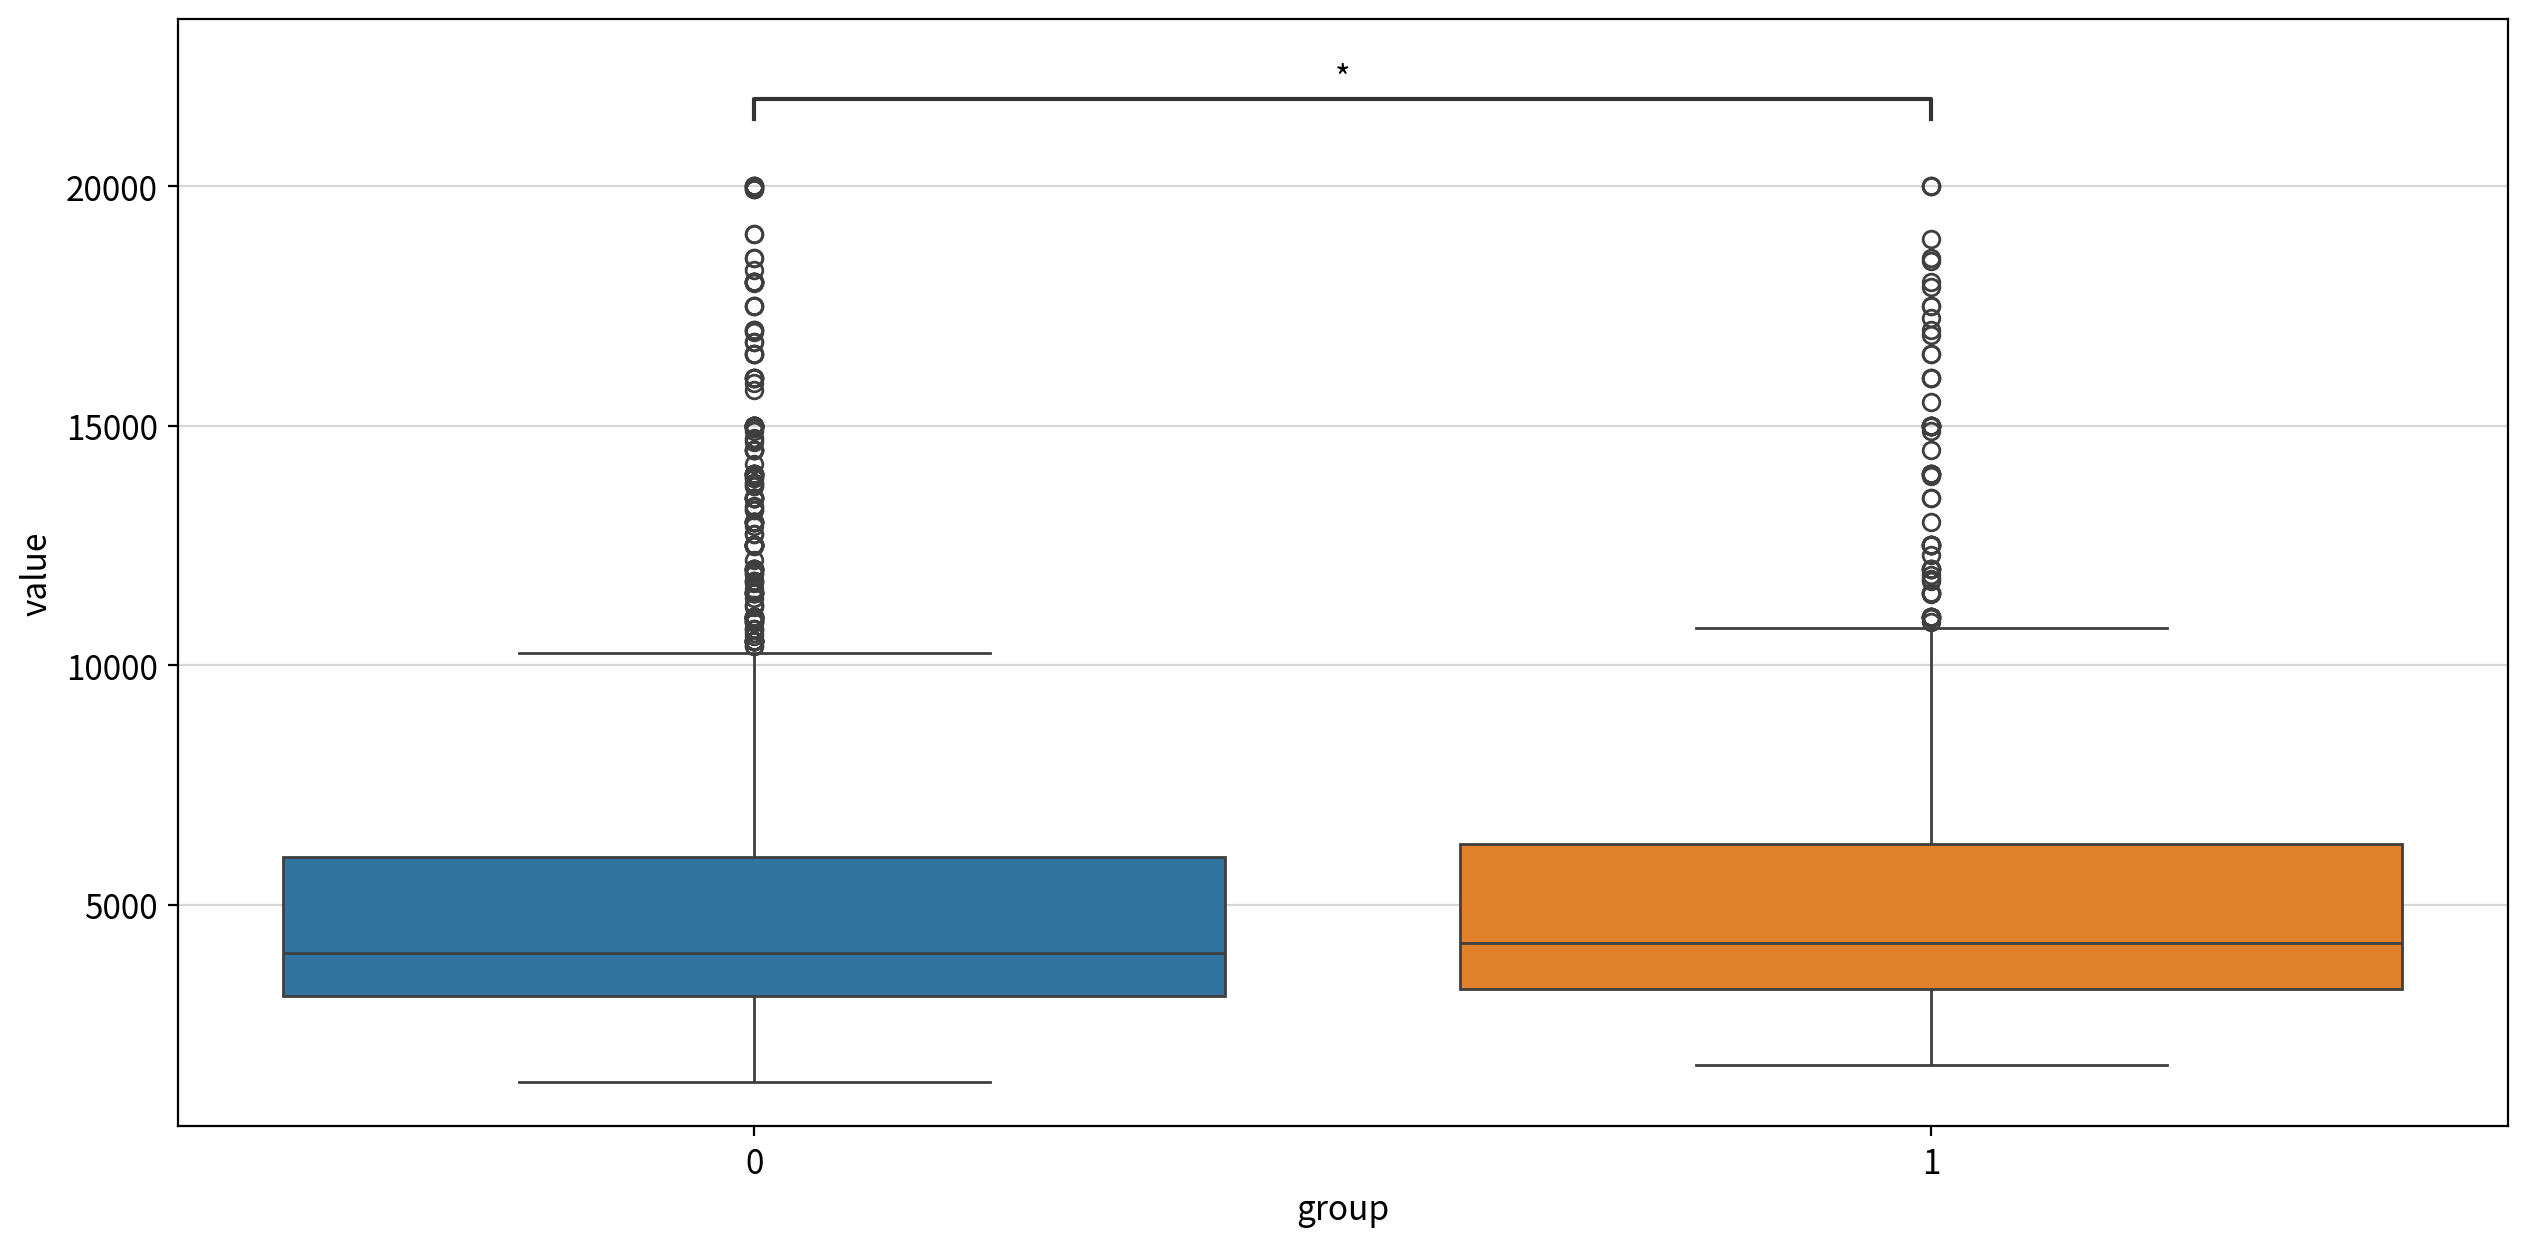

statistic  p-value  significant result
test                alternative                                         
Mann-Whitney U test two-sided   1196155.500    0.011         True  0 ≠ 1
                    less        1196155.500    0.005         True  0 < 1
                    greater     1196155.500    0.995        False  0 ≤ 1

#### ▶ has_elevator → rent

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

0 vs. 1: Mann-Whitney-Wilcoxon test two-sided, P_val:1.174e-03 U_stat=1.212e+06


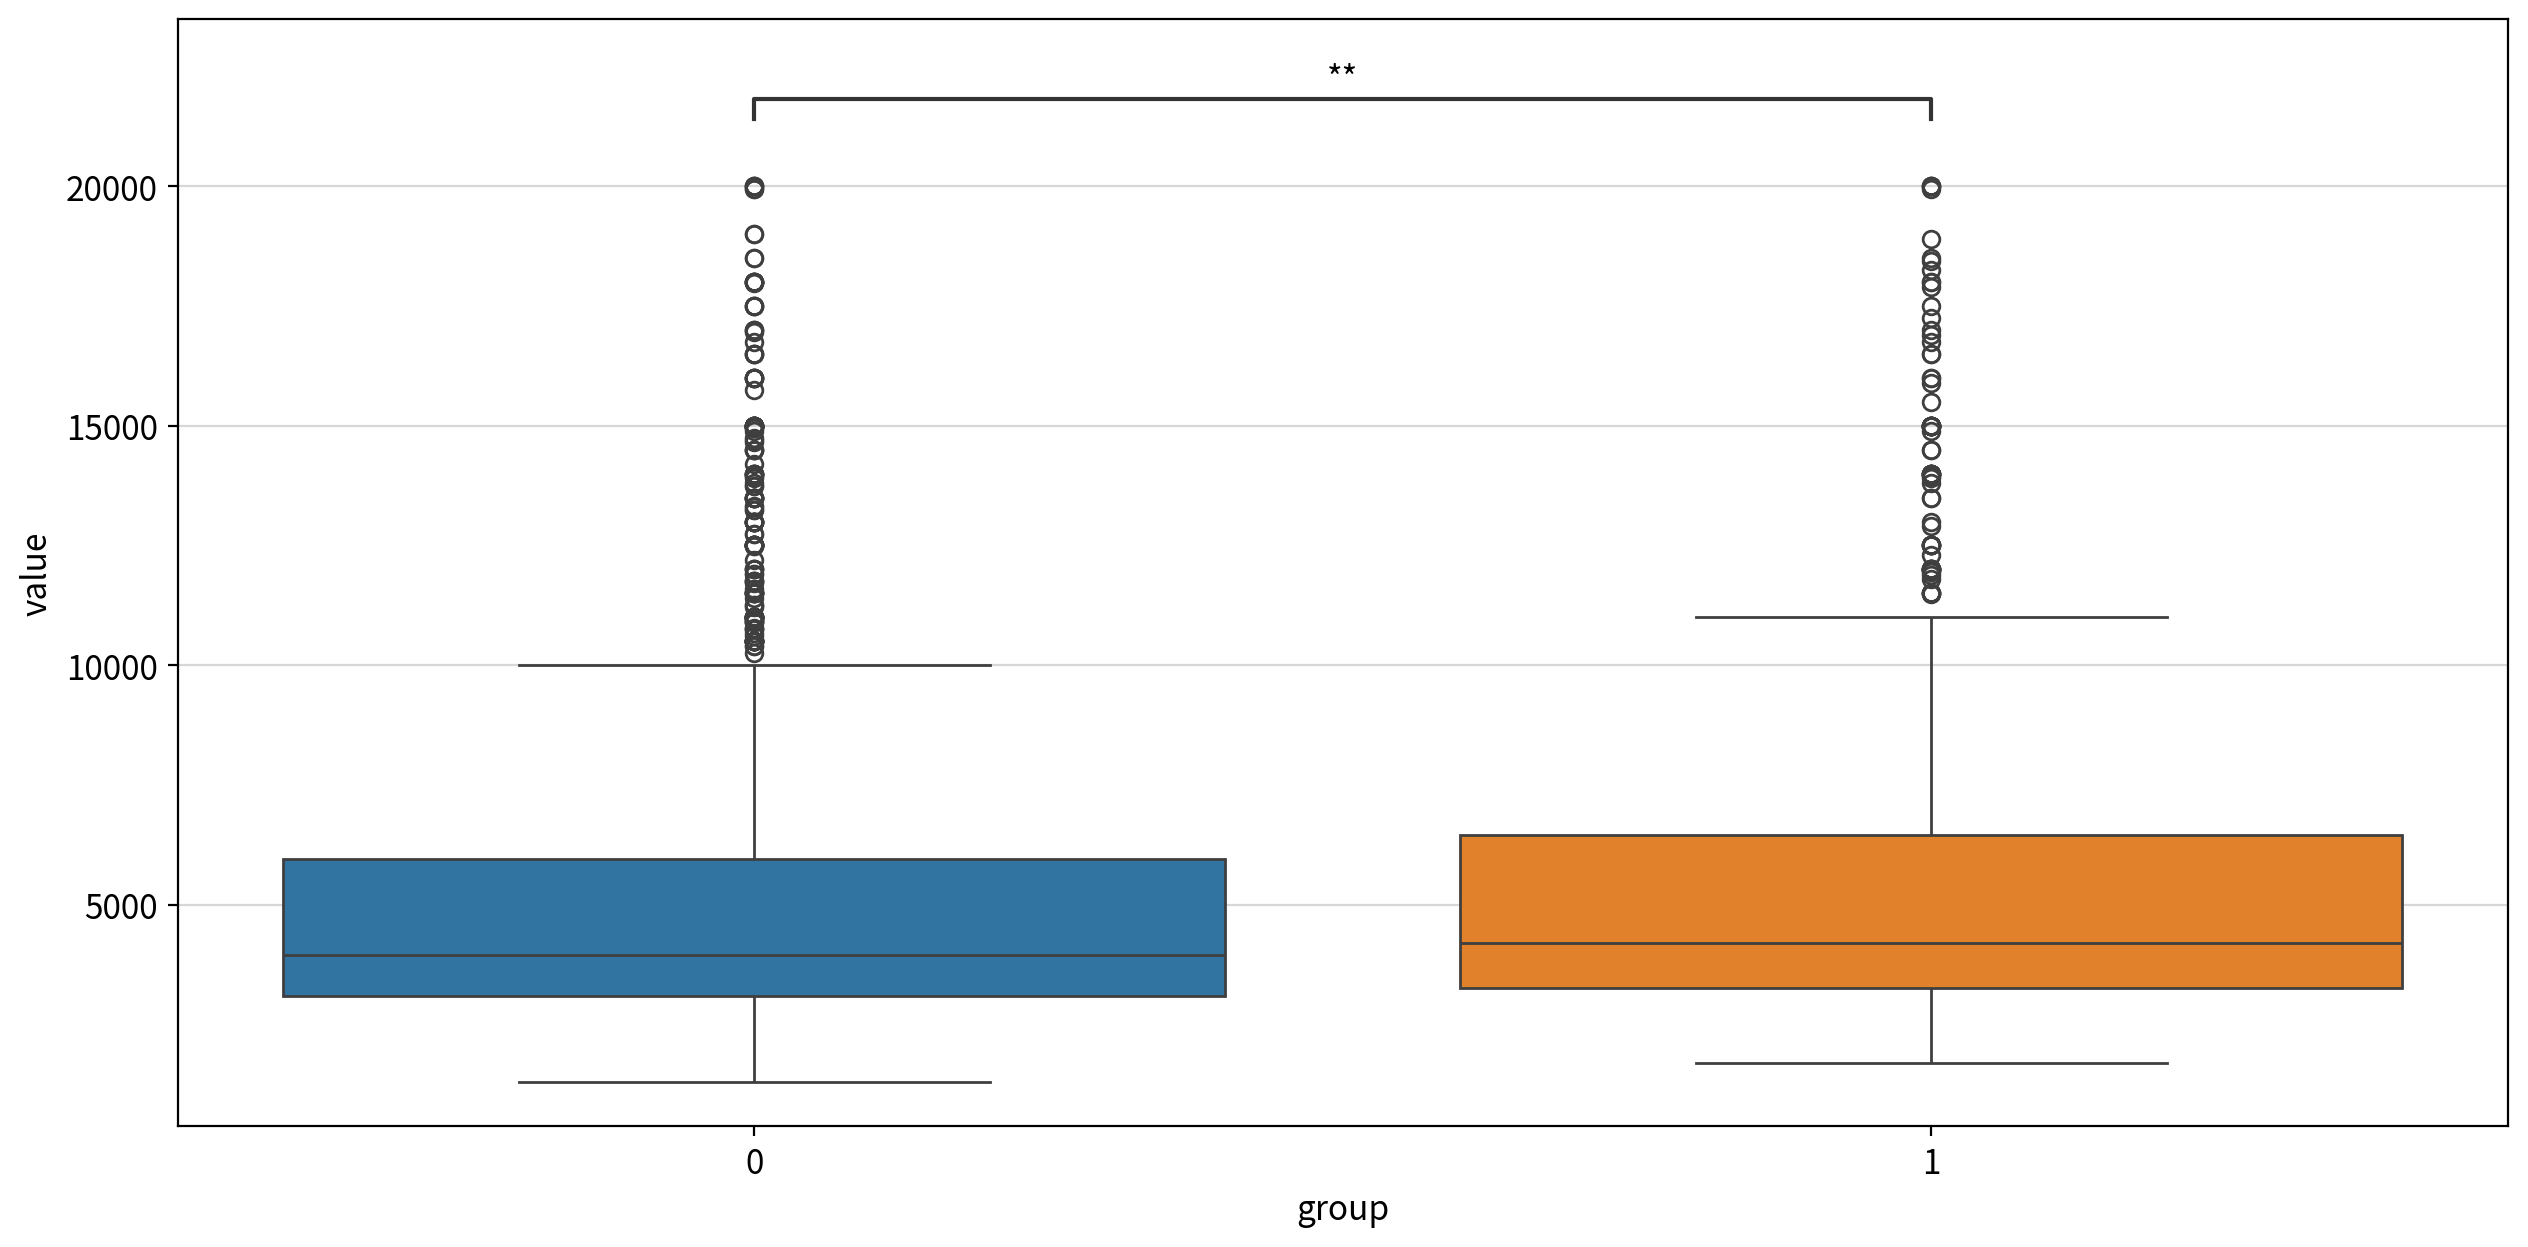

statistic  p-value  significant result
test                alternative                                         
Mann-Whitney U test two-sided   1211737.000    0.001         True  0 ≠ 1
                    less        1211737.000    0.001         True  0 < 1
                    greater     1211737.000    0.999        False  0 ≤ 1

#### ▶ has_dishwasher → rent

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

0 vs. 1: Mann-Whitney-Wilcoxon test two-sided, P_val:2.197e-04 U_stat=8.594e+05


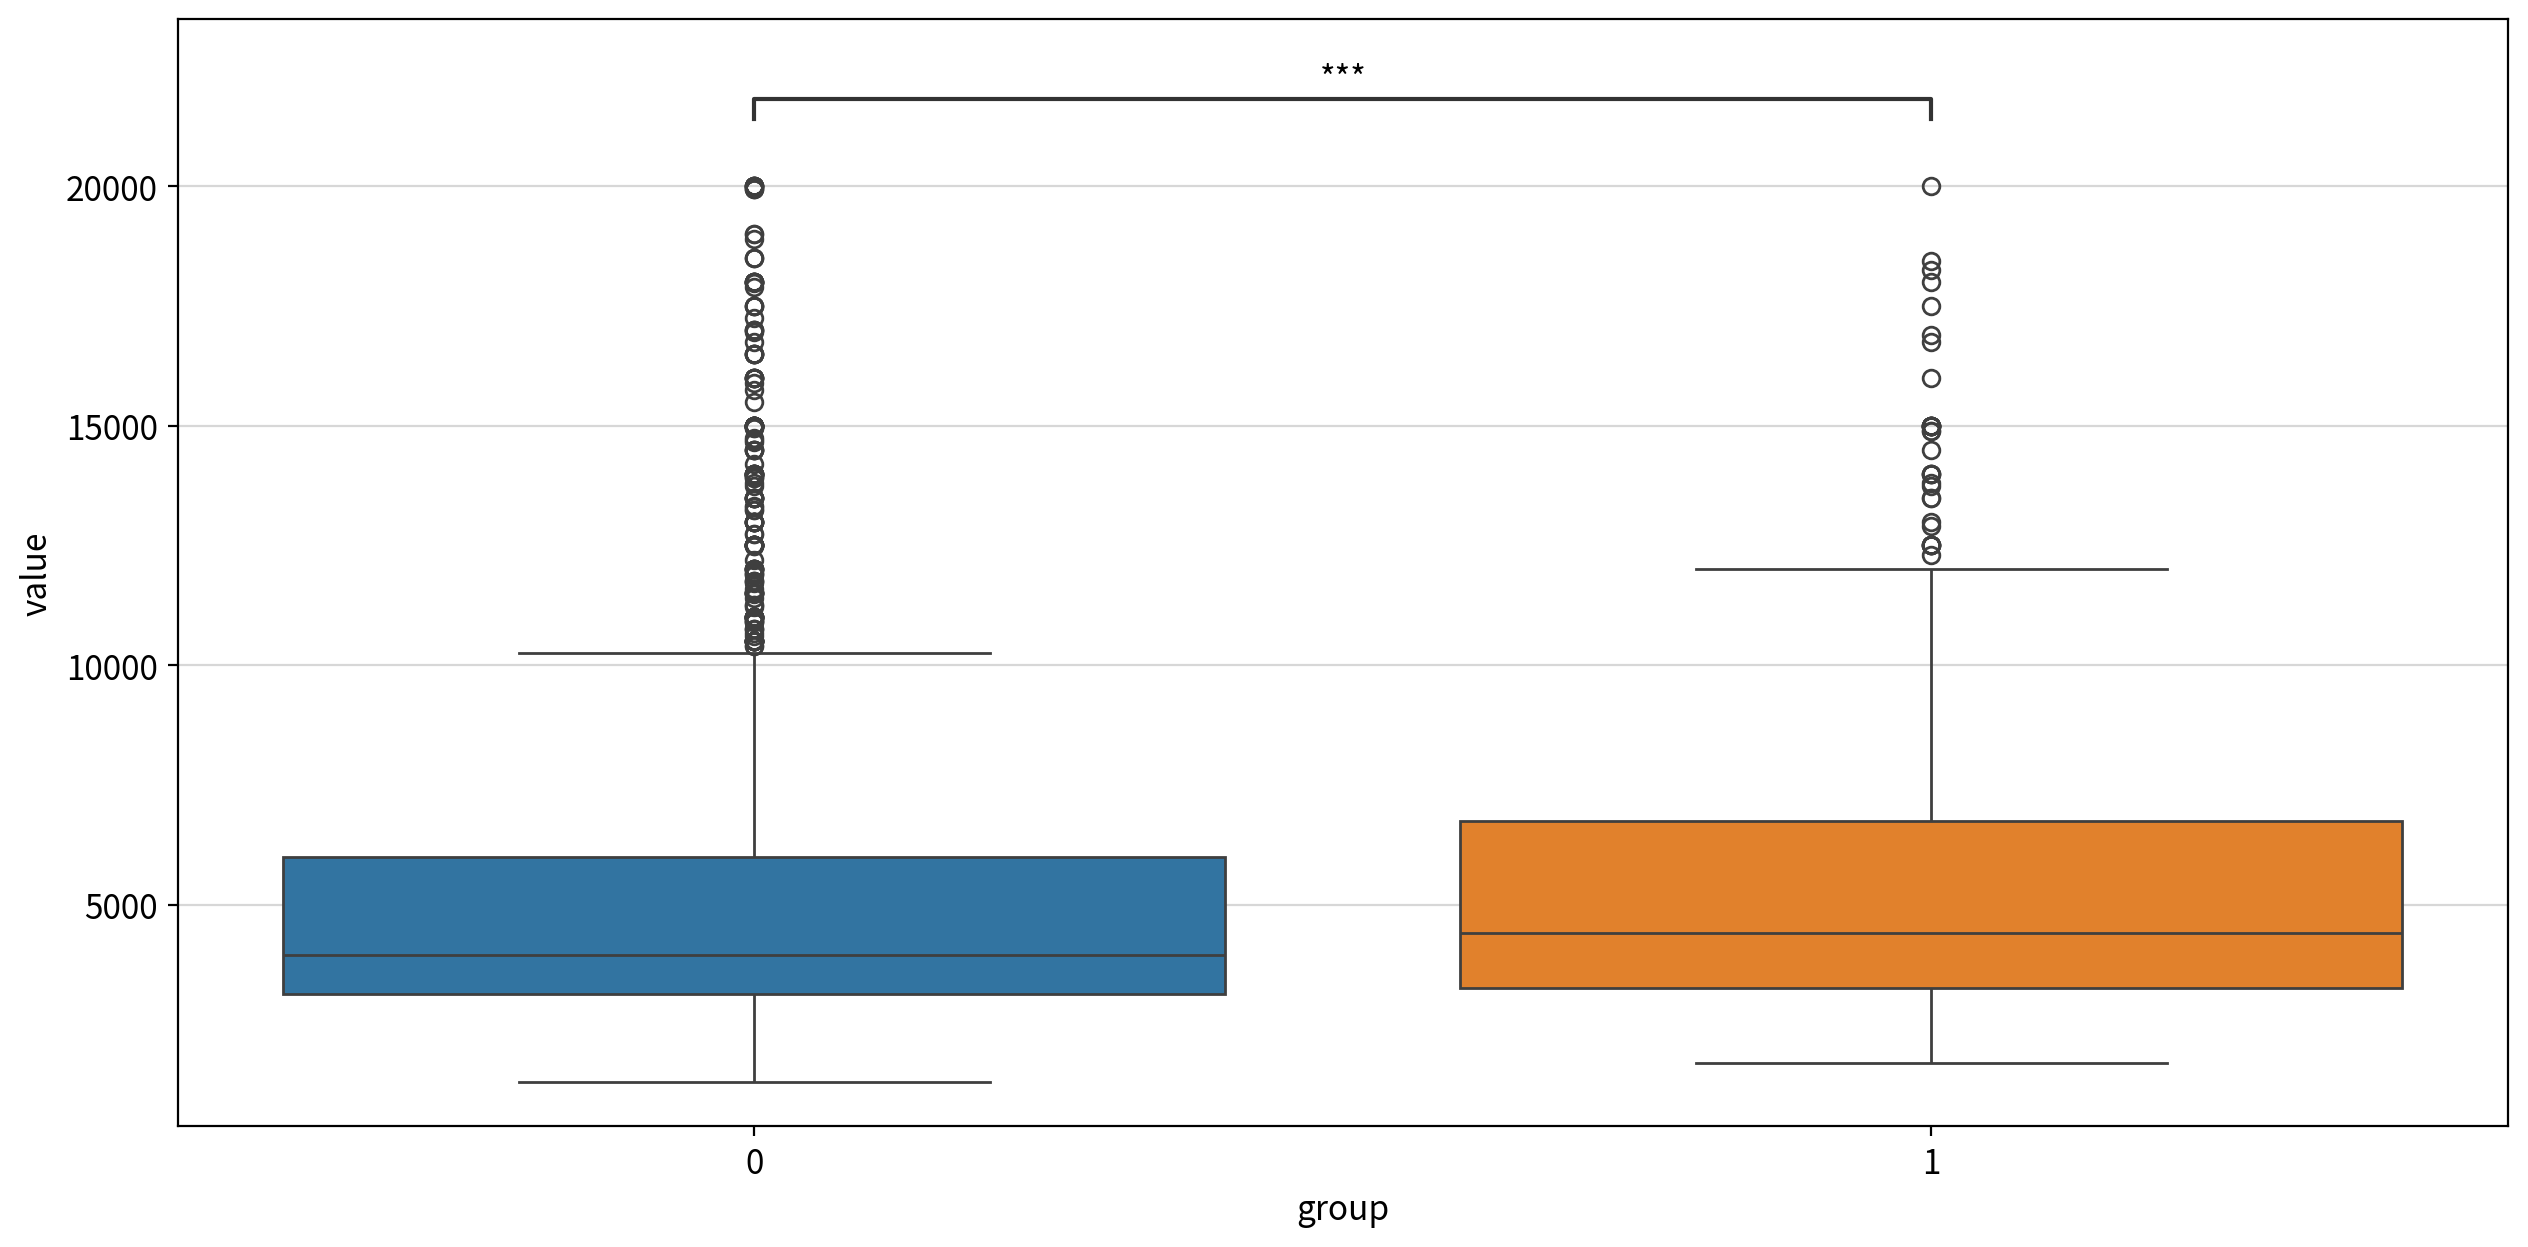

statistic  p-value  significant result
test                alternative                                        
Mann-Whitney U test two-sided   859406.500    0.000         True  0 ≠ 1
                    less        859406.500    0.000         True  0 < 1
                    greater     859406.500    1.000        False  0 ≤ 1

#### ▶ has_patio → rent

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

0 vs. 1: Mann-Whitney-Wilcoxon test two-sided, P_val:5.062e-02 U_stat=2.989e+05


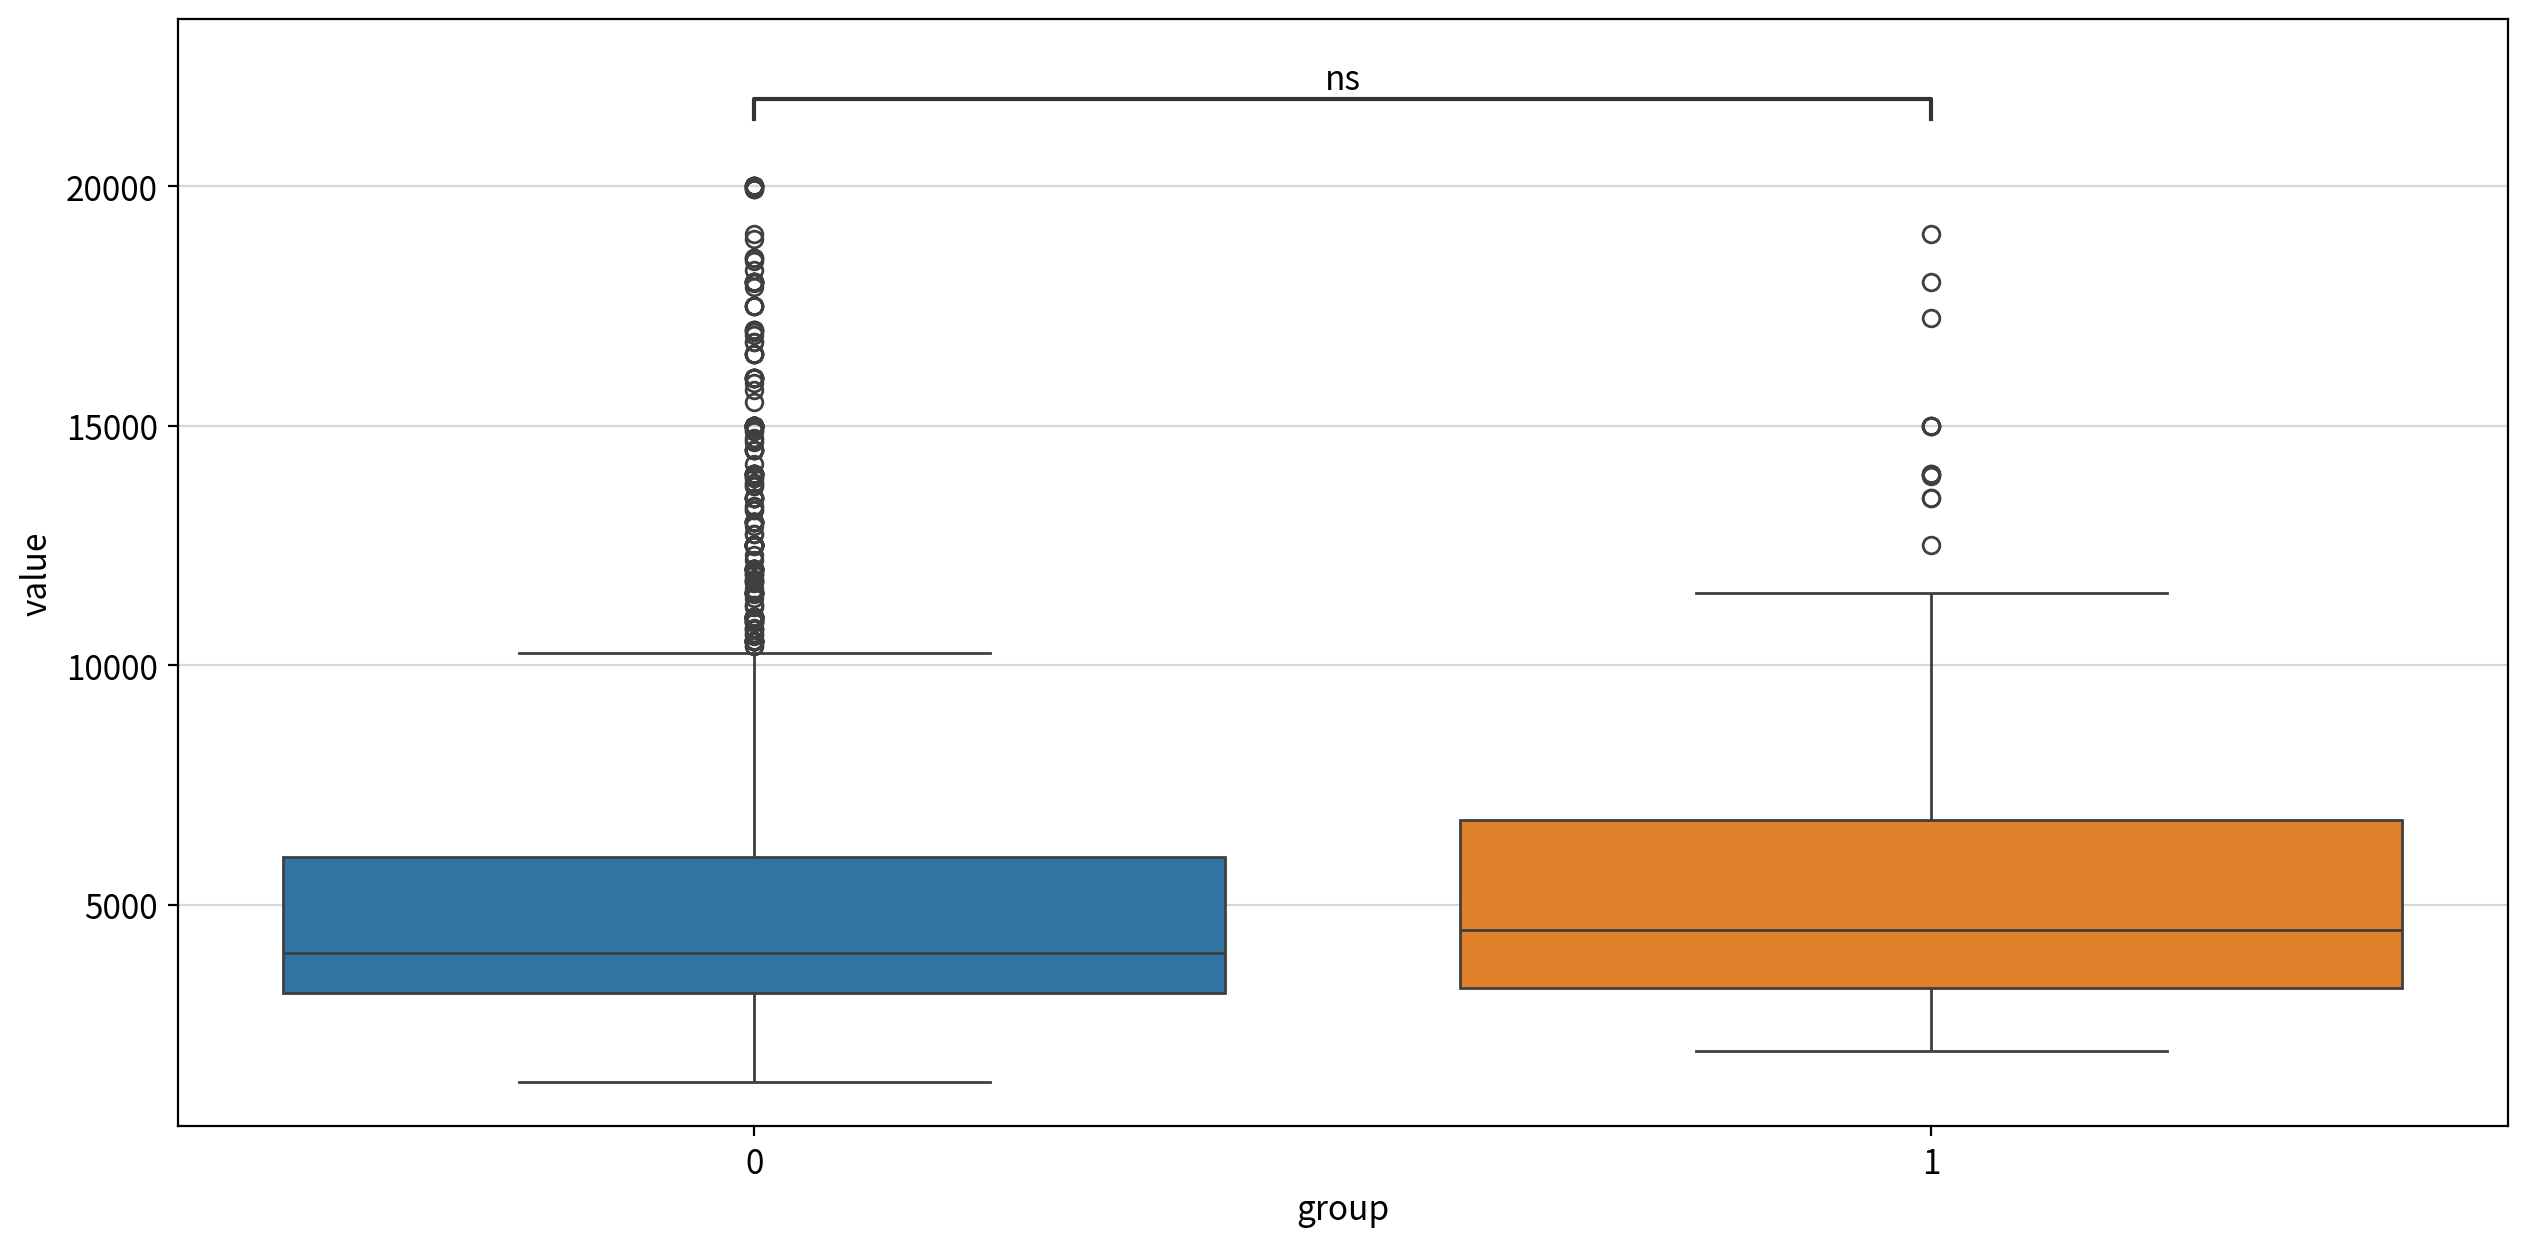

statistic  p-value  significant result
test                alternative                                        
Mann-Whitney U test two-sided   298929.000    0.051        False  0 = 1
                    less        298929.000    0.025         True  0 < 1
                    greater     298929.000    0.975        False  0 ≤ 1

#### ▶ has_gym → rent

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

0 vs. 1: Mann-Whitney-Wilcoxon test two-sided, P_val:3.904e-02 U_stat=8.561e+05


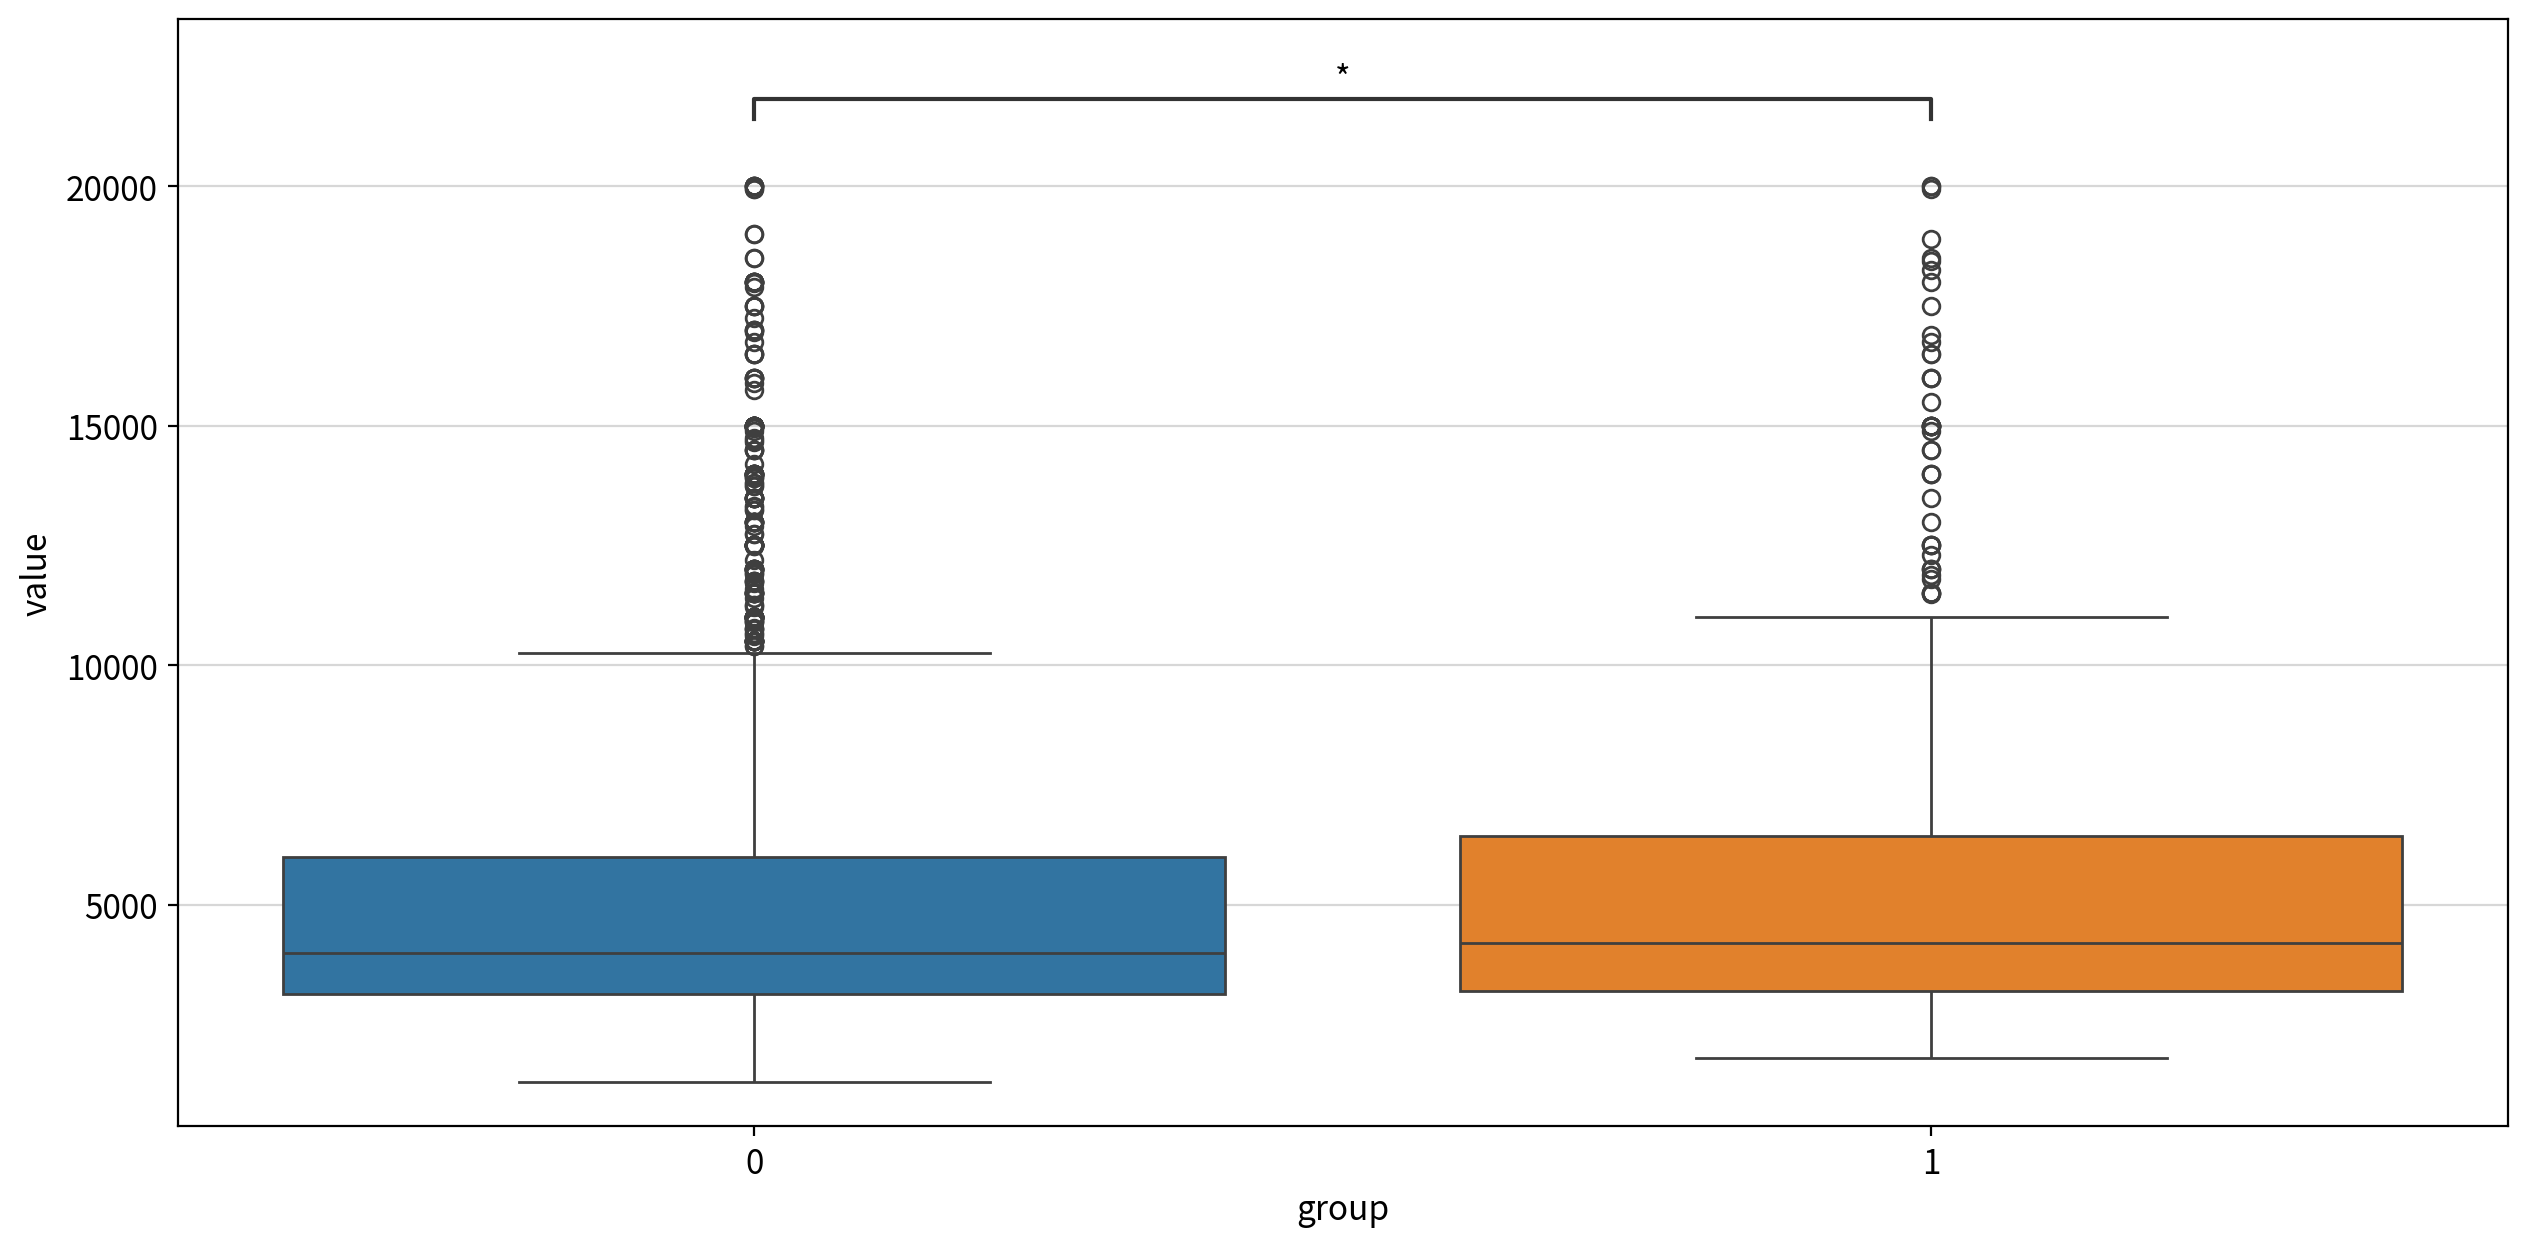

statistic  p-value  significant result
test                alternative                                        
Mann-Whitney U test two-sided   856086.500    0.039         True  0 ≠ 1
                    less        856086.500    0.019         True  0 < 1
                    greater     856086.500    0.981        False  0 ≤ 1

In [ ]:
for n in nominal_cols:
    # 2개의 고유값만 존재하는 범주형 독립변수에 대해서만 검정을 수행한다.
    if len(df[n].unique()) == 2:
        # 빈 줄 출력용
        print()

        # 분석 단위 제목 출력
        display(Markdown(f"#### ▶ {n} → {target}"))

        # 수집된 데이터가 long 타입이므로 검정 대상만 wide 타입으로 변환해야 한다.
        wide_df = my_prep.long2wide(df, hue=n, values=target)
        display(my_stats.test_independent(wide_df,
                                         group1=wide_df.columns[0], group2=wide_df.columns[1]))

In [23]:
for n in nominal_cols:
    # 3개 이상의 고유값이 존재하는 명목형 독립변수에 대해서만 검정을 수행한다.
    if len(df[n].unique()) >= 3:
        print() # 빈 줄 출력용

        # 분석 단위 제목 출력
        display(Markdown(f"#### ▶ {n} → {target}"))

        # origin이 아닌 df를 사용해야 서열척도로 지정한 범주 순서가 반영된다.
        display(my_stats.anova_oneway(df, y=target, between=n))

        # 사후검정
        display(my_stats.posthoc_oneway(df, y=target, between=n, plot=False))

#### ▶ neighborhood → rent

c:\Users\itwill\OneDrive\mycoding\helpers\my_stats.py:89: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  s, p = normaltest(data[c].dropna())


,test,Source,ddof1,ddof2,F,p_unc,np2,effect_size
0,welch_anova,neighborhood,31,106.400,38.472,0.000,0.128,Medium


c:\Users\itwill\OneDrive\mycoding\helpers\my_stats.py:89: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  s, p = normaltest(data[c].dropna())


비교한 조합 쌍: 496개
유의한 쌍: 221개
평균 차이가 가장 큰 쌍: (Manhattanville) vs (Soho) → 차이 7072.655, 효과크기 Negligible, p-value nan
평균 차이가 가장 작은 쌍: (Chinatown) vs (Long Island City) → 차이 1.375, 효과크기 Negligible, p-value 1.000


c:\Users\itwill\AppData\Local\Programs\Python\Python313\Lib\site-packages\pingouin\effsize.py:830: RuntimeWarning: Degrees of freedom <= 0 for slice
  poolsd = np.sqrt(((nx - 1) * x.var(ddof=1) + (ny - 1) * y.var(ddof=1)) / dof)
c:\Users\itwill\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\_core\_methods.py:211: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


,test,A,B,mean_A,mean_B,diff,se,T,df,pval,hedges,significant,effect_size
0,Games-Howell,Battery Park City,Central Harlem,5968.962,2963.927,3005.035,325.469,9.233,152.772,0.000,1.258,True,Large
1,Games-Howell,Battery Park City,Central Park South,5968.962,7506.957,-1537.995,802.293,-1.917,28.868,0.978,-0.499,False,Small
2,Games-Howell,Battery Park City,Chelsea,5968.962,6193.484,-224.522,365.865,-0.614,220.528,1.000,-0.075,False,Negligible
3,Games-Howell,Battery Park City,Chinatown,5968.962,2955.625,3013.337,422.383,7.134,23.311,0.000,1.049,True,Large
4,Games-Howell,Battery Park City,East Harlem,5968.962,2502.000,3466.962,303.366,11.428,122.737,0.000,1.371,True,Large
...,...,...,...,...,...,...,...,...,...,...,...,...,...
491,Games-Howell,Upper West Side,West Harlem,5354.050,2406.000,2948.050,336.386,8.764,1.460,0.170,0.877,False,Large
492,Games-Howell,Upper West Side,West Village,5354.050,5970.970,-616.920,449.257,-1.373,80.784,1.000,-0.183,False,Negligible
493,Games-Howell,Washington Heights,West Harlem,2539.333,2406.000,133.333,325.615,0.409,1.282,1.000,0.162,False,Negligible
494,Games-Howell,Washington Heights,West Village,2539.333,5970.970,-3431.637,441.250,-7.777,74.844,0.000,-1.282,True,Large


In [24]:
corr = my_stats.multi_correlation(df, columns=continuous_cols, plot=False)
my_stats.correlation_summary(corr)

,bedrooms,bathrooms,size_sqft,min_to_subway,floor,building_age_yrs
bedrooms,1.000,0.722,0.829,0.042,0.048,0.007
bathrooms,0.722,1.000,0.763,0.007,0.141,-0.115
size_sqft,0.829,0.763,1.000,-0.009,0.136,-0.063
min_to_subway,0.042,0.007,-0.009,1.000,0.018,-0.158
floor,0.048,0.141,0.136,0.018,1.000,-0.407
building_age_yrs,0.007,-0.115,-0.063,-0.158,-0.407,1.000


,max-y,max-coef,count,columns
x,,,,
bedrooms,size_sqft,0.829,2,"size_sqft, bathrooms"
size_sqft,bedrooms,0.829,2,"bedrooms, bathrooms"
bathrooms,size_sqft,0.763,2,"size_sqft, bedrooms"
building_age_yrs,floor,-0.407,0,-
floor,building_age_yrs,-0.407,0,-
min_to_subway,building_age_yrs,-0.158,0,-


### 미션3
탐색적 데이터분석 제외 후보 변수 도출 결과 : min_to_subway, building_age_yrs, no_fee, has_patio (근거= 0.05 < p)

# 미션4
연속형 전부 spearman(정규성 위배, 선형성 위배, 왜도 정도에 따라.), 범주형 전부 Mann-Whitney U test(정규성 위배)
min_to_subway, building_age_yrs, no_fee, has_patio 제외 전 변수 0.05 < p
| 구분 | 채택여부 | 변수 | 효과크기 | 비대칭 신호 | 공선성 신호 | 근거 |
|---|---|---|---|---|---|---|
| 연속형 |  | bedrooms |ρ +0.678 (Moderate)| 우편향 +0.575 → 변환 불필요 |  |  |
| 연속형 |  | bathrooms | ρ +0.722 (Strong)  | 우편향 +1.502 → log1p 검토 |  |  |
| 연속형 |  | size_sqft | ρ +0.837 (Strong)  | 우편향 +1.752 → log |  |  |
| 연속형 |  | floor | ρ +0.303 (Moderate) | 우편향 +1.711 → log1p |  |  |
| 연속형 |제외| building_age_yrs | ρ -0.254 (Weak) | 대칭에 가까움 +0.420 → 변환 불필요 |  |  |
| 연속형 |제외| min_to_subway |ρ -0.083 (Weak)  | 우편향 +4.852 → log1p |  |  |
| 범주형 |  | has_gym |  |  |  |  |
| 범주형 |  | has_roofdeck |  |  |  |  |
| 범주형 |  | has_washer_dryer |  |  |  |  |
| 범주형 |  | has_doorman |  |  |  |  |
| 범주형 |  | has_elevator |  |  |  |  |
| 범주형 |  | has_dishwasher |  |  |  |  |
| 범주형 |제외| no_fee |  |  |  |  |
| 범주형 |제외| has_patio |  |  |  |  |
| 범주형 |  | neighborhood |  |  |  |  |